# Lección 13.1 · ChIP-seq y ATAC-seq: hebras, picos, reproducibilidad y accesibilidad

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-13-epigenomica/13.1_chipseq_atacseq.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 13 — Epigenómica y regulación** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Avanzado | Lecciones 6.3 (cobertura y Poisson), 7.1–7.3 (mapeo, SAM/BAM, pileup) y 4.x (motivos); probabilidad básica (binomial, Poisson); NumPy/pandas |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** cómo se empaqueta el genoma en **nucleosomas** (147 pb de núcleo, repetición de unos 180–200 pb),
   qué son las **marcas de histonas** y qué miden los atlas **ENCODE** y **Roadmap Epigenomics**.
2. **Explicar** paso a paso un experimento de **ChIP-seq** y **deducir** por qué las lecturas de la hebra $+$ se
   acumulan a la izquierda del sitio de unión $\mu$ y las de la hebra $-$ a la derecha (perfiles $f_\pm(x)$).
3. **Estimar** el tamaño de fragmento $\hat d$ con la **correlación cruzada entre hebras** $r(s)$, **reconocer** el
   **pico fantasma** en $s\approx L$ y **calcular** los índices de calidad **NSC** y **RSC**.
4. **Derivar** el modelo de **Poisson** para el conteo en una ventana, **reproducir** el ejemplo del libro
   «Un pico, dos fondos» ($\lambda_{\text{local}}=3{,}200$, $p=5{,}38\times10^{-8}$) y **programar** un llamador de
   picos al estilo **MACS** con **lambda local** a partir del control.
5. **Evaluar** un experimento con **FRiP**, la **lista negra** de ENCODE y la **tasa de irreproducibilidad (IDR)**,
   implementando una versión compacta del modelo de mezcla de cópulas de Li et al. (2011).
6. **Interpretar** la distribución de **tamaños de fragmento** de ATAC-seq (región libre de nucleosomas, mono-, di- y
   trinucleosomas, oscilación de ~10 pb) y **calcular** el **enriquecimiento en TSS** $E(x)$.
7. **Aplicar** todo a **datos reales de ENCODE**: CTCF (ChIP-seq, línea linfoblastoide GM12878, con su *input*) y
   ATAC-seq de la misma línea celular, en los primeros 30 Mb del cromosoma 1 humano (GRCh38).

## 🗺️ Mapa de la clase

1. La cromatina: un genoma empaquetado
2. El experimento de ChIP-seq y nuestros datos reales (CTCF en GM12878, ENCODE)
3. La geometría de las lecturas: dos hebras y un desplazamiento (🎬 animación)
4. Correlación cruzada entre hebras, pico fantasma, NSC y RSC (🎬 animación, 🎛️ interactivo)
5. Llamar picos: el fondo de Poisson local de MACS (ejemplo «Un pico, dos fondos», 🎛️ navegador interactivo)
6. Calidad y reproducibilidad: FRiP, lista negra e IDR (🎛️ interactivo)
7. ATAC-seq: tamaños de fragmento y enriquecimiento en TSS
8. CUT&RUN, errores frecuentes e idea clave
9. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «ChIP-seq y ATAC-seq» del capítulo 13 del libro
> *Bioinformática Práctica*. Usamos exactamente sus símbolos ($\mu$, $\varphi$, $g(\ell)$, $\bar\ell$, $f_\pm$, $d$,
> $n_\pm$, $r(s)$, $G$, $L$, NSC, RSC, $N$, $w$, $\lambda$, $k$, $\lambda_{\text{BG}}$, $\lambda_{\text{local}}$,
> $c_{w'}$, $N_T$, $N_C$, $\mathrm{idr}_i$, $S_\gamma$, $h(\ell)$, $\ell_{\text{nuc}}$, $\pi_j$, $I(x)$, $E(x)$, $m$),
> volvemos a correr sus simulaciones **con las mismas semillas** y reproducimos sus cifras; pero el notebook se puede
> seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, gzip, json, math, time, shutil
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats, optimize
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (si se da);
    3) copia del repositorio en GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=120) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

T0 = time.time()
print("Listo. SciPy", __import__("scipy").__version__)

Entorno listo ✔  |  Colab: False


Listo. SciPy 1.18.1


## 1. La cromatina: un genoma empaquetado

Una neurona y un linfocito tienen, salvo excepciones, **el mismo genoma**, y sin embargo expresan conjuntos de genes
muy distintos: la neurona fabrica canales iónicos y receptores de neurotransmisores; el linfocito, receptores de
antígenos y citocinas. La diferencia no está en las letras del ADN sino en **cómo se usan**: qué regiones están
abiertas, dónde se sientan los factores de transcripción, qué marcas químicas llevan las histonas y qué citosinas
están metiladas. Ese conjunto de estados, que puede heredarse a través de las divisiones celulares y también
cambiar, es el **epigenoma**; la **epigenómica** lo mide a escala del genoma completo.

Piense en cómo se detecta por dónde pasan los ciervos en un bosque nevado sin verlos nunca: al amanecer solo quedan
**huellas**. Si los animales paseasen al azar, las huellas estarían dispersas por todas partes; pero alrededor de los
comederos se amontonan, llegan desde el norte por un lado y se van hacia el sur por el otro. Para decidir si un
amontonamiento es un comedero o una casualidad hay que saber cuántas huellas **esperaríamos** allí si los ciervos
pasearan sin rumbo (el **fondo**), y ese fondo no es igual en todo el bosque: junto al arroyo siempre hay más
tránsito. Esta lección entera es la versión cuantitativa de esa idea: las lecturas de ChIP-seq son huellas de
fragmentos de ADN que estuvieron unidos a una proteína, se amontonan alrededor del sitio de unión, llegan por la
hebra $+$ desde un lado y por la hebra $-$ desde el otro, y la estadística consiste en compararlas con un **fondo
local** bien estimado.

### Dos metros de ADN en un núcleo de pocas micras

El ADN de una célula humana mide unos **dos metros** y cabe en un núcleo de unas pocas micras. Lo consigue
enrollándose alrededor de **octámeros de histonas** (dos copias de cada una de H2A, H2B, H3 y H4). Cada unidad, el
**nucleosoma**, envuelve **unos 147 pb** en casi dos vueltas de superhélice; la estructura cristalográfica de Luger
et al. (1997) mostró cómo 146 pb se organizan alrededor del octámero y cómo las **colas** amino-terminales de las
histonas salen entre las vueltas del ADN. Entre un nucleosoma y el siguiente queda un segmento de ADN **conector**
(*linker*) de longitud variable, de modo que la **repetición nucleosomal** típica es de **unos 180 a 200 pb**.

Guarde esa cifra: reaparecerá como una huella dactilar en los datos de ATAC-seq de la sección 7.

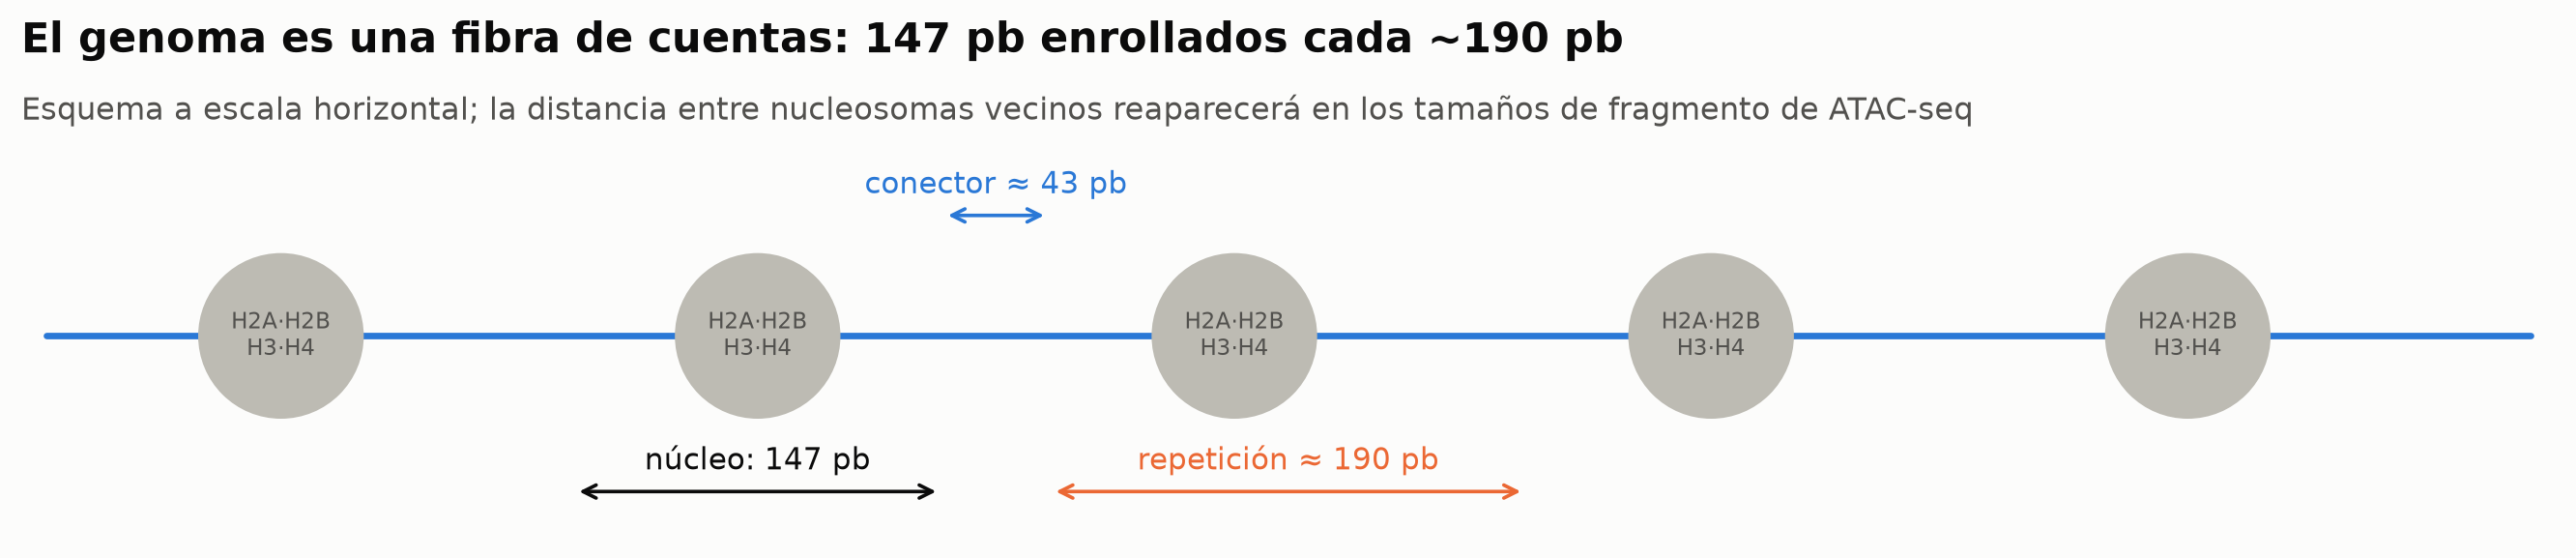

In [2]:
# Esquema a escala: una fibra de nucleosomas con núcleo de 147 pb y conectores de ~43 pb
core, linker = 147, 43
repeat = core + linker
fig, ax = plt.subplots(figsize=(12, 3.3))
x0 = 0
for j in range(5):
    ax.add_patch(Circle((x0 + core / 2, 0), 0.55 * 60, transform=ax.transData, color="#bdbbb3", zorder=2))
    ax.text(x0 + core / 2, 0, "H2A·H2B\nH3·H4", ha="center", va="center", fontsize=7.5, color=ec.INK_2, zorder=3)
    x0 += repeat
ax.plot([-20, x0 + 20], [0, 0], color=ec.BLUE, lw=2.2, zorder=0)
# cotas
def dim(xa, xb, y, text, color=ec.INK_2):
    ax.annotate("", (xa, y), (xb, y), arrowprops=dict(arrowstyle="<->", color=color, lw=1.2))
    ax.text((xa + xb) / 2, y + 6, text, ha="center", va="bottom", fontsize=10, color=color)
dim(repeat, repeat + core, -62, "núcleo: 147 pb", ec.INK)
dim(repeat + core, 2 * repeat, 48, "conector ≈ 43 pb", ec.BLUE)
dim(2 * repeat, 3 * repeat, -62, "repetición ≈ 190 pb", ec.ORANGE)
ax.set_xlim(-30, x0 + 30); ax.set_ylim(-80, 80); ax.set_aspect("equal"); ax.axis("off")
ec.title(ax, "El genoma es una fibra de cuentas: 147 pb enrollados cada ~190 pb",
         "Esquema a escala horizontal; la distancia entre nucleosomas vecinos reaparecerá en los tamaños de fragmento de ATAC-seq")
plt.show()

> 🔎 **Qué observamos.** El ADN (línea azul) alterna tramos **protegidos** por un octámero de histonas y tramos
> **expuestos** (conectores). Cualquier enzima que corte el ADN en la cromatina nativa sólo podrá hacerlo en los
> conectores o en regiones sin nucleosomas; por eso las distancias entre cortes serán múltiplos aproximados de la
> repetición.

### Marcas de histonas y atlas epigenómicos

Las colas de las histonas llevan modificaciones postraduccionales (acetilación, metilación mono-, di- o tri-,
fosforilación, ubiquitinación) que se nombran de forma compacta: `H3K27ac` es la **acetilación de la lisina 27 de la
histona H3**; `H3K4me3`, la **trimetilación de la lisina 4**. Jenuwein y Allis (2001) propusieron que la combinación
de marcas forma un **código de histonas** que, leído por proteínas con dominios específicos, decide transiciones
entre cromatina activa y silenciada.

| Marca | Dónde aparece | Asociación | Señal en ChIP-seq |
|---|---|---|---|
| H3K4me3 | promotores, alrededor del TSS | activa | estrecha |
| H3K4me1 | potenciadores (*enhancers*) activos o preparados | activa/latente | intermedia |
| H3K27ac | potenciadores y promotores activos | activa | intermedia |
| H3K36me3 | cuerpos de genes transcritos | elongación | ancha |
| H3K27me3 | genes reprimidos por Polycomb | represiva | ancha |
| H3K9me3 | heterocromatina constitutiva, repeticiones | represiva | ancha |

Las marcas **anchas** cubren decenas de kilobases y requieren estrategias de llamada distintas de las de un factor
de transcripción, cuya señal es **estrecha** (unos cientos de pares de bases).

Tres grandes consorcios han cartografiado estas marcas junto con la unión de factores y la accesibilidad:

* **ENCODE** (*Encyclopedia of DNA Elements*) publicó en 2012 un mapa integrado en líneas celulares humanas y afirmó
  poder asignar alguna "función bioquímica" al 80 % del genoma. La cifra desató un intenso debate, porque actividad
  bioquímica no equivale a función biológica: **toda señal epigenómica es una medida, no una interpretación**. Su
  tercera fase amplió la enciclopedia a humano y ratón y la organizó en un registro de elementos candidatos
  *cis*-reguladores (ENCODE Project Consortium, 2020).
* **Roadmap Epigenomics** generó 111 epigenomas de referencia de tejidos y células primarias e integró cinco marcas
  (H3K4me3, H3K4me1, H3K36me3, H3K27me3, H3K9me3) en un modelo de **estados de cromatina** (Kundaje et al., 2015).

Todos los datos reales de esta lección vienen del portal de ENCODE.

> ✅ **Compruebe su comprensión.** Si un investigador quiere mapear potenciadores **activos** en linfocitos B, ¿qué
> marca le pediría al laboratorio, H3K4me1 o H3K27ac? ¿Y qué forma de señal esperaría?
> <details><summary>Respuesta</summary>H3K27ac: H3K4me1 marca también potenciadores "preparados" (latentes), mientras
> que H3K27ac distingue los activos. La señal es intermedia (de cientos de pb a pocas kb), más ancha que la de un
> factor de transcripción y mucho más estrecha que la de H3K27me3.</details>

## 2. El experimento de ChIP-seq

La **inmunoprecipitación de cromatina seguida de secuenciación** (ChIP-seq) mide **dónde está una proteína** en el
genoma de una población de células. Johnson et al. (2007) la usaron para mapear el represor NRSF/REST en 1946 sitios
del genoma humano con una resolución de unas $\pm50$ pb. El protocolo tiene cinco pasos:

1. **Entrecruzamiento.** El formaldehído forma enlaces covalentes entre proteínas y ADN cercanos, "congelando" las
   interacciones del momento, como una fotografía con flash.
2. **Fragmentación.** La cromatina se rompe por sonicación (o con nucleasa) en fragmentos de unos **100 a 300 pb**.
3. **Inmunoprecipitación.** Un anticuerpo específico contra la proteína (o contra una marca de histona), acoplado a
   esferas magnéticas, captura los fragmentos que la llevan; el resto se lava.
4. **Reversión y secuenciación.** Se revierte el entrecruzamiento, se purifica el ADN y se secuencia, casi siempre
   **sólo un extremo** de cada fragmento (o pares cortos).
5. **Mapeo.** Las lecturas se alinean a la referencia (Módulo 7) y se buscan regiones con más lecturas de las
   esperadas: los **picos**.

Siempre se acompaña de un **control**, normalmente el ***input***: ADN fragmentado de la misma muestra **sin**
inmunoprecipitar. El *input* registra todo lo que no tiene que ver con la proteína: regiones más fáciles de sonicar,
amplificaciones del número de copias en la línea celular, zonas de mapeo problemático (Park, 2009).

### Nuestro caso real: CTCF en células B linfoblastoides

**CTCF** es la proteína con dedos de zinc que actúa como **aislante** del genoma: junto con la cohesina delimita los
dominios de asociación topológica (TAD) e impide que un potenciador active genes del dominio vecino. Tiene un motivo
largo y muy informativo, se une a decenas de miles de sitios y da picos altísimos: es el "estándar de oro" con el
que se calibran los métodos de ChIP-seq. Usaremos el experimento de ENCODE **ENCSR000AKB** (CTCF en la línea
linfoblastoide **GM12878**, laboratorio Bernstein, Broad Institute), con su control ***input*** **ENCSR000AKJ**, y el
ATAC-seq de la misma línea **ENCSR095QNB**. Las lecturas de ChIP-seq miden **36 pb**, exactamente la longitud $L$ de
la simulación del libro.

Para que el notebook sea ligero y rápido, el curso guarda una **copia compacta**: los extremos 5' de las lecturas
(con su hebra) del tratamiento y del control en **chr1:0–30 000 000** (GRCh38; la banda 1p36, muy rica en genes), los
fragmentos de ATAC-seq de la misma región, la lista de picos IDR de ENCODE, la lista negra y los TSS de RefSeq. Al
final de la lección hay una celda (sólo para Colab) que muestra cómo se obtuvo cada archivo desde ENCODE.

In [3]:
# Metadatos de los experimentos (respuesta de la API de ENCODE, guardada en data/api_cache/)
meta = json.loads(course_bytes("api_cache/encode_131_experiments.json"))
rows = []
for acc, e in meta.items():
    rows.append(dict(experimento=acc, ensayo=e["assay_title"], diana=e["target"] or "—",
                     muestra=e["biosample"], laboratorio=e["lab"], publicado=e["date_released"]))
display(pd.DataFrame(rows))
used = {"ENCFF355CYX": "CTCF réplica 1 (BAM filtrado)", "ENCFF850RIE": "input réplica 1 (BAM filtrado)",
        "ENCFF559WJC": "picos IDR ordenados (réplicas 1 y 2)", "ENCFF415FEC": "ATAC-seq réplica 1 (BAM filtrado)"}
files = [dict(archivo=f["accession"], uso=used[f["accession"]], formato=f["file_format"],
              lectura_pb=f["mapped_read_length"], MB=round(f["file_size"] / 1e6, 1))
         for e in meta.values() for f in e["files"] if f["accession"] in used]
display(pd.DataFrame(files))

,experimento,ensayo,diana,muestra,laboratorio,publicado
0,ENCSR000AKB,TF ChIP-seq,CTCF,Homo sapiens GM12878,"Bradley Bernstein, Broad",2011-02-10
1,ENCSR000AKJ,Control ChIP-seq,—,Homo sapiens GM12878,"Bradley Bernstein, Broad",2011-02-10
2,ENCSR095QNB,ATAC-seq,—,Homo sapiens GM12878,"Michael Snyder, Stanford",2020-08-05


,archivo,uso,formato,lectura_pb,MB
0,ENCFF355CYX,CTCF réplica 1 (BAM filtrado),bam,36.0,327.1
1,ENCFF559WJC,picos IDR ordenados (réplicas 1 y 2),bed,NaN,3.6
2,ENCFF850RIE,input réplica 1 (BAM filtrado),bam,36.0,257.0
3,ENCFF415FEC,ATAC-seq réplica 1 (BAM filtrado),bam,101.0,2515.6


In [4]:
def undelta(a):
    """Las posiciones se guardan como diferencias (comprimen mejor); aquí se reconstruyen."""
    return np.cumsum(a.astype(np.int64))

chip = np.load(io.BytesIO(course_bytes("131_ctcf_chip_input_chr1_0-30Mb.npz")))
T_plus, T_minus = undelta(chip["chip_plus"]), undelta(chip["chip_minus"])     # tratamiento (CTCF)
C_plus, C_minus = undelta(chip["ctrl_plus"]), undelta(chip["ctrl_minus"])     # control (input)
G_REG = int(chip["region_end"])            # 30 000 000 posiciones analizadas
L_READ = int(chip["read_length"])          # 36 pb
N_T, N_C = T_plus.size + T_minus.size, C_plus.size + C_minus.size
print(str(chip["info"]))
print(f"Tratamiento: {N_T:,} lecturas en la región ({T_plus.size:,} +, {T_minus.size:,} −) "
      f"de {int(chip['chip_total']):,} en todo el genoma")
print(f"Control    : {N_C:,} lecturas en la región ({C_plus.size:,} +, {C_minus.size:,} −) "
      f"de {int(chip['ctrl_total']):,} en todo el genoma")
print(f"Densidad media: una lectura del tratamiento cada {G_REG / N_T:.0f} pb")

ENCODE ENCSR000AKB (CTCF, GM12878, Bernstein/Broad) rep1 ENCFF355CYX; control ENCSR000AKJ rep1 ENCFF850RIE; GRCh38 chr1:0-30,000,000; 5' ends (0-based), delta-encoded; MAPQ>=30
Tratamiento: 102,568 lecturas en la región (51,345 +, 51,223 −) de 7,508,508 en todo el genoma
Control    : 57,694 lecturas en la región (28,976 +, 28,718 −) de 5,910,792 en todo el genoma
Densidad media: una lectura del tratamiento cada 292 pb


> 🤔 **Antes de ejecutar, prediga…** Unas 100 000 lecturas repartidas en 30 Mb son, en promedio, una cada 290 pb.
> Si CTCF se une a unos 800 sitios de esta región y un buen experimento pone un 20–30 % de las lecturas en picos,
> ¿cuántas lecturas esperaría, en promedio, en cada pico? ¿Y en una ventana de 400 pb del fondo?
> <details><summary>Respuesta</summary>≈0,25 × 100 000 / 800 ≈ 30 lecturas por pico, frente a ≈1,4 en una ventana de
> fondo de 400 pb: un contraste de más de veinte veces. Esa es la razón por la que CTCF es tan fácil de detectar.</details>

## 3. La geometría de las lecturas: dos hebras y un desplazamiento

El detalle clave del paso 4 es que el secuenciador lee **sólo las primeras decenas de bases de cada fragmento, desde
su extremo 5'**. Un fragmento de ADN de doble hebra tiene dos extremos 5', uno en cada hebra: si se secuencia la
hebra superior ($+$), la lectura empieza en el **extremo izquierdo** del fragmento y avanza hacia la derecha; si se
secuencia la inferior ($-$), empieza en el **extremo derecho** y avanza hacia la izquierda.

**Un ejemplo a mano.** CTCF está unido en la posición $\mu=1000$. Un fragmento de longitud $\ell=200$ centrado en el
sitio va de 900 a 1099. Si se lee su hebra $+$, el extremo 5' de la lectura está en $\mu-\ell/2=900$; si se lee la
hebra $-$, en $\mu+\ell/2-1=1099$ (el libro escribe $\mu+\ell/2$ en el continuo; el $-1$ aparece porque en
coordenadas discretas un fragmento de 200 pb que empieza en 900 termina en 1099, y es la razón de que más adelante las
modas queden a 199 pb de distancia y no a 200). Con otro fragmento de 160 pb centrado en 1004 las posiciones serían 924 y 1083.
Con miles de fragmentos, los extremos $+$ forman una **montaña** a la izquierda del sitio y los $-$, otra a la
derecha; **ninguna de las dos está encima del sitio**.

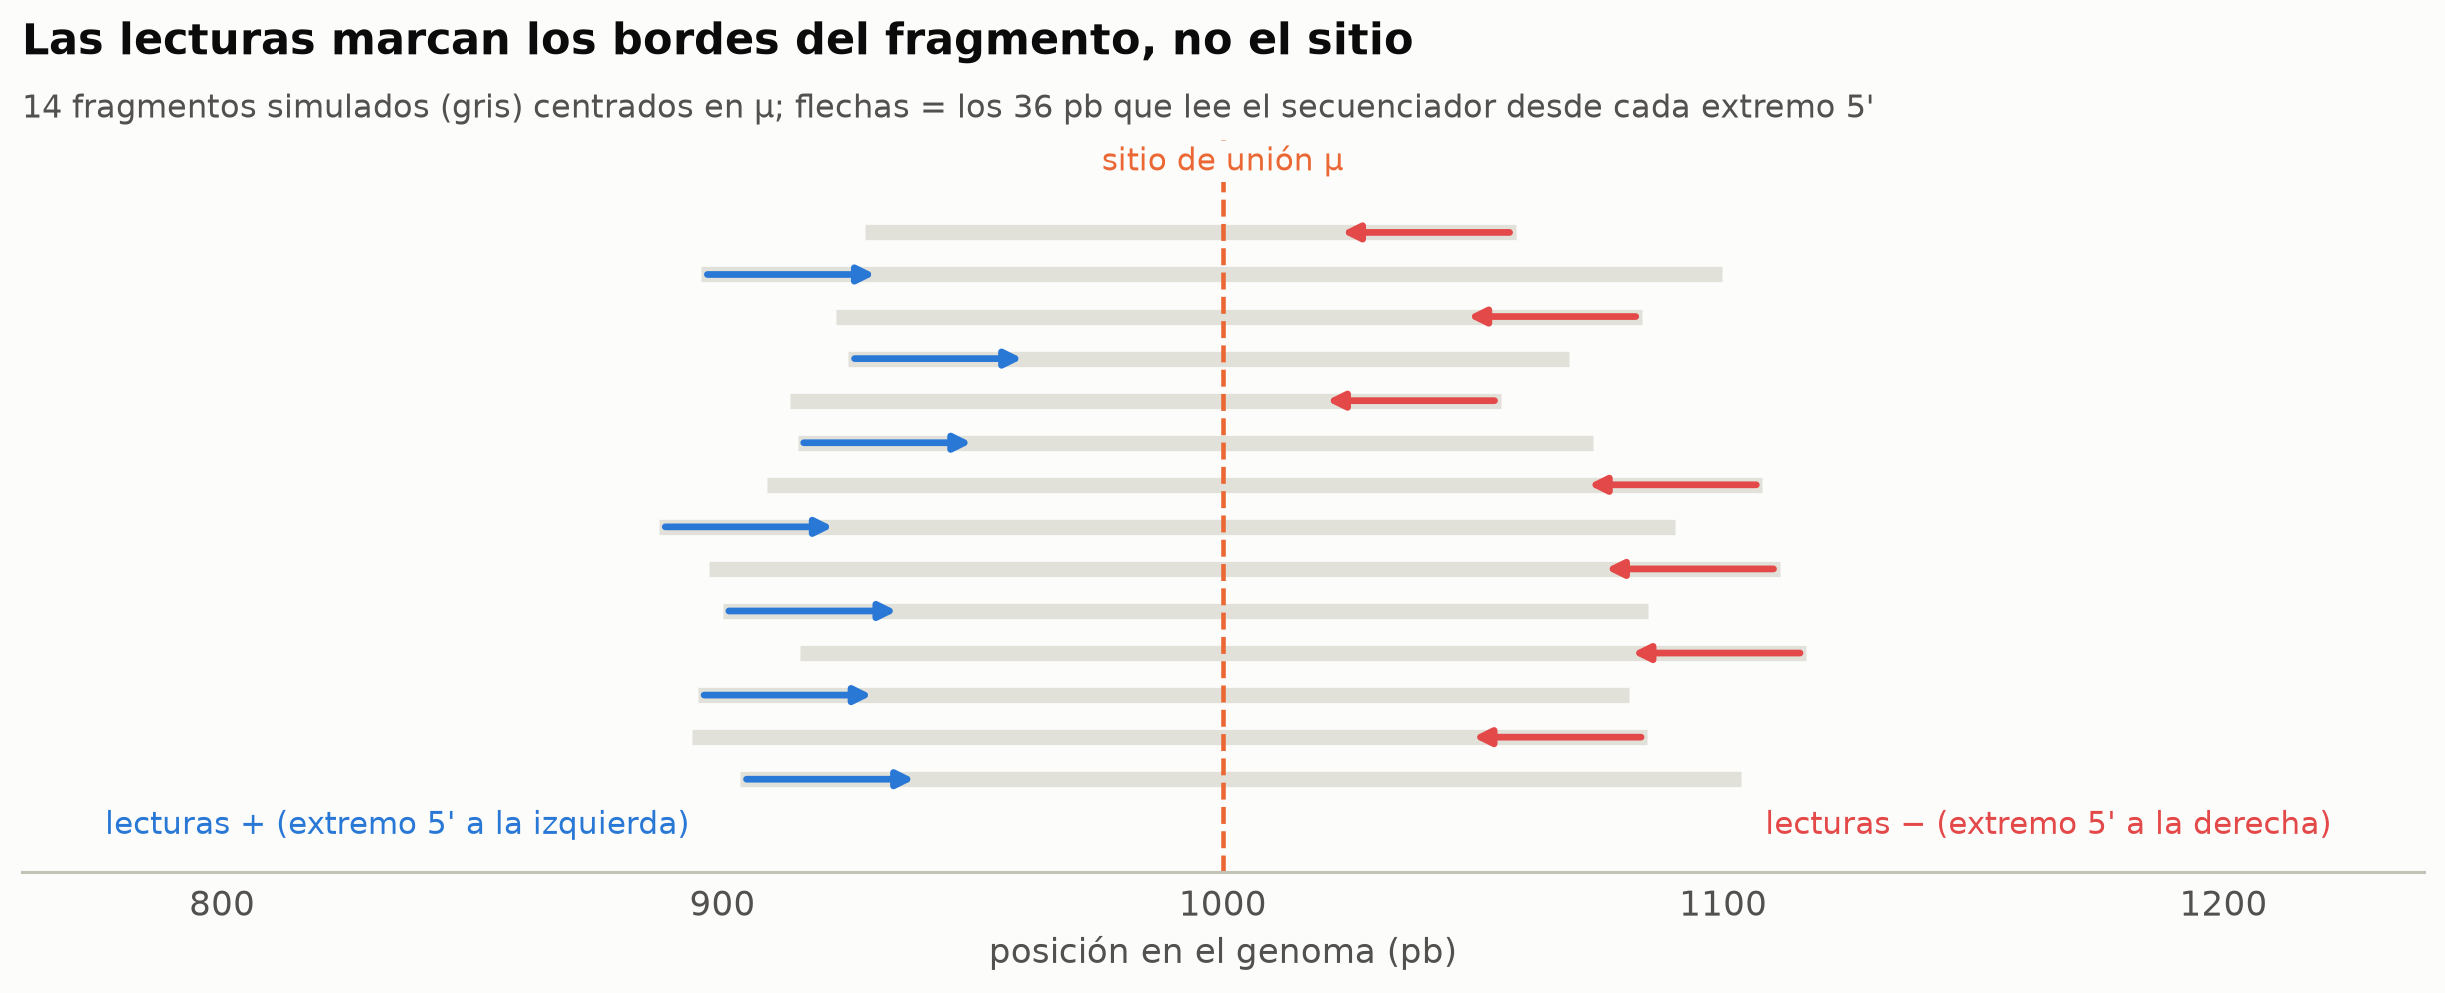

In [5]:
# Esquema: fragmentos alrededor de un sitio y la lectura que se secuencia de cada uno
rng_s = np.random.default_rng(7)
mu = 1000
fig, ax = plt.subplots(figsize=(11, 4.4))
for i in range(14):
    ell = int(np.clip(rng_s.normal(200, 30), 130, 270)); c = mu + rng_s.normal(0, 12)
    a, b = c - ell / 2, c + ell / 2
    y = i
    ax.plot([a, b], [y, y], color=ec.GRID, lw=5, solid_capstyle="butt", zorder=1)
    if i % 2 == 0:   # se secuencia la hebra +: lectura desde el extremo izquierdo
        ax.add_patch(FancyArrowPatch((a, y), (a + 36, y), arrowstyle="-|>", mutation_scale=11, color=ec.BLUE, lw=2.2))
    else:            # hebra −: lectura desde el extremo derecho hacia la izquierda
        ax.add_patch(FancyArrowPatch((b, y), (b - 36, y), arrowstyle="-|>", mutation_scale=11, color=ec.RED, lw=2.2))
ax.axvline(mu, color=ec.ORANGE, ls="--", lw=1.5)
ax.text(mu, 14.3, "sitio de unión μ", color=ec.ORANGE, ha="center", va="bottom", fontsize=10,
        bbox=dict(facecolor=ec.SURFACE, edgecolor="none", pad=1.5))
ax.text(835, -1.3, "lecturas + (extremo 5' a la izquierda)", color=ec.BLUE, ha="center", fontsize=10)
ax.text(1165, -1.3, "lecturas − (extremo 5' a la derecha)", color=ec.RED, ha="center", fontsize=10)
ax.set_xlim(760, 1240); ax.set_ylim(-2.2, 15.2); ax.set_yticks([])
ax.set_xlabel("posición en el genoma (pb)")
ax.spines["left"].set_visible(False)
ec.title(ax, "Las lecturas marcan los bordes del fragmento, no el sitio",
         "14 fragmentos simulados (gris) centrados en μ; flechas = los 36 pb que lee el secuenciador desde cada extremo 5'")
plt.show()

### El teorema de los perfiles por hebra

Formalicemos el esquema. Sea $c$ la posición del **centro** de un fragmento, con densidad $\varphi(c)$ centrada en el
sitio $\mu$ (su anchura refleja la imprecisión de la fragmentación), y sea $\ell$ su **longitud**, independiente de
$c$, con densidad $g(\ell)$ y media $\bar\ell$. Una lectura $+$ cae en $x$ si el fragmento empieza en $x$, es decir,
si su centro está en $c=x+\ell/2$; basta entonces integrar sobre las longitudes posibles (un cambio de variable):

$$
f_{+}(x) = \int g(\ell)\,\varphi\!\left(x+\tfrac{\ell}{2}\right)d\ell,\qquad
f_{-}(x) = \int g(\ell)\,\varphi\!\left(x-\tfrac{\ell}{2}\right)d\ell .
\tag{13.1}
$$

Si $\varphi$ es simétrica alrededor de $\mu$, $f_+$ y $f_-$ son **imágenes especulares** y sus centros de masa están en
$\mu\mp\bar\ell/2$; la distancia entre ambos es la longitud media del fragmento, $d=\bar\ell$.

| Símbolo | Significado |
|---|---|
| $\mu$ | posición del sitio de unión en el genoma |
| $\varphi(c)$ | densidad de la posición del centro del fragmento |
| $g(\ell),\ \bar\ell$ | densidad y media de la longitud de los fragmentos de la biblioteca |
| $f_\pm(x)$ | densidad esperada de extremos 5' de lecturas en la hebra $+$ o $-$ en la posición $x$ |
| $d$ | desplazamiento entre las dos montañas; se estima de los datos y se usa para "centrar" las lecturas |

**Consecuencia práctica.** Si desplazamos cada lectura $+$ una distancia $d/2$ hacia la derecha y cada lectura $-$
una distancia $d/2$ hacia la izquierda, las dos montañas se superponen **en el sitio verdadero** y la resolución
mejora. Alternativamente se puede **extender** cada lectura hasta la longitud $d$ en dirección 3', reconstruyendo el
fragmento; la suma de fragmentos reconstruidos es el ***pileup***. MACS estima $d$ tomando las regiones más
enriquecidas y midiendo la distancia entre las modas de ambas hebras (Zhang et al., 2008).

Reproducimos ahora la simulación del libro: **4000 fragmentos** con longitud $\ell\sim\mathcal N(200, 30^2)$
(recortada a 90–350) y centro $c\sim\mathcal N(0, 12^2)$, **semilla 101**.

In [6]:
# === Simulación del libro (figuras/cap13/generar.py, bloque 13.1-a, semilla 101) ===
rng = np.random.default_rng(101)
n_frag = 4000
flen = np.clip(rng.normal(200, 30, n_frag).round().astype(int), 90, 350)
centro = rng.normal(0, 12, n_frag)              # centro del fragmento ~ sitio (μ = 0)
izq = np.round(centro - flen / 2).astype(int)    # extremo 5' de la lectura +
der = izq + flen - 1                             # extremo 5' de la lectura −
xs = np.arange(-500, 501)
bw = 15

def dens(v):
    """Densidad suavizada (núcleo gaussiano de 15 pb) escalada por el número de lecturas."""
    k = stats.gaussian_kde(v, bw_method=bw / v.std())
    return k(xs) * len(v)

dp, dm = dens(izq), dens(der)
d_hat = int(np.median(flen))
comb = dens(np.concatenate([izq + d_hat // 2, der - d_hat // 2]))   # lecturas desplazadas d/2 hacia el centro
mp, mm = xs[np.argmax(dp)], xs[np.argmax(dm)]
print(f"moda +: {mp}   moda −: {mm}   distancia: {mm - mp}   mediana de la longitud: {d_hat}")
print("Libro: moda + = −100, moda − = 99, distancia 199, mediana 200")

moda +: -100   moda −: 99   distancia: 199   mediana de la longitud: 200
Libro: moda + = −100, moda − = 99, distancia 199, mediana 200


Ahora la misma pregunta con **datos reales**. Tomamos los **801 picos de CTCF** que ENCODE declara reproducibles
(IDR global $\le 0{,}05$) dentro de nuestra región, y para cada uno contamos cuántos extremos 5' de cada hebra caen a
cada distancia de su **cumbre** (*summit*, la posición de máxima señal). Si la teoría es correcta deberíamos ver la
misma pareja de montañas especulares.

In [7]:
peaks_all = pd.read_csv(io.BytesIO(course_bytes("131_encode_ctcf_idr_ranked_peaks.tsv.gz")), sep="\t",
                        compression="gzip")
IDR_OK = -np.log10(0.05)                     # ENCODE guarda el IDR como −log10 (tope 5)
enc = peaks_all[(peaks_all.chrom == "chr1") & (peaks_all.end <= G_REG) & (peaks_all.global_idr >= IDR_OK)].copy()
enc["summit_pos"] = enc.start + enc.summit
enc = enc.sort_values("start").reset_index(drop=True)
print(f"Picos ENCODE en todo el genoma: {len(peaks_all):,}; con IDR ≤ 0,05: {(peaks_all.global_idr >= IDR_OK).sum():,}")
print(f"En chr1:0-30 Mb con IDR ≤ 0,05: {len(enc)} picos (mediana de ancho {int((enc.end - enc.start).median())} pb)")

def aggregate(pos, centers, half=500):
    """Histograma de pos − centro para todos los centros (búsqueda binaria, sin bucles por lectura)."""
    out = np.zeros(2 * half + 1)
    lo = np.searchsorted(pos, centers - half); hi = np.searchsorted(pos, centers + half, side="right")
    for c, a, b in zip(centers, lo, hi):
        out += np.bincount(pos[a:b] - c + half, minlength=2 * half + 1)
    return out

xr = np.arange(-500, 501)
ker = stats.norm.pdf(np.arange(-45, 46), scale=15); ker /= ker.sum()     # mismo suavizado de 15 pb
agg_p = np.convolve(aggregate(T_plus, enc.summit_pos.values), ker, "same")
agg_m = np.convolve(aggregate(T_minus, enc.summit_pos.values), ker, "same")
mode_p, mode_m = xr[np.argmax(agg_p)], xr[np.argmax(agg_m)]
print(f"CTCF real: moda + en {mode_p} pb, moda − en {mode_m} pb → distancia entre modas {mode_m - mode_p} pb")

Picos ENCODE en todo el genoma: 82,105; con IDR ≤ 0,05: 41,978
En chr1:0-30 Mb con IDR ≤ 0,05: 801 picos (mediana de ancho 356 pb)
CTCF real: moda + en -78 pb, moda − en 69 pb → distancia entre modas 147 pb


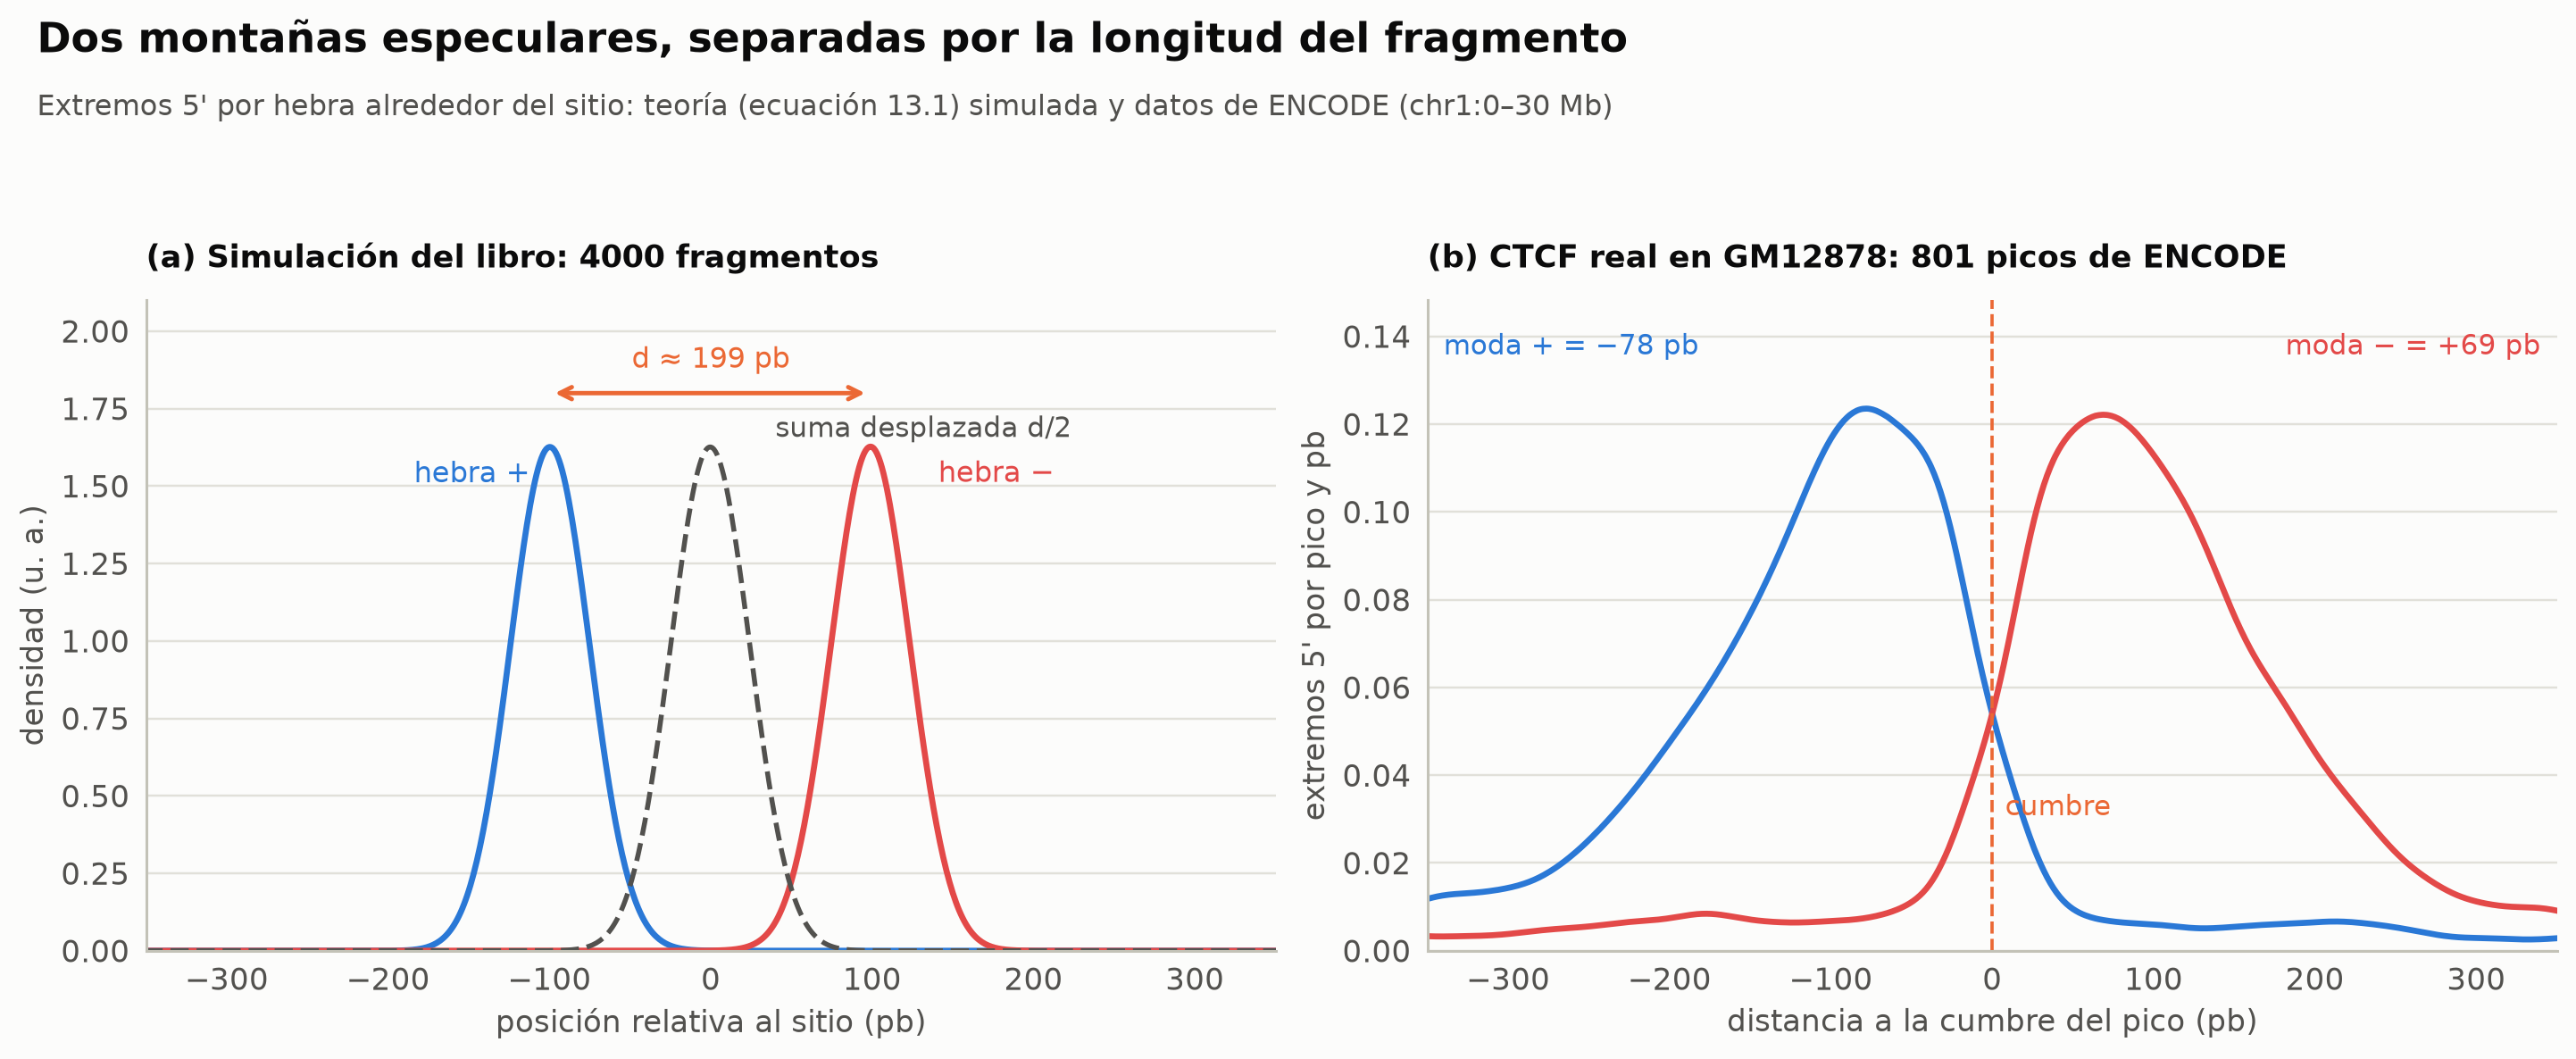

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
sc = 1 / n_frag * 100
ax = axes[0]
ax.plot(xs, dp * sc, color=ec.BLUE, lw=2.2); ax.plot(xs, dm * sc, color=ec.RED, lw=2.2)
ax.plot(xs, comb * sc / 2, color=ec.INK_2, lw=1.8, ls="--")
ax.annotate("", (mp, 1.8), (mm, 1.8), arrowprops=dict(arrowstyle="<->", color=ec.ORANGE, lw=1.6))
ax.text(0, 1.86, f"d ≈ {mm - mp} pb", ha="center", va="bottom", color=ec.ORANGE, fontsize=10.5)
ax.text(mp - 12, dp.max() * sc * 0.93, "hebra +", color=ec.BLUE, ha="right", fontsize=10.5)
ax.text(mm + 42, dm.max() * sc * 0.93, "hebra −", color=ec.RED, ha="left", fontsize=10.5)
ax.text(40, comb.max() * sc / 2 * 1.02, "suma desplazada d/2", color=ec.INK_2, ha="left", fontsize=10)
ax.set_xlim(-350, 350); ax.set_ylim(0, 2.1)
ax.set_xlabel("posición relativa al sitio (pb)"); ax.set_ylabel("densidad (u. a.)")
ax.set_title("(a) Simulación del libro: 4000 fragmentos", loc="left", fontsize=11.5)
ax = axes[1]
nrm = len(enc)
ax.plot(xr, agg_p / nrm, color=ec.BLUE, lw=2.2); ax.plot(xr, agg_m / nrm, color=ec.RED, lw=2.2)
ax.axvline(0, color=ec.ORANGE, ls="--", lw=1.2)
ax.text(-340, agg_p.max() / nrm * 1.1, f"moda + = −{abs(mode_p)} pb", color=ec.BLUE, ha="left", fontsize=10)
ax.text(340, agg_p.max() / nrm * 1.1, f"moda − = +{mode_m} pb", color=ec.RED, ha="right", fontsize=10)
ax.text(8, agg_p.max() / nrm * 0.25, "cumbre", color=ec.ORANGE, ha="left", fontsize=10)
ax.set_xlim(-350, 350); ax.set_ylim(0, agg_p.max() / nrm * 1.2)
ax.set_xlabel("distancia a la cumbre del pico (pb)"); ax.set_ylabel("extremos 5' por pico y pb")
ax.set_title(f"(b) CTCF real en GM12878: {len(enc)} picos de ENCODE", loc="left", fontsize=11.5)
ec.fig_title(fig, "Dos montañas especulares, separadas por la longitud del fragmento",
             "Extremos 5' por hebra alrededor del sitio: teoría (ecuación 13.1) simulada y datos de ENCODE (chr1:0–30 Mb)")
plt.show()

> 🔎 **Qué observamos.** En la simulación, las modas quedan en $-100$ y $+99$ (distancia 199 pb: la longitud media del
> fragmento, 200 pb, menos el $-1$ de las coordenadas discretas), exactamente como el libro, y la suma desplazada $d/2$ (línea discontinua) queda **centrada en el
> sitio** y es más estrecha que cada montaña. En los datos reales de CTCF aparece **la misma geometría**, con una
> separación algo menor (los fragmentos de esta biblioteca, sonicados, son más cortos que 200 pb). Además, las
> montañas reales tienen colas más largas: la longitud de los fragmentos reales no es gaussiana.

La siguiente animación desplaza progresivamente las dos montañas de la simulación hacia el centro: al llegar a $d/2$
se superponen y su suma alcanza la altura máxima.

![Desplazar cada lectura + una distancia s hacia la derecha y cada lectura − hacia la izquierda: cuando s llega a d/2 ≈ 100 pb las dos montañas de la simulación del libro se superponen sobre el sitio de unión](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-13-epigenomica/13.1_desplazamiento.gif)

*Desplazar cada lectura + una distancia s hacia la derecha y cada lectura − hacia la izquierda: cuando s llega a d/2 ≈ 100 pb las dos montañas de la simulación del libro se superponen sobre el sitio de unión*

In [9]:
shifts_anim = np.r_[np.arange(0, 101, 4), np.full(6, 100)]          # 26 pasos + pausa final
comb_h = []
for s in np.arange(0, 101, 4):
    comb_h.append(dens(np.concatenate([izq + s, der - s])).max() * sc / 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw=dict(width_ratios=[1.6, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.84))
ax = axes[0]
lp, = ax.plot([], [], color=ec.BLUE, lw=2.2, label="hebra + desplazada +s")
lm, = ax.plot([], [], color=ec.RED, lw=2.2, label="hebra − desplazada −s")
lc, = ax.plot([], [], color=ec.INK_2, lw=1.8, ls="--", label="suma / 2")
ax.axvline(0, color=ec.ORANGE, lw=1.2, ls=":")
ax.set_xlim(-350, 350); ax.set_ylim(0, 2.3); ax.legend(loc="upper left", fontsize=9)
ax.set_xlabel("posición relativa al sitio (pb)"); ax.set_ylabel("densidad (u. a.)")
ttl = ax.set_title("", loc="left", fontsize=11.5)
ax2 = axes[1]
ax2.set_xlim(0, 104); ax2.set_ylim(0, max(comb_h) * 1.15)
ax2.set_xlabel("desplazamiento aplicado s (pb)"); ax2.set_ylabel("altura de la suma")
ax2.axvline(d_hat / 2, color=ec.ORANGE, ls="--", lw=1.2); ax2.text(d_hat / 2 - 2, max(comb_h) * 0.08, "d/2", color=ec.ORANGE, ha="right")
lh, = ax2.plot([], [], color=ec.INK, lw=2, marker="o", ms=3)
fig.text(0.01, 0.99, "Desplazar d/2 junta las dos montañas en el sitio", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.93, "Simulación del libro (semilla 101): 4000 fragmentos de ~200 pb", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    s = shifts_anim[f]
    a = dens(izq + s) * sc; b = dens(der - s) * sc
    lp.set_data(xs, a); lm.set_data(xs, b); lc.set_data(xs, (a + b) / 2)
    k = min(f, len(comb_h) - 1)
    lh.set_data(np.arange(0, 101, 4)[:k + 1], comb_h[:k + 1])
    ttl.set_text(f"s = {s} pb")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(shifts_anim), interval=160, name="13.1_desplazamiento")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

## 4. Correlación cruzada entre hebras

MACS necesita elegir regiones enriquecidas **antes** de estimar $d$. Una estimación que no requiere elegir nada usa
**todo** el genoma (Kharchenko et al., 2008). Sean $n_+(x)$ y $n_-(x)$ los conteos de extremos 5' en cada posición.
Si los sitios de unión dominan la señal, $n_-$ se parece a $n_+$ **desplazado $d$ posiciones**, y la correlación
entre ambos perfiles será máxima en ese desplazamiento. Es como calcar el perfil de una hebra en papel transparente
y deslizarlo sobre el de la otra hasta que las montañas encajan.

Para cada desplazamiento $s\ge0$,

$$
r(s) = \operatorname{corr}\bigl(n_{+}(x),\ n_{-}(x+s)\bigr)
= \frac{\sum_x \bigl(n_+(x)-\bar n_+\bigr)\bigl(n_-(x+s)-\bar n_-\bigr)}{(G-s)\,\sigma_+\,\sigma_-},
\tag{13.2}
$$

donde la suma recorre las $G-s$ posiciones válidas. El **tamaño de fragmento estimado** es
$\hat d=\operatorname{argmax}_s r(s)$, excluyendo desplazamientos cercanos a la longitud de lectura.

| Símbolo | Significado |
|---|---|
| $n_\pm(x)$ | número de lecturas cuyo extremo 5' cae en $x$ en cada hebra |
| $\bar n_\pm,\ \sigma_\pm$ | media y desviación estándar de esos conteos a lo largo del genoma |
| $G$ | longitud del genoma (o del cromosoma, o de la región analizada) |
| $s$ | desplazamiento aplicado a la hebra $-$ |
| $L$ | longitud de las lecturas |

**Un ejemplo a mano** con un "genoma" de 12 posiciones: $n_+ = (0,2,0,0,0,0,0,1,0,0,0,0)$ y
$n_- = (0,0,0,0,2,0,0,0,0,0,1,0)$. Con $s=3$ la hebra $-$ desplazada, $n_-(x+3)$, pone sus conteos 2 y 1 en las
posiciones 1 y 7, **exactamente** donde están los de $n_+$: la correlación es máxima. Lo comprobamos con NumPy.

In [10]:
n_p = np.array([0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], float)
n_m = np.array([0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0], float)
for s in range(0, 6):
    a, b = n_p[:len(n_p) - s], n_m[s:]
    print(f"s = {s}:  n+ = {a.astype(int)}   n−(x+s) = {b.astype(int)}   r(s) = {np.corrcoef(a, b)[0, 1]:+.3f}")

s = 0:  n+ = [0 2 0 0 0 0 0 1 0 0 0 0]   n−(x+s) = [0 0 0 0 2 0 0 0 0 0 1 0]   r(s) = -0.176
s = 1:  n+ = [0 2 0 0 0 0 0 1 0 0 0]   n−(x+s) = [0 0 0 2 0 0 0 0 0 1 0]   r(s) = -0.196
s = 2:  n+ = [0 2 0 0 0 0 0 1 0 0]   n−(x+s) = [0 0 2 0 0 0 0 0 1 0]   r(s) = -0.220
s = 3:  n+ = [0 2 0 0 0 0 0 1 0]   n−(x+s) = [0 2 0 0 0 0 0 1 0]   r(s) = +1.000
s = 4:  n+ = [0 2 0 0 0 0 0 1]   n−(x+s) = [2 0 0 0 0 0 1 0]   r(s) = -0.290
s = 5:  n+ = [0 2 0 0 0 0 0]   n−(x+s) = [0 0 0 0 0 1 0]   r(s) = -0.167


### El pico fantasma, NSC y RSC

La curva $r(s)$ tiene casi siempre **dos** máximos. El primero, en $s=\hat d$, es la **señal biológica**. El segundo,
en $s\approx L$, es el **pico fantasma** (*phantom peak*), un artefacto de la **mapabilidad**: en regiones repetidas,
donde las lecturas no pueden mapearse de forma única, desaparecen **a la vez** las lecturas $+$ que empiezan en $x$ y
las lecturas $-$ cuyo extremo 5' está en $x+L-1$, lo que correlaciona ambas hebras a esa distancia aunque no haya
proteína alguna. Las guías de ENCODE y modENCODE (Landt et al., 2012) convirtieron la curva en dos índices:

$$
\mathrm{NSC} = \frac{r(\hat d)}{\min_s r(s)},\qquad
\mathrm{RSC} = \frac{r(\hat d)-\min_s r(s)}{r(L)-\min_s r(s)} .
\tag{13.3}
$$

| Símbolo | Significado |
|---|---|
| NSC | coeficiente de hebras normalizado: cuánto sobresale el pico de fragmento sobre el fondo de la curva |
| RSC | coeficiente de hebras relativo: tamaño del pico de fragmento comparado con el del pico fantasma |

Un **RSC mayor que 1** indica que la señal biológica domina sobre el artefacto de mapeo; valores de **NSC < 1,05** y
**RSC < 0,8** delatan un enriquecimiento pobre.

Reproducimos la simulación del libro: un cromosoma de **3 Mb** con bloques no mapeables, **900 sitios** de unión,
fragmentos de ~180 pb, lecturas de 36 pb y un fondo con sesgo regional; una muestra **buena** (60 000 lecturas de
sitios reales + 540 000 de fondo) y una **pobre** (14 000 + 586 000), **semilla 102**.

In [11]:
# === Simulación del libro (bloque 13.1-b, semilla 102) ===
rng = np.random.default_rng(102)
G = 3_000_000
mapeable = np.ones(G, bool)                       # mapabilidad: bloques únicos / repetidos
pos = 0
while pos < G:
    u = int(rng.exponential(260)); r_ = int(rng.exponential(60))
    mapeable[pos + u:pos + u + r_] = False
    pos += u + r_
sitios = rng.choice(np.arange(5000, G - 5000), 900, replace=False)
fr_len = np.clip(rng.normal(180, 25, 400_000).round().astype(int), 80, 320)
tasa = np.repeat(rng.lognormal(0, 0.6, G // 20000 + 1), 20000)[:G]    # sesgo regional del fondo
tasa /= tasa.sum()

def simula_lecturas(n_senal, n_ruido):
    c = np.concatenate([rng.choice(sitios, n_senal) + rng.normal(0, 15, n_senal).round(),
                        rng.choice(G, n_ruido, p=tasa)]).astype(int)
    fl = rng.choice(fr_len, c.size)
    a = c - fl // 2; b = a + fl - 1
    hebra = rng.random(c.size) < 0.5
    p5 = np.where(hebra, a, b)                    # extremo 5' leído
    start = np.where(hebra, a, b - L_READ + 1)    # inicio de la lectura en la referencia
    ok = (start > 0) & (start < G - L_READ)
    ok[ok] &= mapeable[start[ok]]                 # la lectura sólo se ve si su tramo es mapeable
    return p5[ok & hebra], p5[ok & ~hebra]

def xcor_dense(pl, mi, shifts, G):
    """Ecuación 13.2 tal cual: vectores de conteos por posición y np.corrcoef para cada s."""
    cp = np.bincount(pl, minlength=G + 400)[:G].astype(float)
    cm = np.bincount(mi, minlength=G + 400)[:G].astype(float)
    return np.array([np.corrcoef(cp[:G - s], cm[s:])[0, 1] for s in shifts])

def strand_quality(shifts, cc, L=36, min_frag=100):
    imax = np.argmax(np.where(shifts > min_frag, cc, -1))
    iread = np.argmin(abs(shifts - L)); cmin = cc.min()
    return shifts[imax], cc[imax] / cmin, (cc[imax] - cmin) / (cc[iread] - cmin)

t0 = time.time()
shifts = np.arange(0, 401, 4)
book_xc, book_reads = {}, {}
for nombre, ns, nr in [("buena", 60_000, 540_000), ("pobre", 14_000, 586_000)]:
    pl, mi = simula_lecturas(ns, nr)
    book_reads[nombre] = (np.sort(pl), np.sort(mi))
    book_xc[nombre] = xcor_dense(pl, mi, shifts, G)
    dh, nsc, rsc = strand_quality(shifts, book_xc[nombre])
    print(f"{nombre}: d̂ = {dh} pb   NSC = {nsc:.2f}   RSC = {rsc:.2f}")
print("Libro: buena d̂ = 176, NSC = 2,70, RSC = 1,76;  pobre d̂ = 104, NSC = 1,30, RSC = 0,36")
print(f"({time.time() - t0:.1f} s)")

buena: d̂ = 176 pb   NSC = 2.70   RSC = 1.76


pobre: d̂ = 104 pb   NSC = 1.30   RSC = 0.36
Libro: buena d̂ = 176, NSC = 2,70, RSC = 1,76;  pobre d̂ = 104, NSC = 1,30, RSC = 0,36
(5.2 s)


### Un atajo para genomas grandes: contar parejas en lugar de construir vectores

La fórmula directa construye vectores de longitud $G$ (30 millones en nuestra región real; 3000 millones en un
genoma humano) y los multiplica para cada $s$. Pero casi todos los $n_\pm(x)$ valen 0. El numerador de (13.2)
se reescribe como

$$
\sum_x n_+(x)\,n_-(x+s) - (G-s)\,\bar n_+\bar n_- ,
$$

y el primer término es simplemente **el número de parejas** (lectura $+$ en $x$, lectura $-$ en $x+s$). Con las
posiciones ordenadas, la búsqueda binaria encuentra, para cada lectura $+$, las lecturas $-$ que están a menos de
400 pb; un histograma de esas diferencias da el término para **todos** los $s$ a la vez. Usando las medias y
varianzas globales (una aproximación despreciable cuando $s\ll G$) obtenemos la misma curva en una fracción del tiempo.

In [12]:
def xcor_sparse(pl, mi, G, smax=400):
    """r(s) para s = 0..smax contando parejas (+ en x, − en x+s). pl, mi: posiciones ordenadas."""
    mean_p, mean_m = pl.size / G, mi.size / G
    var_p = (np.unique(pl, return_counts=True)[1] ** 2).sum() / G - mean_p ** 2
    var_m = (np.unique(mi, return_counts=True)[1] ** 2).sum() / G - mean_m ** 2
    lo = np.searchsorted(mi, pl); hi = np.searchsorted(mi, pl + smax, side="right")
    n_pairs = hi - lo
    idx = np.repeat(lo - np.r_[0, np.cumsum(n_pairs)[:-1]], n_pairs) + np.arange(n_pairs.sum())
    diffs = mi[idx] - np.repeat(pl, n_pairs)
    s = np.arange(smax + 1)
    prod = np.bincount(diffs, minlength=smax + 1)[:smax + 1] / (G - s)
    return s, (prod - mean_p * mean_m) / np.sqrt(var_p * var_m)

t0 = time.time()
s_sp, r_sp = xcor_sparse(*book_reads["buena"], G)
print(f"Atajo por parejas: {time.time() - t0:.2f} s; diferencia máxima con la fórmula directa: "
      f"{np.abs(r_sp[shifts] - book_xc['buena']).max():.1e}")

Atajo por parejas: 0.19 s; diferencia máxima con la fórmula directa: 1.3e-05

> 🤔 **Antes de ejecutar, prediga…** Nuestros datos reales tienen lecturas de $L=36$ pb, como la simulación. Para CTCF,
> un factor con picos muy fuertes, ¿qué índice espera más alto que el de la muestra "buena" del libro, NSC o RSC? ¿Y
> qué forma tendrá la curva del ***input***, donde no hay proteína inmunoprecipitada?
> <details><summary>Respuesta</summary>Ambos: CTCF concentra una fracción de lecturas en picos mayor que la
> simulación buena, así que el pico de fragmento sobresale mucho más del mínimo (NSC alto) y domina al fantasma
> (RSC ≫ 1). El input no tiene pico de fragmento: su curva es casi plana, con sólo una pequeña joroba (el
> fantasma) cerca de s ≈ 36.</details>

In [13]:
t0 = time.time()
s_real, r_ctcf = xcor_sparse(T_plus, T_minus, G_REG)
_, r_input = xcor_sparse(C_plus, C_minus, G_REG)
d_real, nsc_real, rsc_real = strand_quality(s_real, r_ctcf, L=L_READ, min_frag=2 * L_READ)
print(f"CTCF (GM12878, ENCODE): d̂ = {d_real} pb   NSC = {nsc_real:.2f}   RSC = {rsc_real:.2f}   "
      f"r(d̂) = {r_ctcf[d_real]:.4f}, r(L) = {r_ctcf[L_READ]:.4f}, mín r = {r_ctcf.min():.4f}")
print(f"input: r máx fuera del fantasma = {r_input[2 * L_READ:].max():.5f}; r(L) = {r_input[L_READ]:.5f}; "
      f"mín r = {r_input.min():.5f}  (el mínimo es ≈ 0 o negativo: NSC no tiene sentido aquí)")
print(f"({time.time() - t0:.1f} s para 30 Mb)")

CTCF (GM12878, ENCODE): d̂ = 164 pb   NSC = 6.57   RSC = 5.28   r(d̂) = 0.0478, r(L) = 0.0149, mín r = 0.0073
input: r máx fuera del fantasma = 0.00081; r(L) = 0.00067; mín r = -0.00037  (el mínimo es ≈ 0 o negativo: NSC no tiene sentido aquí)
(0.0 s para 30 Mb)


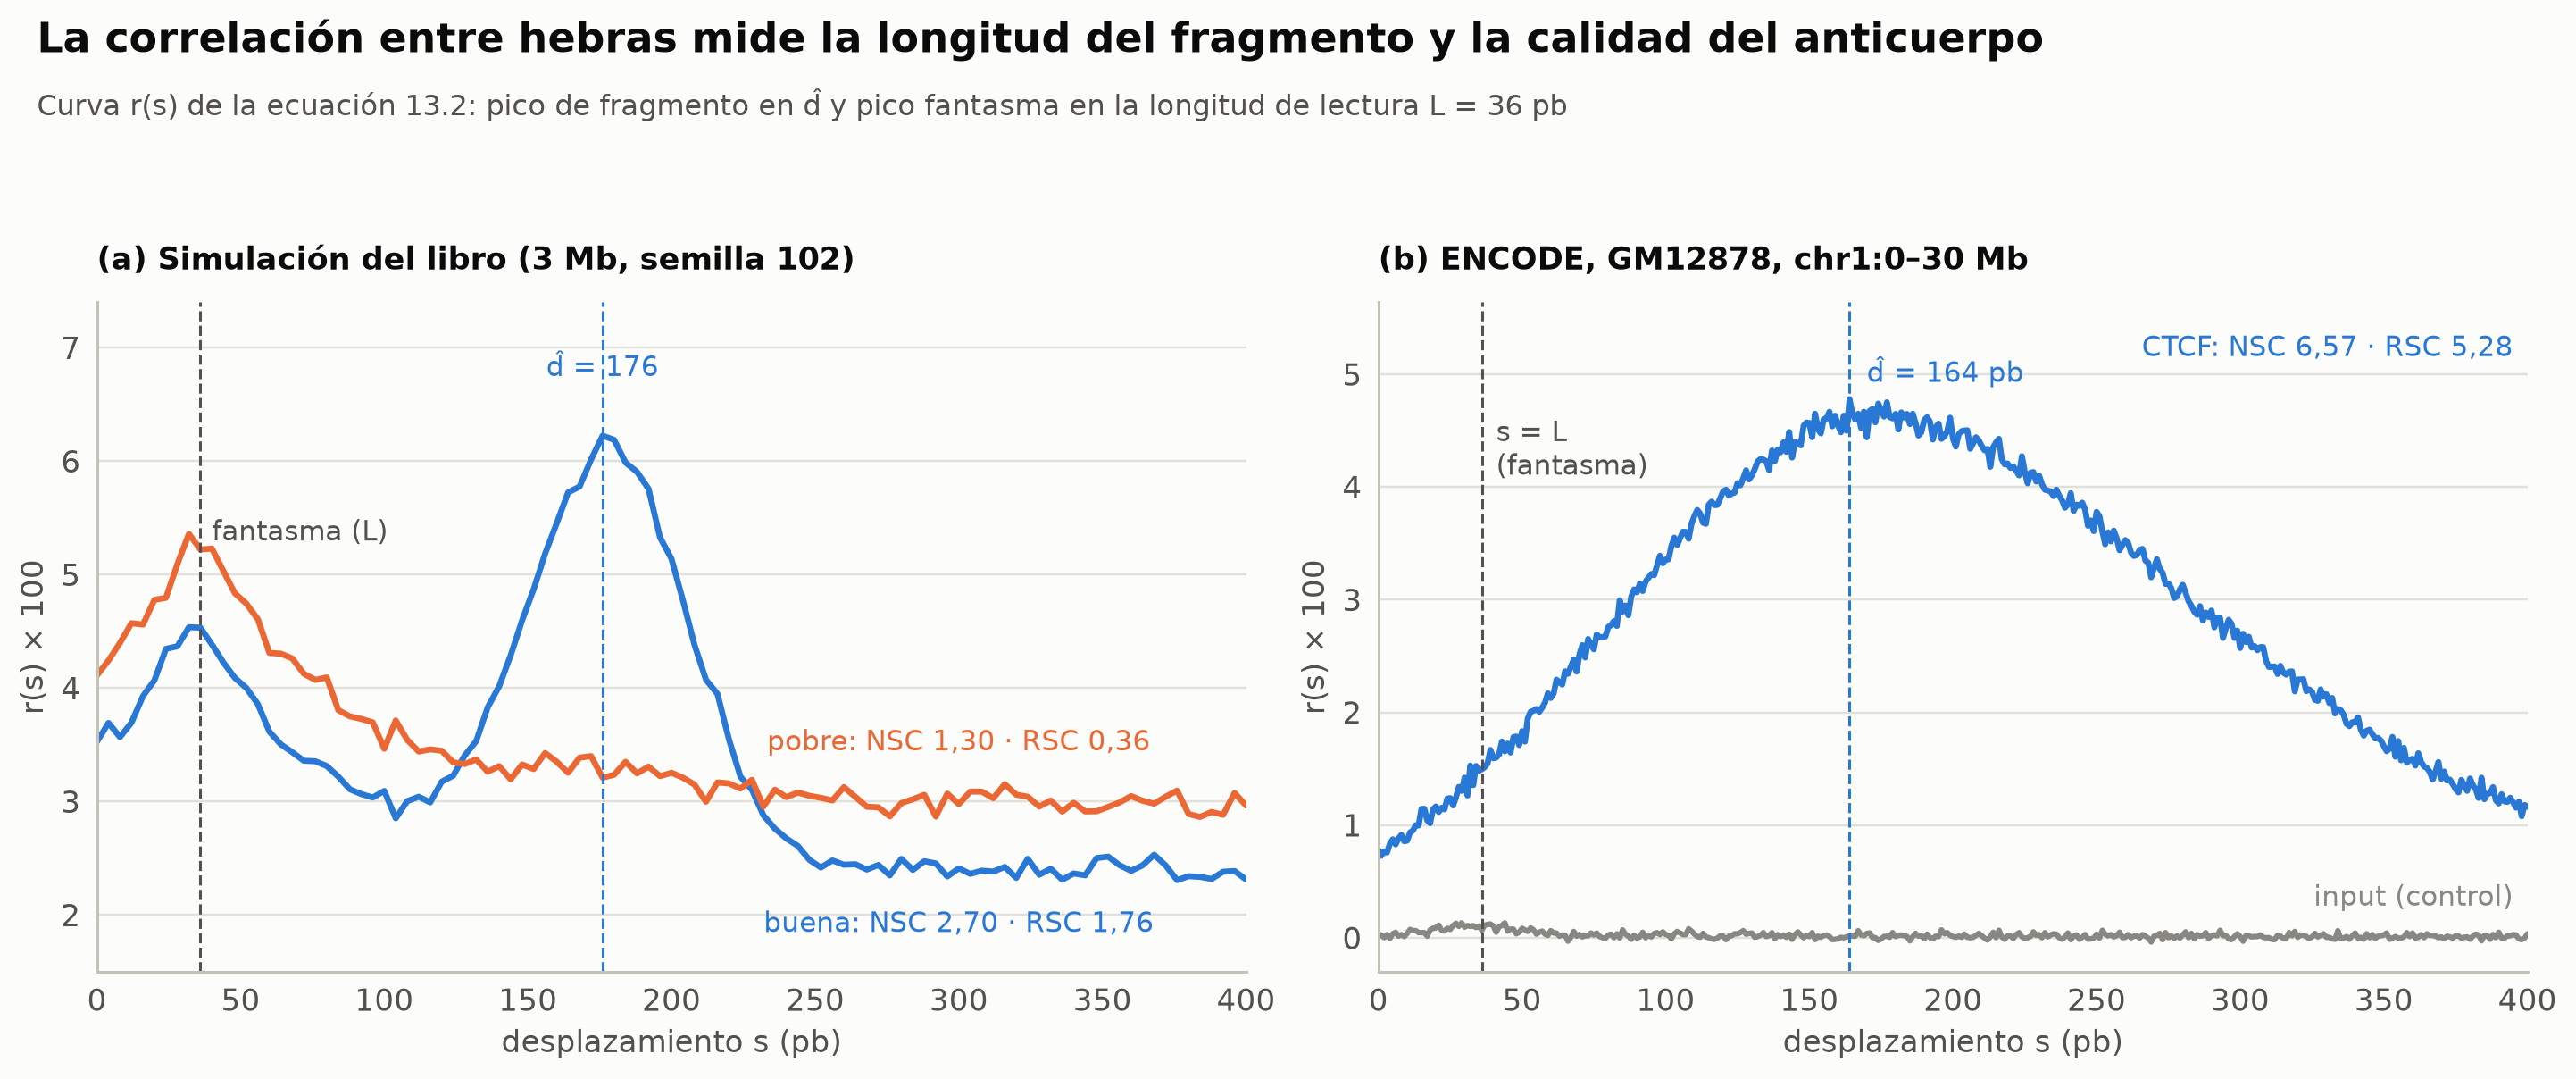

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
ax = axes[0]
ax.plot(shifts, book_xc["buena"] * 100, color=ec.BLUE, lw=2.2)
ax.plot(shifts, book_xc["pobre"] * 100, color=ec.ORANGE, lw=2.2)
ax.axvline(36, color=ec.INK_2, ls="--", lw=1); ax.text(40, 5.3, "fantasma (L)", fontsize=10, color=ec.INK_2)
ax.axvline(176, color=ec.BLUE, ls="--", lw=1); ax.text(176, 6.75, "d̂ = 176", ha="center", color=ec.BLUE, fontsize=10)
ax.text(300, 1.85, "buena: NSC 2,70 · RSC 1,76", color=ec.BLUE, ha="center", fontsize=10)
ax.text(300, 3.45, "pobre: NSC 1,30 · RSC 0,36", color=ec.ORANGE, ha="center", fontsize=10)
ax.set_xlim(0, 400); ax.set_ylim(1.5, 7.4)
ax.set_xlabel("desplazamiento s (pb)"); ax.set_ylabel("r(s) × 100")
ax.set_title("(a) Simulación del libro (3 Mb, semilla 102)", loc="left", fontsize=11.5)
ax = axes[1]
ax.plot(s_real, r_ctcf * 100, color=ec.BLUE, lw=2.2)
ax.plot(s_real, r_input * 100, color=ec.MUTED, lw=2)
ax.axvline(L_READ, color=ec.INK_2, ls="--", lw=1)
ax.axvline(d_real, color=ec.BLUE, ls="--", lw=1)
ax.text(d_real + 6, r_ctcf[d_real] * 100 * 1.02, f"d̂ = {d_real} pb", color=ec.BLUE, fontsize=10, va="bottom")
ax.text(L_READ + 5, r_ctcf.max() * 100 * 0.86, "s = L\n(fantasma)", color=ec.INK_2, fontsize=10)
ax.text(395, r_ctcf.max() * 100 * 1.08, f"CTCF: NSC {nsc_real:.2f} · RSC {rsc_real:.2f}".replace(".", ","),
        color=ec.BLUE, ha="right", fontsize=10)
ax.text(395, r_input[-1] * 100 + 0.25, "input (control)", color=ec.MUTED, ha="right", fontsize=10)
ax.set_xlim(0, 400); ax.set_ylim(-0.3, r_ctcf.max() * 100 * 1.18)
ax.set_xlabel("desplazamiento s (pb)"); ax.set_ylabel("r(s) × 100")
ax.set_title("(b) ENCODE, GM12878, chr1:0–30 Mb", loc="left", fontsize=11.5)
ec.fig_title(fig, "La correlación entre hebras mide la longitud del fragmento y la calidad del anticuerpo",
             "Curva r(s) de la ecuación 13.2: pico de fragmento en d̂ y pico fantasma en la longitud de lectura L = 36 pb")
plt.show()

> 🔎 **Qué observamos.** En la simulación del libro la muestra buena alcanza su máximo en $\hat d=176$ pb con
> $\mathrm{NSC}=2{,}70$ y $\mathrm{RSC}=1{,}76$; en la pobre, con unas cuatro veces menos lecturas procedentes de
> sitios reales (14 000 frente a 60 000), el pico de fragmento casi desaparece: el máximo fuera de la zona del fantasma cae en 104 pb, un valor sin
> significado biológico, y $\mathrm{RSC}=0{,}36$. El experimento real de CTCF es de una calidad excelente: su pico de
> fragmento domina toda la curva (NSC ≈ 6,6 y RSC ≈ 5,3, muy por encima de 1). En estos datos el fantasma **no** se ve
> como un pico separado: queda enterrado en la subida del pico de fragmento, que es muy ancho porque las longitudes
> reales de los fragmentos varían mucho (y porque el BAM filtrado de ENCODE ya excluye las lecturas de mapeo ambiguo);
> RSC se calcula igual, con $r(L)$ leído en $s=36$. El *input* no muestra pico de fragmento alguno; sólo una pequeña
> joroba cerca de $s\approx L$ (véala en la figura interactiva), que es su fantasma. Observe también que el $\hat d$ real es más corto que 200 pb: la sonicación de esta biblioteca produjo
> fragmentos más cortos, $\hat d=164$ pb, del mismo orden que los 147 pb que separan las modas reales de las dos
> hebras en la sección 3 (la moda de cada montaña es más sensible al ruido que la correlación, que usa todas las lecturas).

La animación siguiente hace visible el "deslizar el calco": en una ventana real alrededor de un sitio fuerte de
CTCF, las lecturas $-$ se desplazan $s$ posiciones hacia la izquierda mientras la curva $r(s)$ se dibuja debajo.

![Correlación cruzada con datos reales de CTCF: al desplazar la hebra − (rojo) s pb hacia la izquierda, sus montañas se alinean con las de la hebra + (azul) justo cuando s alcanza el tamaño de fragmento d̂, el máximo de r(s)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-13-epigenomica/13.1_correlacion.gif)

*Correlación cruzada con datos reales de CTCF: al desplazar la hebra − (rojo) s pb hacia la izquierda, sus montañas se alinean con las de la hebra + (azul) justo cuando s alcanza el tamaño de fragmento d̂, el máximo de r(s)*

In [15]:
# Ventana real: los 3 picos de ENCODE más fuertes y cercanos entre sí dentro de 4 kb
top_enc = enc.sort_values("signal", ascending=False).head(60)
best = None
for c0 in top_enc.summit_pos:
    n_in = ((enc.summit_pos > c0 - 2000) & (enc.summit_pos < c0 + 2000)).sum()
    if best is None or n_in > best[1]:
        best = (c0, n_in)
w0, w1 = best[0] - 1500, best[0] + 1500
BINW = 10
edges = np.arange(w0, w1 + BINW, BINW)
hp = np.histogram(T_plus, edges)[0]
frames_s = np.r_[np.arange(0, 301, 10), np.full(5, d_real)]
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), gridspec_kw=dict(height_ratios=[1.3, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.88))
ax = axes[0]
ctr = edges[:-1] + BINW / 2 - best[0]
ax.bar(ctr, hp, width=BINW, color=ec.BLUE, alpha=0.85, label="hebra + (fija)")
bars_m = ax.bar(ctr, -np.histogram(T_minus, edges)[0], width=BINW, color=ec.RED, alpha=0.85, label="hebra − desplazada −s")
ymax = max(hp.max(), np.histogram(T_minus, edges)[0].max()) * 1.15
ax.set_ylim(-ymax, ymax); ax.axhline(0, color=ec.BASELINE, lw=0.8)
ax.set_xlim(-1500, 1500); ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.set_xlabel(f"posición relativa a chr1:{best[0]:,} (pb)"); ax.set_ylabel("lecturas por 10 pb")
ttl = ax.set_title("", loc="left", fontsize=11.5)
ax = axes[1]
ax.plot(s_real, r_ctcf * 100, color=ec.GRID, lw=2)
lr, = ax.plot([], [], color=ec.BLUE, lw=2.2); pt, = ax.plot([], [], "o", color=ec.ORANGE, ms=8)
ax.axvline(d_real, color=ec.BLUE, ls="--", lw=1)
ax.set_xlim(0, 310); ax.set_ylim(r_ctcf.min() * 100 - 0.2, r_ctcf.max() * 100 * 1.15)
ax.set_xlabel("desplazamiento s (pb)"); ax.set_ylabel("r(s) × 100 (30 Mb)")
fig.text(0.01, 0.995, "Deslizar una hebra sobre la otra: el máximo está en d̂", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.95, "CTCF en GM12878 (ENCODE); arriba, una ventana de 3 kb; abajo, r(s) de toda la región", fontsize=10.5,
         color=ec.INK_2, va="top")

def update(f):
    s = int(frames_s[f])
    hm = np.histogram(T_minus - s, edges)[0]
    for b, h in zip(bars_m, hm):
        b.set_height(-h)
    k = min(s, 400)
    lr.set_data(s_real[:k + 1], r_ctcf[:k + 1] * 100); pt.set_data([s], [r_ctcf[k] * 100])
    ttl.set_text(f"s = {s} pb   ·   r(s) = {r_ctcf[k]:.4f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(frames_s), interval=180, name="13.1_correlacion")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

La figura interactiva reúne las cuatro curvas en la misma escala. Pase el ratón por encima: el cuadro indica, para
cada $s$, qué parte de la curva está mirando y qué significa.

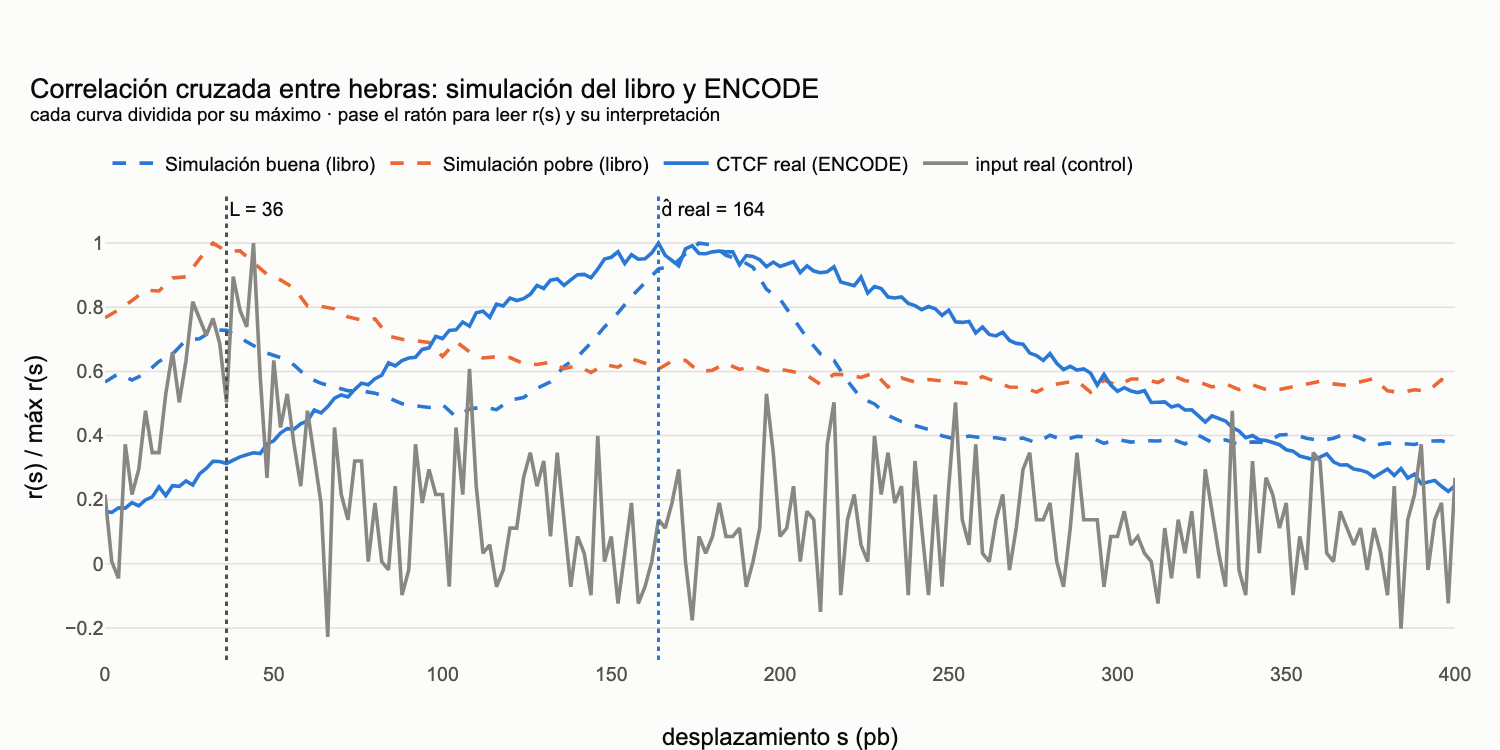

In [16]:
def region_label(s, dh):
    if abs(s - L_READ) <= 6:
        return "zona del pico fantasma (s ≈ L): artefacto de mapabilidad"
    if abs(s - dh) <= 10:
        return "pico de fragmento: aquí encajan las montañas de ambas hebras"
    if s < L_READ:
        return "desplazamiento menor que la lectura"
    return "fondo de la curva"

fig = go.Figure()
curves = [("Simulación buena (libro)", shifts, book_xc["buena"], ec.BLUE, 176, "dash"),
          ("Simulación pobre (libro)", shifts, book_xc["pobre"], ec.ORANGE, 104, "dash"),
          ("CTCF real (ENCODE)", s_real[::2], r_ctcf[::2], ec.BLUE, d_real, "solid"),
          ("input real (control)", s_real[::2], r_input[::2], ec.MUTED, None, "solid")]
for name, sx, cc, col, dh, dash in curves:
    rel = cc / cc.max() if cc.max() > 0 else cc
    txt = [region_label(v, dh if dh else -999) for v in sx]
    fig.add_trace(go.Scatter(x=sx, y=rel, name=name, mode="lines", line=dict(color=col, width=2.4, dash=dash),
        customdata=np.column_stack([cc, txt]),
        hovertemplate="<b>" + name + "</b><br>s = %{x} pb<br>r(s) = %{customdata[0]:.4f}"
                      "<br>r(s)/máx = %{y:.2f}<br>%{customdata[1]}<extra></extra>"))
fig.add_vline(x=L_READ, line=dict(color=ec.INK_2, dash="dot"), annotation_text="L = 36", annotation_position="top right")
fig.add_vline(x=d_real, line=dict(color=ec.BLUE, dash="dot"), annotation_text=f"d̂ real = {d_real}",
              annotation_position="top right")
fig.update_layout(
    title="Correlación cruzada entre hebras: simulación del libro y ENCODE"
          "<br><sup>cada curva dividida por su máximo · pase el ratón para leer r(s) y su interpretación</sup>",
    xaxis_title="desplazamiento s (pb)", yaxis_title="r(s) / máx r(s)", height=500, yaxis_range=[-0.3, 1.15],
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=70, r=30, b=60))
fig.show()

> ✅ **Compruebe su comprensión.** Un colega le envía un experimento con $\mathrm{NSC}=1{,}02$ y $\mathrm{RSC}=0{,}4$ y
> le dice que "igualmente tiene 20 000 picos". ¿Qué le responde?
> <details><summary>Respuesta</summary>Que ambos índices están por debajo de los umbrales de ENCODE (1,05 y 0,8): la
> curva está dominada por el fantasma, es decir, casi todas las lecturas son fondo. Los 20 000 "picos" probablemente
> reflejan sesgos del genoma (sonicación, número de copias) y no la unión de la proteína; hay que repetir la
> inmunoprecipitación o probar otro anticuerpo antes de interpretar nada.</details>

## 5. Llamar picos: el fondo de Poisson local

Una vez desplazadas las lecturas, la pregunta es **estadística**: ¿en qué ventanas del genoma hay **más** lecturas de
las que produciría el fondo? El modelo más simple supone que, en ausencia de unión, las $N$ lecturas se reparten
uniformemente sobre las $G$ posiciones mapeables, como gotas de lluvia sobre un patio: cada gota cae en una baldosa
concreta con una probabilidad minúscula, pero hay muchísimas gotas.

**Teorema (conteo en una ventana bajo el fondo uniforme).** Si cada una de las $N$ lecturas cae en una ventana de
ancho $w$ con probabilidad $p=w/G$, de forma independiente, el número $X$ de lecturas en la ventana sigue una
binomial $\mathrm{Bin}(N,p)$. Cuando $N\to\infty$ y $p\to0$ con $Np=\lambda$ fijo,

$$
\Pr(X=k) \;\longrightarrow\; \frac{e^{-\lambda}\lambda^{k}}{k!},\qquad \lambda=\frac{N\,w}{G},
\tag{13.4}
$$

y el **valor $p$** de observar al menos $k$ lecturas es la cola superior

$$
p(k) = \Pr(X\ge k) = 1-\sum_{i=0}^{k-1}\frac{e^{-\lambda}\lambda^{i}}{i!}.
\tag{13.5}
$$

| Símbolo | Significado |
|---|---|
| $N$ | número total de lecturas (o fragmentos) mapeadas en la muestra tratada |
| $G$ | tamaño efectivo del genoma: posiciones donde una lectura puede mapearse de forma única (≈ $2{,}7\times10^9$ en humano) |
| $w$ | ancho de la ventana; en MACS, $w=2d$ |
| $\lambda$ | número esperado de lecturas en la ventana bajo el fondo |
| $k$ | número de lecturas observadas en la ventana candidata |

**Demostración.** Es el límite clásico de Poisson:

$$
\binom{N}{k}p^k(1-p)^{N-k} = \frac{N(N-1)\cdots(N-k+1)}{N^k}\,\frac{\lambda^k}{k!}\,\Bigl(1-\frac{\lambda}{N}\Bigr)^{N-k},
$$

el primer factor tiende a 1 y el último a $e^{-\lambda}$. Es la misma aproximación que, en el Módulo 6, nos dio la
teoría de Lander-Waterman para la cobertura. Comprobémoslo numéricamente con $\lambda=3{,}2$: ¿con qué $N$ la binomial
ya es indistinguible de la Poisson?

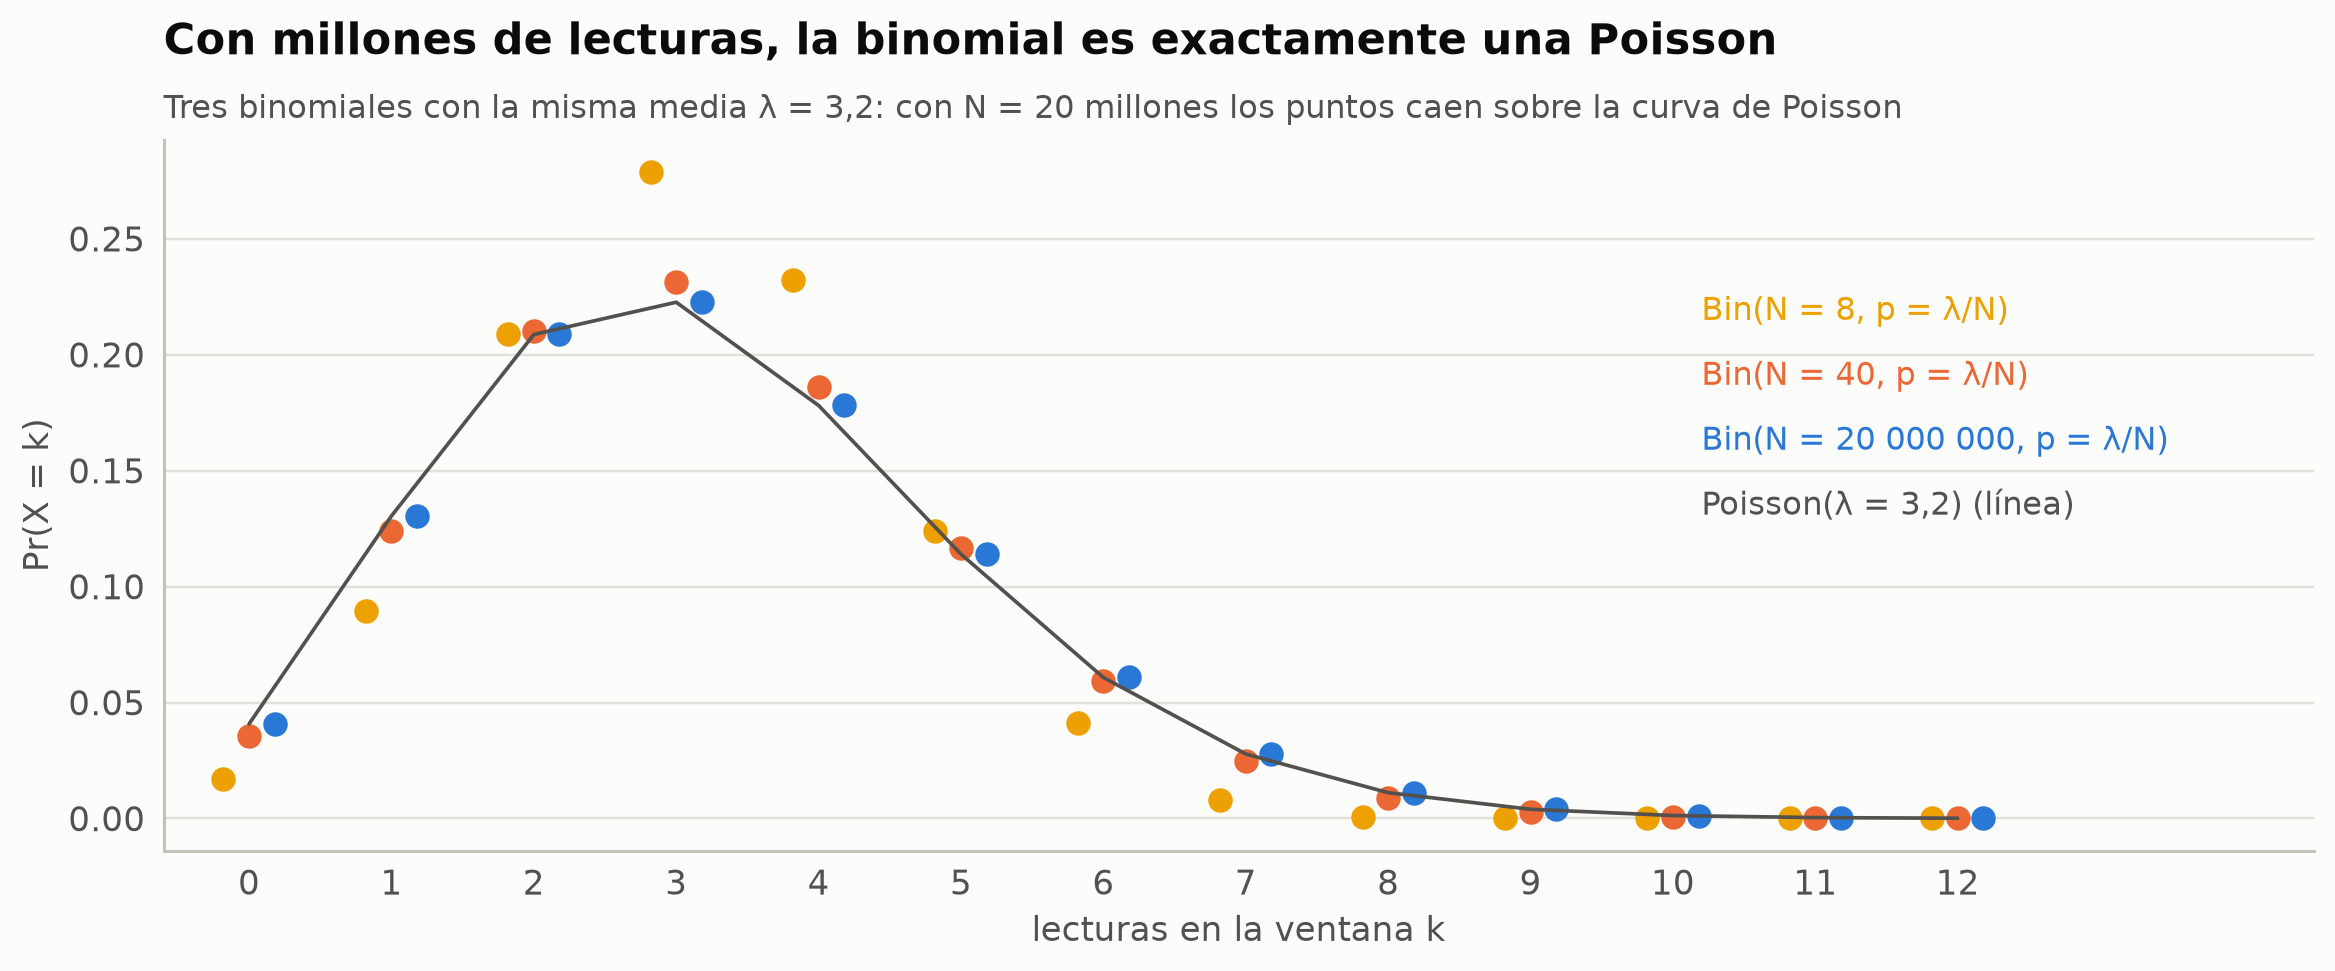

N =          8: distancia de variación total con la Poisson = 1.2e-01
N =         40: distancia de variación total con la Poisson = 2.0e-02
N = 20,000,000: distancia de variación total con la Poisson = 3.9e-08


In [17]:
lam = 3.2
ks = np.arange(0, 13)
fig, ax = plt.subplots(figsize=(10.5, 4.3))
for j, (Nn, col) in enumerate([(8, ec.YELLOW), (40, ec.ORANGE), (20_000_000, ec.BLUE)]):
    pm = stats.binom.pmf(ks, Nn, lam / Nn)
    ax.plot(ks + (j - 1) * 0.18, pm, "o", color=col, ms=7)
    ax.text(10.2, 0.215 - 0.028 * j, "Bin(N = " + f"{Nn:,}".replace(",", " ") + ", p = λ/N)", color=col, fontsize=10.5)
ax.plot(ks, stats.poisson.pmf(ks, lam), "-", color=ec.INK_2, lw=1.2)
ax.text(10.2, 0.215 - 0.028 * 3, "Poisson(λ = 3,2) (línea)", color=ec.INK_2, fontsize=10.5)
ax.set_xlabel("lecturas en la ventana k"); ax.set_ylabel("Pr(X = k)"); ax.set_xticks(ks)
ax.set_xlim(-0.6, 14.5)
ec.title(ax, "Con millones de lecturas, la binomial es exactamente una Poisson",
         "Tres binomiales con la misma media λ = 3,2: con N = 20 millones los puntos caen sobre la curva de Poisson")
plt.show()
for Nn in [8, 40, 20_000_000]:
    print(f"N = {Nn:>10,}: distancia de variación total con la Poisson = "
          f"{0.5 * np.abs(stats.binom.pmf(np.arange(60), Nn, lam / Nn) - stats.poisson.pmf(np.arange(60), lam)).sum():.1e}")

### El fondo uniforme es falso: el lambda local de MACS

La sonicación rompe mejor la cromatina abierta; las regiones con más copias en la línea celular producen más
lecturas; algunas zonas acumulan señal en cualquier experimento. Aplicar un $\lambda$ **global** en esas regiones llena
la lista de picos de falsos positivos. La solución de **MACS** (*Model-based Analysis of ChIP-Seq*; Zhang et al., 2008)
es un **Poisson dinámico**: para cada ventana candidata se toma como fondo **el máximo** de varias estimaciones, de
modo que el modelo es conservador allí donde el control indica un sesgo.

**Definición (lambda local de MACS).** Para una ventana candidata de ancho $2d$,

$$
\lambda_{\text{local}} = \max\bigl(\lambda_{\text{BG}},\ \lambda_{1k},\ \lambda_{5k},\ \lambda_{10k}\bigr),
\qquad
\lambda_{w'} = c_{w'}\cdot\frac{2d}{w'}\cdot\frac{N_T}{N_C},
\tag{13.6}
$$

donde $\lambda_{\text{BG}}=N_T\,2d/G$ es el fondo global y $c_{w'}$ es el número de lecturas del **control** en una
ventana de ancho $w'\in\{1, 5, 10\}$ kb centrada en el candidato.

| Símbolo | Significado |
|---|---|
| $\lambda_{\text{BG}}$ | fondo global: las lecturas tratadas repartidas uniformemente |
| $c_{w'}$ | lecturas del control en la ventana ancha $w'$; se reescalan al ancho $2d$ y a la profundidad del tratamiento |
| $N_T,\ N_C$ | número de lecturas del tratamiento y del control |

Tomar el **máximo** tiene una lógica de protección: si **cualquiera** de las escalas indica que la región es ruidosa,
el umbral sube. MACS2 y MACS3 conservan la idea (por omisión con ventanas de $d$, 1 kb y 10 kb en el control) y
añaden la corrección de Benjamini-Hochberg para obtener valores $q$, un modo de picos anchos y el uso directo de
fragmentos pareados. El artículo original estimaba además la **tasa de falsos descubrimientos empírica
intercambiando tratamiento y control**: los "picos" que aparecen en el control frente al tratamiento indican cuántos
falsos positivos produce el procedimiento con el mismo umbral.

### Ejemplo resuelto del libro: «Un pico, dos fondos»

Un experimento tiene $N_T=2\times10^7$ lecturas tratadas y $N_C=2{,}5\times10^7$ de control; $G=2{,}7\times10^9$ y
$d=200$, así que la ventana mide 400 pb. El fondo global es

$$
\lambda_{\text{BG}} = \frac{2\times10^7\times400}{2{,}7\times10^9} = 2{,}963 .
$$

En el control hay 10 lecturas en la ventana de 1 kb, 45 en la de 5 kb y 95 en la de 10 kb. Con el factor de
profundidad $N_T/N_C=0{,}8$: $\lambda_{1k}=10\cdot0{,}4\cdot0{,}8=3{,}200$, $\lambda_{5k}=45\cdot0{,}08\cdot0{,}8=2{,}880$ y
$\lambda_{10k}=95\cdot0{,}04\cdot0{,}8=3{,}040$. Entonces $\lambda_{\text{local}}=3{,}200$. Con $k=17$ lecturas en la ventana,
$p = \Pr(X\ge17\mid\lambda=3{,}2) = 5{,}38\times10^{-8}$, $-\log_{10}p = 7{,}27$: un pico claro. Con el umbral original
de MACS ($p<10^{-5}$) bastan 14 lecturas.

Ahora **otra región**, idéntica en el tratamiento, pero en una **amplificación** de la línea celular: el control tiene
400 lecturas en 10 kb, así que $\lambda_{10k}=12{,}8$. Con $k=14$ lecturas, el fondo global daría $p=2{,}96\times10^{-6}$
(un "pico"), mientras que el fondo local da $p=0{,}405$: nada notable. **El control ha evitado un falso positivo que
ninguna profundidad de secuenciación habría corregido.** Verifiquemos cada cifra.

In [18]:
N_T_ex, N_C_ex, G_ex, D_ex = 20e6, 25e6, 2.7e9, 200
W2 = 2 * D_ex
lam_bg = N_T_ex * W2 / G_ex
ratio = N_T_ex / N_C_ex

def lam_w(c, wprime):
    """Ecuación 13.6: lecturas del control en la ventana w', reescaladas a 2d y a la profundidad del tratamiento."""
    return c * W2 / wprime * ratio

tab = pd.DataFrame({"fondo": ["λ_BG (global)", "λ_1k", "λ_5k", "λ_10k"],
                    "lecturas del control c_w'": ["—", 10, 45, 95],
                    "λ": [lam_bg, lam_w(10, 1000), lam_w(45, 5000), lam_w(95, 10000)]})
lam_loc = tab["λ"].max()
display(tab.style.format({"λ": "{:.3f}"}).hide(axis="index"))
k_obs = 17
p_loc = stats.poisson.sf(k_obs - 1, lam_loc)          # sf(k−1) = Pr(X ≥ k)
print(f"λ_local = {lam_loc:.3f};  k = {k_obs}:  p = {p_loc:.3e}  (−log10 p = {-np.log10(p_loc):.2f})")
k_min = next(k for k in range(1, 40) if stats.poisson.sf(k - 1, lam_loc) < 1e-5)
print(f"Umbral p < 1e-5 con λ_local = 3,2:  k ≥ {k_min}")
l10_amp = lam_w(400, 10000)
print(f"Región amplificada: λ_10k = {l10_amp:.2f};  k = 14:  p(λ_BG) = {stats.poisson.sf(13, lam_bg):.2e}   "
      f"p(λ_local) = {stats.poisson.sf(13, max(lam_bg, l10_amp)):.3f}")

fondo,lecturas del control c_w',λ
λ_BG (global),—,2.963
λ_1k,10,3.200
λ_5k,45,2.880
λ_10k,95,3.040


λ_local = 3.200;  k = 17:  p = 5.379e-08  (−log10 p = 7.27)
Umbral p < 1e-5 con λ_local = 3,2:  k ≥ 14
Región amplificada: λ_10k = 12.80;  k = 14:  p(λ_BG) = 2.96e-06   p(λ_local) = 0.405


> 🔎 **Qué observamos.** Todas las cifras coinciden con el libro: $\lambda_{\text{BG}}=2{,}963$, $\lambda_{\text{local}}=3{,}200$
> (lo fija la ventana de 1 kb), $p=5{,}38\times10^{-8}$, umbral $k\ge14$, y en la región amplificada el valor $p$ pasa de
> $2{,}96\times10^{-6}$ a $0{,}405$. Fíjese en que el fondo global y el local difieren "sólo" un 8 % en el primer caso,
> pero en la cola de la Poisson esa diferencia multiplica el valor $p$ casi por tres.

Reproducimos ahora la figura del libro (semilla 103): diez kilobases simuladas con un pico fuerte cerca de 5,2 kb y un
enriquecimiento débil cerca de 2,3 kb, y la distribución de Poisson con su cola.

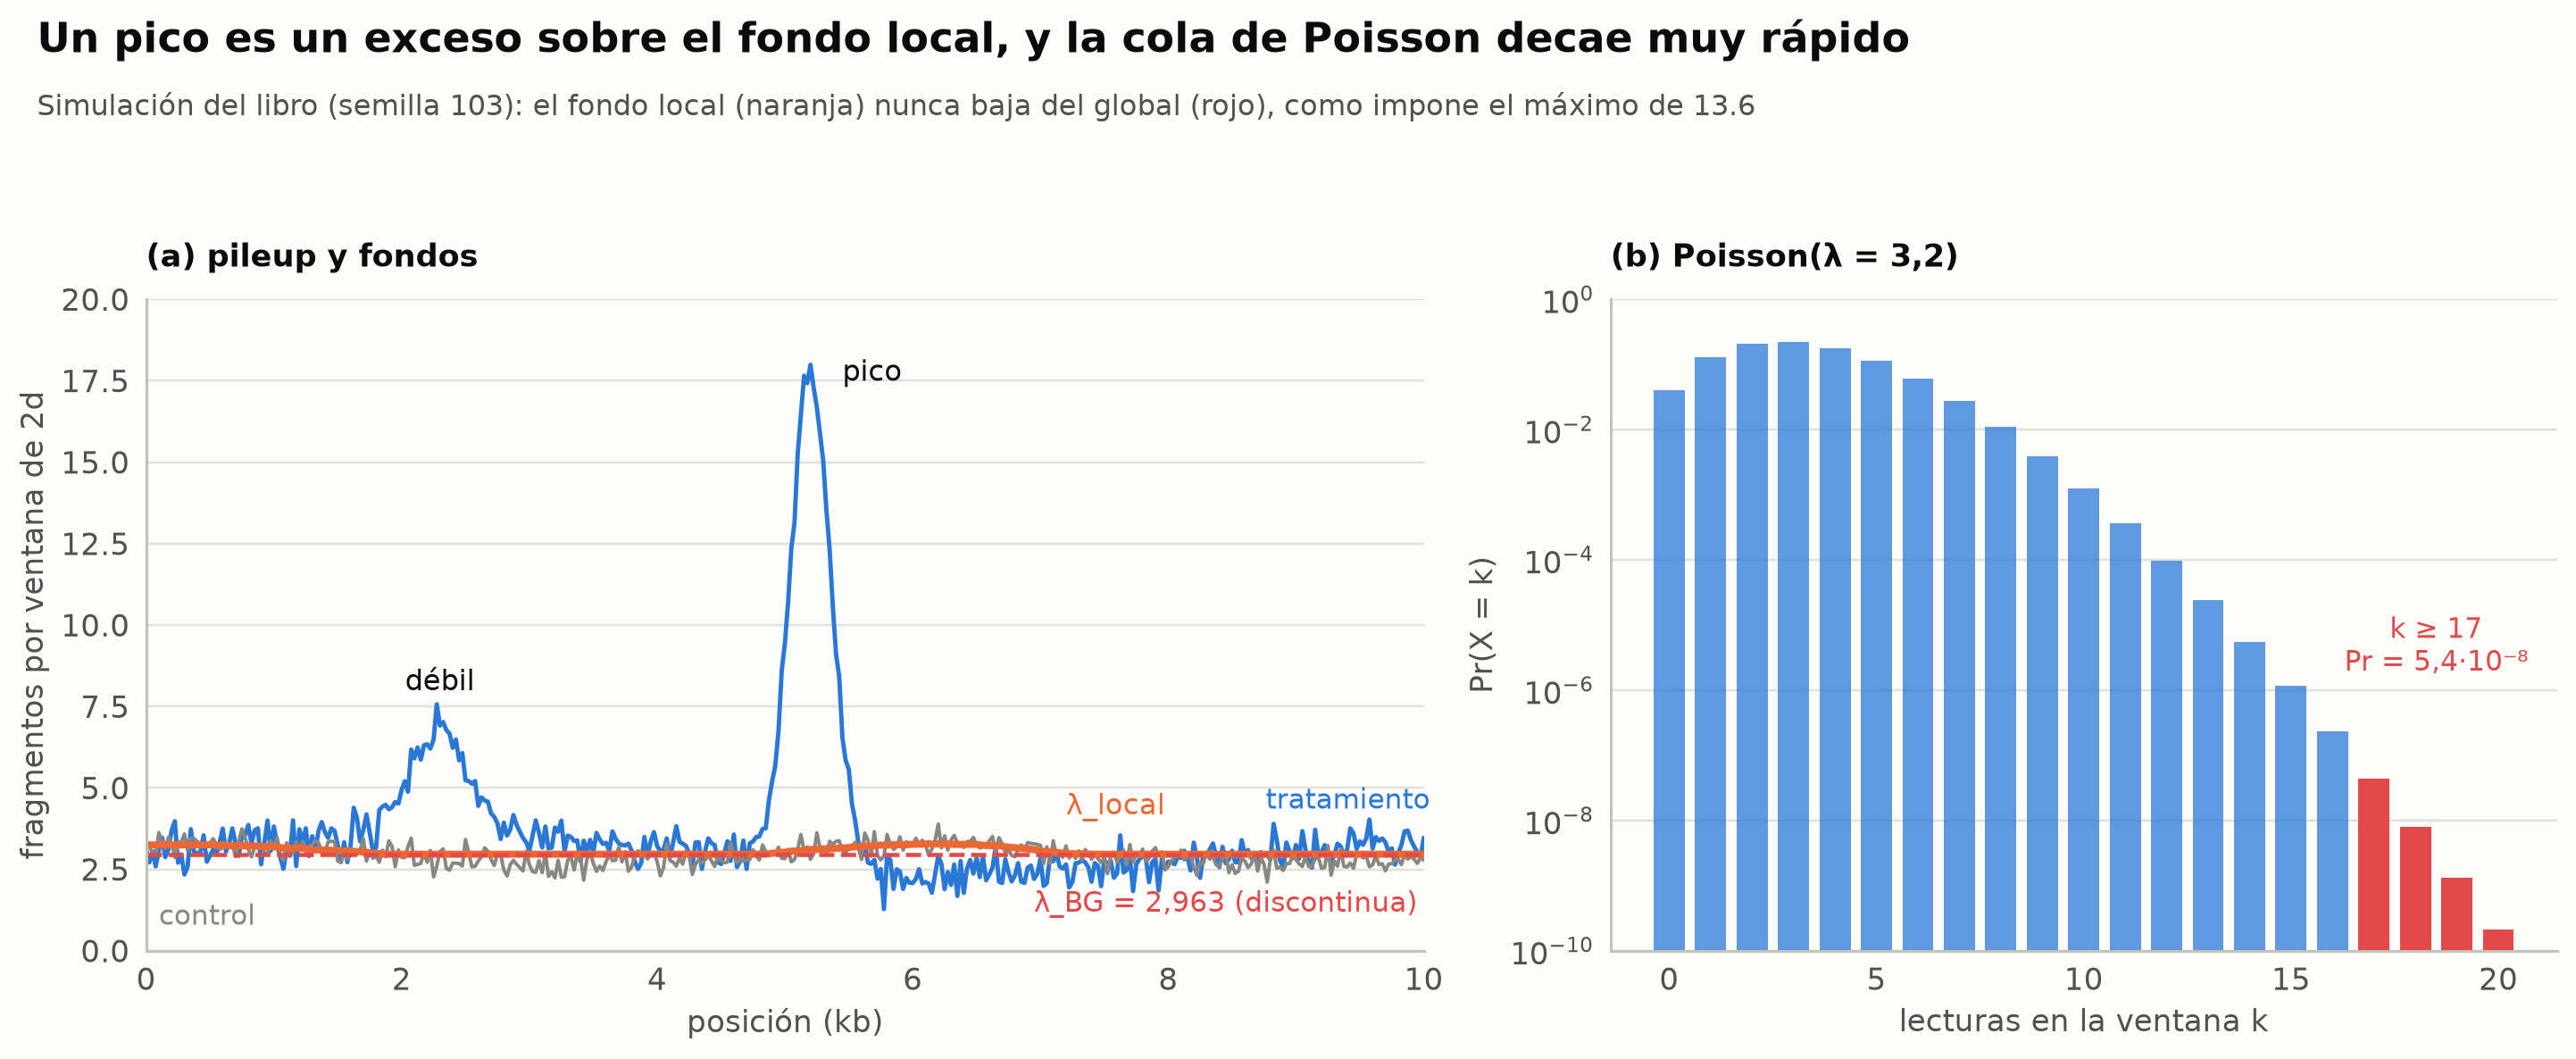

In [19]:
# === Simulación del libro (bloque 13.1-c, semilla 103) ===
rng = np.random.default_rng(103)
xr10 = np.arange(0, 10001, 25)
_bg = rng.poisson(lam_bg * 25 / W2 * 8, xr10.size).astype(float)          # (se consume igual que en el libro)
base = lam_bg + 0.6 * np.sin(xr10 / 1400) + rng.normal(0, 0.35, xr10.size)
pile = base + 15 * np.exp(-0.5 * ((xr10 - 5200) / 160) ** 2) + 3.2 * np.exp(-0.5 * ((xr10 - 2300) / 220) ** 2)
pile = np.clip(pile, 0.2, None)
ctrl = np.clip(lam_bg + 0.3 * np.sin(xr10 / 900 + 1) + 0.25 * rng.normal(size=xr10.size), 0.5, None)
lam_l = np.maximum(lam_bg, np.convolve(ctrl, np.ones(41) / 41, "same"))
lam_l[:20] = lam_l[20]; lam_l[-20:] = lam_l[-21]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.35, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
ax = axes[0]
ax.plot(xr10 / 1000, pile, color=ec.BLUE, lw=1.6)
ax.plot(xr10 / 1000, ctrl, color=ec.MUTED, lw=1.3)
ax.plot(xr10 / 1000, lam_l, color=ec.ORANGE, lw=2.6)
ax.axhline(lam_bg, color=ec.RED, ls="--", lw=1.5)
ax.text(5.45, 17.5, "pico", fontsize=10.5); ax.text(2.3, 8.0, "débil", ha="center", fontsize=10.5)
ax.text(10.05, pile[-1] + 0.9, "tratamiento", color=ec.BLUE, fontsize=10, ha="right")
ax.text(0.1, 0.8, "control", color=ec.MUTED, fontsize=10)
ax.text(7.2, lam_l.max() + 0.9, "λ_local", color=ec.ORANGE, fontsize=10.5)
ax.text(9.95, 1.2, "λ_BG = 2,963 (discontinua)", color=ec.RED, fontsize=10, ha="right")
ax.set_xlim(0, 10); ax.set_ylim(0, 20)
ax.set_xlabel("posición (kb)"); ax.set_ylabel("fragmentos por ventana de 2d")
ax.set_title("(a) pileup y fondos", loc="left", fontsize=11.5)
ax = axes[1]
kk = np.arange(0, 21)
pmf = stats.poisson.pmf(kk, lam_loc)
ax.bar(kk[kk < 17], pmf[kk < 17], color=ec.BLUE, alpha=0.75, width=0.75)
ax.bar(kk[kk >= 17], pmf[kk >= 17], color=ec.RED, width=0.75)
ax.set_yscale("log"); ax.set_ylim(1e-10, 1)
ax.text(18.5, 2e-6, "k ≥ 17\nPr = 5,4·10⁻⁸", color=ec.RED, ha="center", fontsize=10)
ax.set_xlabel("lecturas en la ventana k"); ax.set_ylabel("Pr(X = k)")
ax.set_title("(b) Poisson(λ = 3,2)", loc="left", fontsize=11.5)
ec.fig_title(fig, "Un pico es un exceso sobre el fondo local, y la cola de Poisson decae muy rápido",
             "Simulación del libro (semilla 103): el fondo local (naranja) nunca baja del global (rojo), como impone el máximo de 13.6")
plt.show()

> 🔎 **Qué observamos.** La línea naranja es el fondo local estimado a partir del control suavizado; nunca baja del
> fondo global. En escala logarítmica, la cola de la Poisson cae casi un orden de magnitud por cada lectura adicional:
> **cada lectura extra multiplica la evidencia**. Por eso pequeños errores en $\lambda$ cambian mucho los valores $p$ de
> los picos débiles y casi nada los de los fuertes.

### Un llamador de picos al estilo MACS, con datos reales

Programemos ahora un llamador de picos compacto y apliquémoslo a CTCF. El algoritmo:

1. **Desplazar** cada lectura $d/2$ hacia el centro (con el $\hat d$ de la correlación cruzada).
2. Recorrer el genoma en pasos de 4 pb y **contar** $k$, las lecturas del tratamiento en la ventana de ancho $2d$.
3. Para cada ventana con al menos 5 lecturas, contar las del control en 1, 5 y 10 kb y calcular $\lambda_{\text{local}}$
   con la ecuación 13.6.
4. Calcular $p=\Pr(X\ge k\mid\lambda_{\text{local}})$; declarar significativas las ventanas con $p<10^{-5}$ (el umbral
   original de MACS) y **fusionar** las que se solapan en picos; la **cumbre** es la ventana con menor $p$.

Todas las sumas en ventanas se hacen con **sumas acumuladas** (el conteo en $[a,b)$ es $S(b)-S(a)$), sin bucles.

Una nota sobre $G$: trabajamos con una región de 30 Mb, así que usamos $G=3\times10^7$ y los $N_T$, $N_C$ de la región.
Observe además que aquí el control es **menos profundo** que el tratamiento ($N_T/N_C\approx1{,}78$): cada lectura del
*input* se multiplica por 1,78, lo que hace a $\lambda_{\text{local}}$ más ruidoso (volveremos a esto en "errores
frecuentes").

In [20]:
STEP = 4
def call_peaks(tp, tm, cp_, cm_, d, G, p_thr=1e-5, kmin=5, use_control=True):
    """Llamador de picos tipo MACS (ecuación 13.6). Devuelve un DataFrame de picos y las ventanas evaluadas."""
    half = d // 2
    nt, nc = tp.size + tm.size, cp_.size + cm_.size
    t_cent = np.r_[tp + half, tm - half]                     # lecturas desplazadas d/2 hacia el centro
    c_cent = np.r_[cp_ + half, cm_ - half]
    nb_ = G // STEP
    St = np.r_[0, np.cumsum(np.bincount(np.clip(t_cent, 0, G - 1) // STEP, minlength=nb_))]
    Sc = np.r_[0, np.cumsum(np.bincount(np.clip(c_cent, 0, G - 1) // STEP, minlength=nb_))]
    def wsum(S, idx, width):                                  # lecturas en [centro − width/2, centro + width/2)
        h = width // (2 * STEP)
        return S[np.clip(idx + h, 0, nb_)] - S[np.clip(idx - h, 0, nb_)]
    idx_all = np.arange(nb_)
    k = wsum(St, idx_all, 2 * d)
    cand = np.flatnonzero(k >= kmin)
    kc = k[cand]
    lam_bg_ = nt * 2 * d / G
    lam = np.full(cand.size, lam_bg_)
    if use_control:
        for wp in (1000, 5000, 10000):
            lam = np.maximum(lam, wsum(Sc, cand, wp) * 2 * d / wp * nt / nc)
    p = stats.poisson.sf(kc - 1, lam)
    sig = p < p_thr
    win = pd.DataFrame(dict(center=cand * STEP, k=kc, lam=lam, p=p, sig=sig))
    s_idx = cand[sig]
    if s_idx.size == 0:
        return pd.DataFrame(columns=["start", "end", "summit", "k", "lam", "mlog10p"]), win
    brk = np.flatnonzero(np.diff(s_idx) * STEP > 2 * d) + 1        # ventanas solapadas → mismo pico
    groups = np.split(np.arange(s_idx.size), brk)
    ps, ks_, ls_ = p[sig], kc[sig], lam[sig]
    rows = []
    for g in groups:
        j = g[np.argmin(ps[g])]
        rows.append(dict(start=int(s_idx[g[0]] * STEP - d), end=int(s_idx[g[-1]] * STEP + d),
                         summit=int(s_idx[j] * STEP), k=int(ks_[j]), lam=ls_[j], mlog10p=-np.log10(max(ps[j], 1e-300))))
    return pd.DataFrame(rows), win

t0 = time.time()
peaks_loc, win_loc = call_peaks(T_plus, T_minus, C_plus, C_minus, d_real, G_REG)
peaks_bg, win_bg = call_peaks(T_plus, T_minus, C_plus, C_minus, d_real, G_REG, use_control=False)
lam_bg_real = N_T * 2 * d_real / G_REG
print(f"d̂ = {d_real} pb → ventana 2d = {2 * d_real} pb;  λ_BG = {lam_bg_real:.3f};  N_T/N_C = {N_T / N_C:.2f}")
print(f"Picos con λ_local: {len(peaks_loc)}   ·   con sólo λ_BG: {len(peaks_bg)}   ({time.time() - t0:.1f} s)")
display(peaks_loc.sort_values("mlog10p", ascending=False).head(6).round(2))

d̂ = 164 pb → ventana 2d = 328 pb;  λ_BG = 1.121;  N_T/N_C = 1.78
Picos con λ_local: 793   ·   con sólo λ_BG: 855   (0.4 s)


,start,end,summit,k,lam,mlog10p
240,9626684,9627644,9627160,183,1.52,300.00
417,17419488,17420540,17420016,148,1.63,227.60
122,5514136,5515240,5514724,136,1.12,226.28
502,20632932,20633848,20633408,144,1.75,215.52
666,26035612,26036608,26036124,127,1.28,200.29
397,16624696,16625504,16625064,148,2.68,196.14


Para cada pico, ¿lo encontró también ENCODE (con MACS2 sobre dos réplicas y el filtro IDR)? Marcamos en un vector
booleano las bases cubiertas por los picos de ENCODE y comprobamos el solapamiento. Además aplicamos la **FDR empírica**
de MACS: intercambiamos los papeles de tratamiento y control (con el mismo umbral) y contamos cuántos "picos" aparecen.

In [21]:
def cover_mask(starts, ends, G):
    m = np.zeros(G + 1, np.int32)
    np.add.at(m, np.clip(starts, 0, G), 1); np.add.at(m, np.clip(ends, 0, G), -1)
    return np.cumsum(m)[:G] > 0

enc_mask = cover_mask(enc.start.values, enc.end.values, G_REG)
def overlaps(df, mask):
    cs = np.r_[0, np.cumsum(mask)]
    return (cs[np.clip(df.end.values, 0, G_REG)] - cs[np.clip(df.start.values, 0, G_REG)]) > 0

peaks_loc["en_ENCODE"] = overlaps(peaks_loc, enc_mask)
peaks_bg["en_ENCODE"] = overlaps(peaks_bg, enc_mask)
our_mask = cover_mask(peaks_loc.start.values, peaks_loc.end.values, G_REG)
enc["hallado"] = overlaps(enc, our_mask)
swap, _ = call_peaks(C_plus, C_minus, T_plus, T_minus, d_real, G_REG)      # control frente a tratamiento
print(f"Nuestros picos (λ_local) que solapan un pico IDR de ENCODE: {peaks_loc.en_ENCODE.mean():.1%} de {len(peaks_loc)}")
print(f"Picos IDR de ENCODE recuperados por nuestro llamador: {enc.hallado.mean():.1%} de {len(enc)}")
print(f"Picos sólo con λ_BG que ENCODE no tiene: {(~peaks_bg.en_ENCODE).sum()}  (con λ_local: {(~peaks_loc.en_ENCODE).sum()})")
print(f"FDR empírica (control vs tratamiento): {len(swap)} 'picos' / {len(peaks_loc)} = {len(swap) / len(peaks_loc):.2%}")

Nuestros picos (λ_local) que solapan un pico IDR de ENCODE: 89.3% de 793
Picos IDR de ENCODE recuperados por nuestro llamador: 92.3% de 801
Picos sólo con λ_BG que ENCODE no tiene: 126  (con λ_local: 85)
FDR empírica (control vs tratamiento): 8 'picos' / 793 = 1.01%


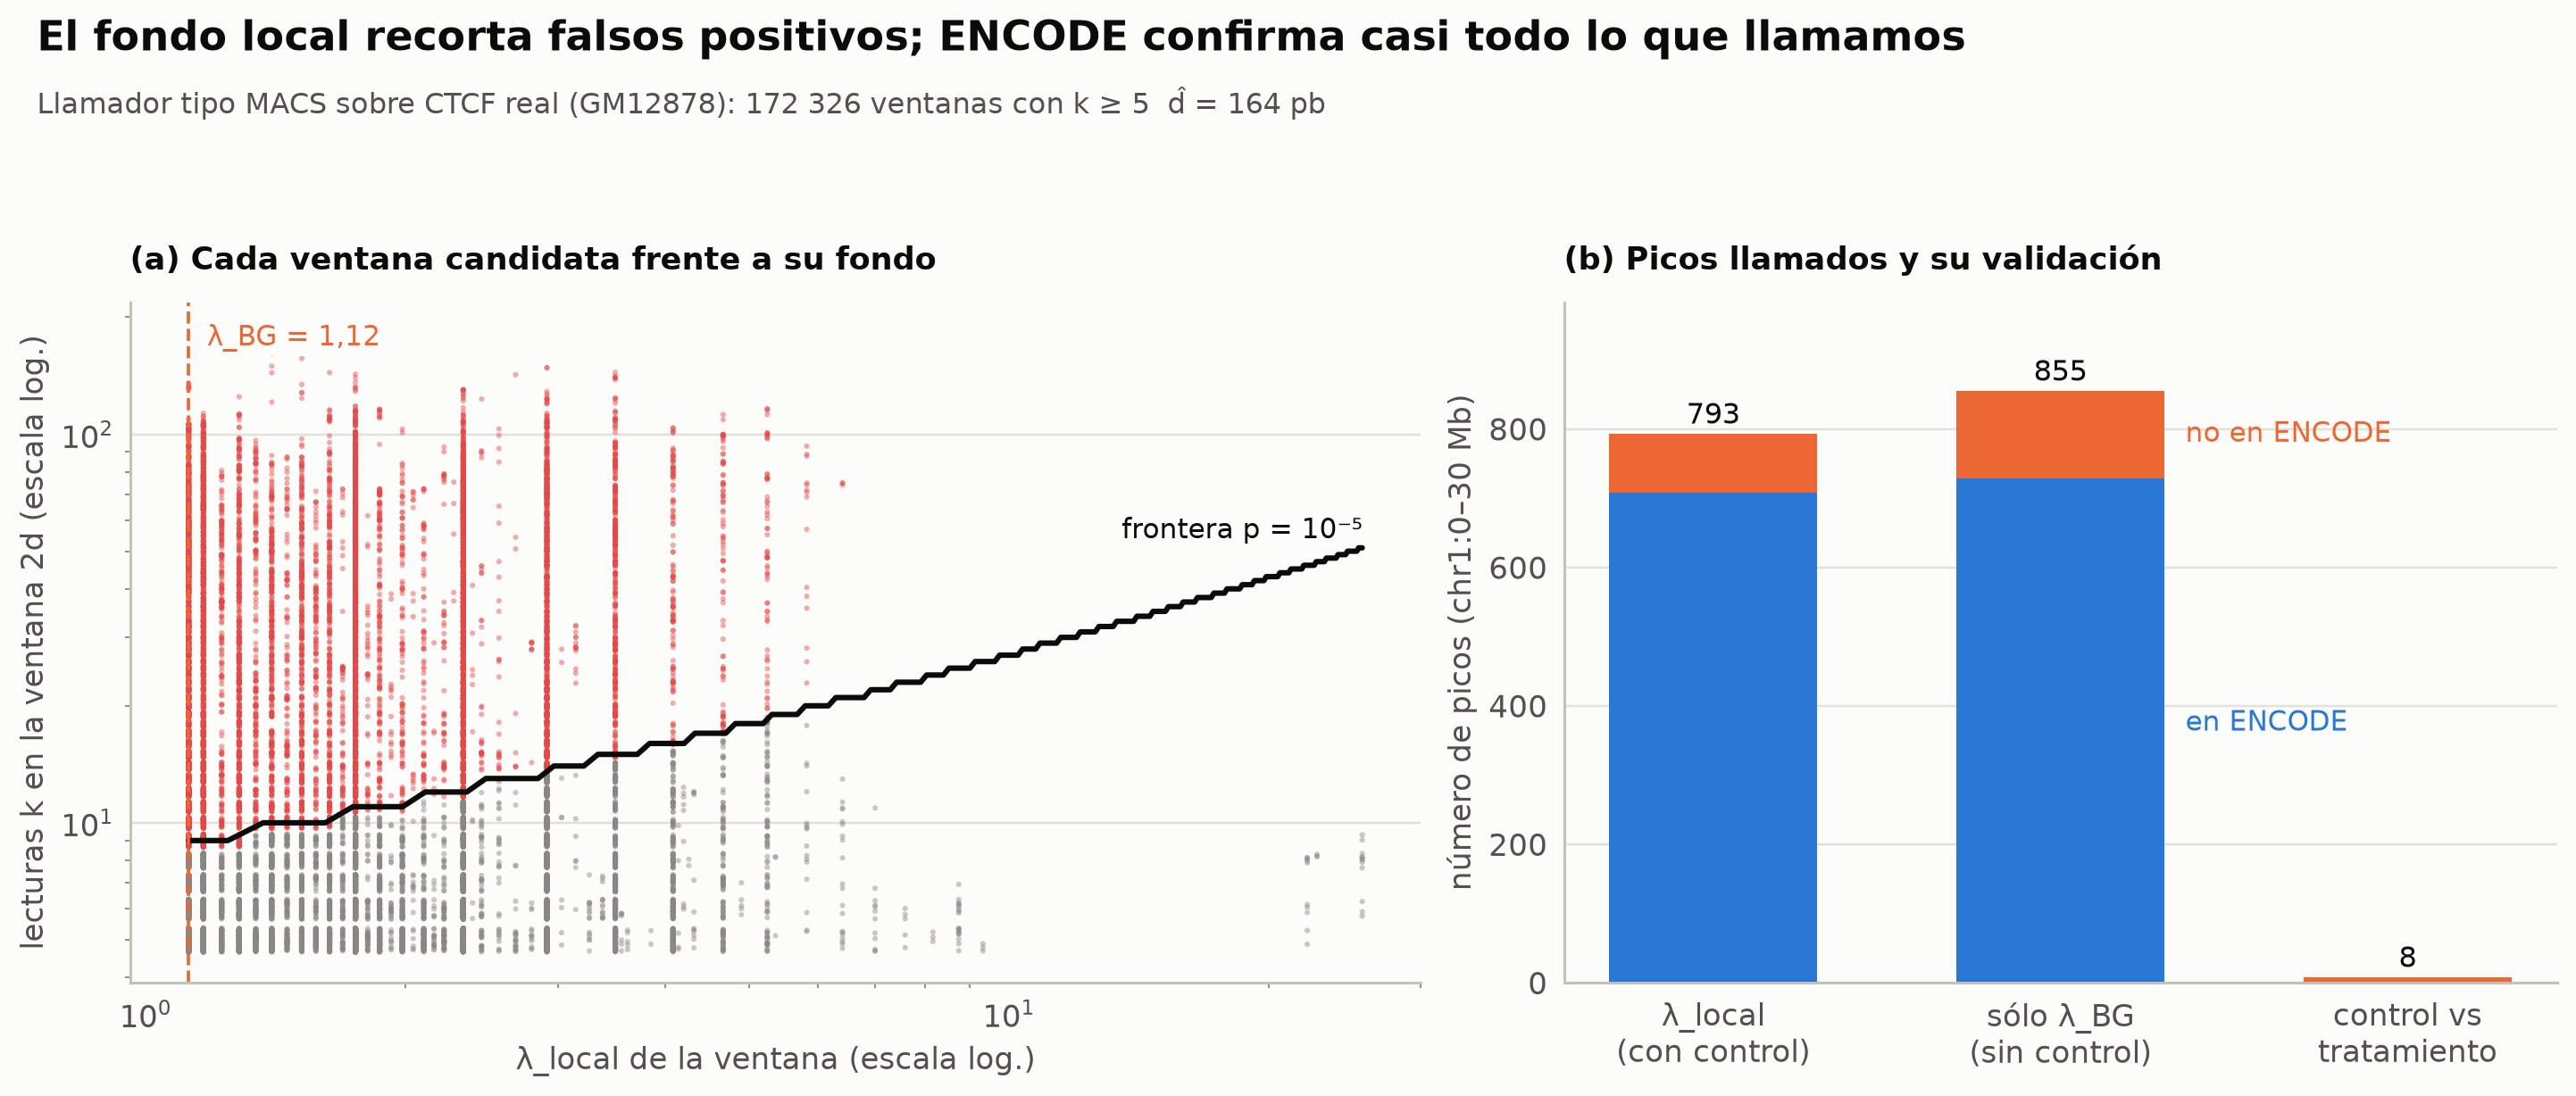

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.3, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
ax = axes[0]
sub = win_loc.sample(min(len(win_loc), 25000), random_state=1)
jit = np.random.default_rng(0).uniform(-0.35, 0.35, len(sub))
ax.scatter(sub.lam, sub.k + jit, s=4, c=np.where(sub.sig, ec.RED, ec.MUTED), alpha=0.45, lw=0)
lg = np.linspace(win_loc.lam.min(), min(win_loc.lam.max(), 30), 200)
kthr = np.array([next(k for k in range(1, 400) if stats.poisson.sf(k - 1, l) < 1e-5) for l in lg])
ax.plot(lg, kthr, color=ec.INK, lw=2)
ax.text(lg[-1], kthr[-1] + 3, "frontera p = 10⁻⁵", ha="right", fontsize=10)
ax.axvline(lam_bg_real, color=ec.ORANGE, ls="--", lw=1.2)
ax.text(lam_bg_real * 1.05, sub.k.max() * 0.93, f"λ_BG = {lam_bg_real:.2f}".replace(".", ","), color=ec.ORANGE, fontsize=10,
        bbox=dict(facecolor=ec.SURFACE, edgecolor="none", pad=1.5), zorder=5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("λ_local de la ventana (escala log.)"); ax.set_ylabel("lecturas k en la ventana 2d (escala log.)")
ax.set_title("(a) Cada ventana candidata frente a su fondo", loc="left", fontsize=11.5)
ax = axes[1]
cats = ["λ_local\n(con control)", "sólo λ_BG\n(sin control)", "control vs\ntratamiento"]
yes = [peaks_loc.en_ENCODE.sum(), peaks_bg.en_ENCODE.sum(), 0]
no = [(~peaks_loc.en_ENCODE).sum(), (~peaks_bg.en_ENCODE).sum(), len(swap)]
ax.bar(cats, yes, color=ec.BLUE, width=0.6)
ax.bar(cats, no, bottom=yes, color=ec.ORANGE, width=0.6)
for i in range(3):
    ax.text(i, yes[i] + no[i] + 15, f"{yes[i] + no[i]}", ha="center", fontsize=10.5)
ax.text(1.36, yes[1] * 0.5, "en ENCODE", color=ec.BLUE, fontsize=10, ha="left")
ax.text(1.36, yes[1] + no[1] * 0.5, "no en ENCODE", color=ec.ORANGE, fontsize=10, ha="left", va="center")
ax.set_ylabel("número de picos (chr1:0–30 Mb)"); ax.set_ylim(0, max(np.add(yes, no)) * 1.15)
ax.set_title("(b) Picos llamados y su validación", loc="left", fontsize=11.5)
ec.fig_title(fig, "El fondo local recorta falsos positivos; ENCODE confirma casi todo lo que llamamos",
             f"Llamador tipo MACS sobre CTCF real (GM12878): {len(win_loc):,} ventanas con k ≥ 5, d̂ = {d_real} pb".replace(",", " "))
plt.show()

> 🔎 **Qué observamos.** (a) Cada punto es una ventana candidata; las rojas superan la frontera $p<10^{-5}$, que sube
> con $\lambda_{\text{local}}$: en regiones con control alto hacen falta más lecturas. (b) Casi todos los picos que llama
> nuestro programa de 60 líneas coinciden con los de ENCODE; la mayor parte de los que no coinciden son débiles (ENCODE
> exige además reproducibilidad entre réplicas). Sin el control, el llamador produce más picos y una proporción mayor de
> ellos no está en ENCODE. Y al intercambiar tratamiento y control apenas aparecen "picos": la FDR empírica es
> minúscula, como corresponde a un anticuerpo excelente.

### Un navegador genómico interactivo

La figura siguiente muestra una ventana real de 60 kb con la señal del tratamiento (lecturas en ventanas de $2d$), el
fondo $\lambda_{\text{local}}$, el fondo global, nuestros picos y los de ENCODE. Pase el ratón por la señal para ver, en
cada posición, $k$, $\lambda_{\text{local}}$ y $-\log_{10}p$.

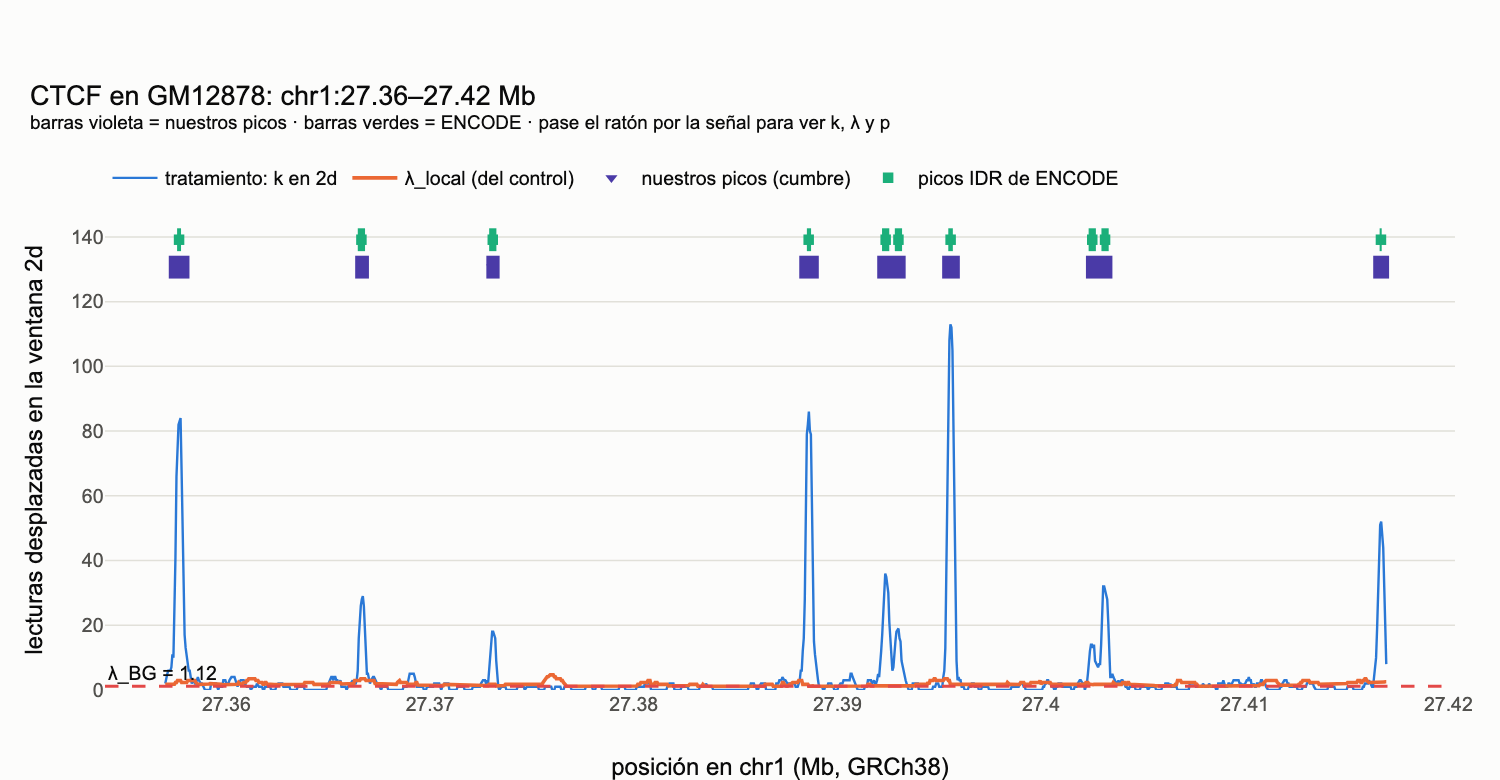

In [23]:
# Ventana de 60 kb con más picos de ENCODE (determinista)
cnt = np.convolve(np.bincount(enc.summit_pos.values // 1000, minlength=G_REG // 1000), np.ones(60), "valid")
b0 = int(np.argmax(cnt)) * 1000
b1 = b0 + 60_000
res = 50
xs_b = np.arange(b0, b1, res)
half = d_real // 2
t_cent = np.sort(np.r_[T_plus + half, T_minus - half]); c_cent = np.sort(np.r_[C_plus + half, C_minus - half])
def count_in(sorted_pos, lo, hi):
    return np.searchsorted(sorted_pos, hi) - np.searchsorted(sorted_pos, lo)
k_b = count_in(t_cent, xs_b - d_real, xs_b + d_real)
lam_b = np.full(xs_b.size, lam_bg_real)
for wp in (1000, 5000, 10000):
    lam_b = np.maximum(lam_b, count_in(c_cent, xs_b - wp // 2, xs_b + wp // 2) * 2 * d_real / wp * N_T / N_C)
mlp = -np.log10(np.clip(stats.poisson.sf(k_b - 1, lam_b), 1e-300, 1))

fig = go.Figure()
fig.add_trace(go.Scatter(x=xs_b / 1e6, y=k_b, mode="lines", name="tratamiento: k en 2d", line=dict(color=ec.BLUE, width=1.6),
    customdata=np.column_stack([lam_b, mlp]),
    hovertemplate="chr1:%{x:.4f} Mb<br>k = %{y} lecturas en 2d<br>λ_local = %{customdata[0]:.2f}"
                  "<br>−log10 p = %{customdata[1]:.1f}<br>(pico si −log10 p > 5)<extra></extra>"))
fig.add_trace(go.Scatter(x=xs_b / 1e6, y=lam_b, mode="lines", name="λ_local (del control)",
    line=dict(color=ec.ORANGE, width=2.4), hovertemplate="λ_local = %{y:.2f}<br>máx(λ_BG, λ_1k, λ_5k, λ_10k)<extra></extra>"))
fig.add_hline(y=lam_bg_real, line=dict(color=ec.RED, dash="dash"), annotation_text=f"λ_BG = {lam_bg_real:.2f}",
              annotation_position="top left")
ymax = k_b.max() * 1.25
for _, r in peaks_loc[(peaks_loc.end > b0) & (peaks_loc.start < b1)].iterrows():
    fig.add_shape(type="rect", x0=r.start / 1e6, x1=r.end / 1e6, y0=ymax * 0.90, y1=ymax * 0.95,
                  fillcolor=ec.VIOLET, line_width=0)
for _, r in enc[(enc.end > b0) & (enc.start < b1)].iterrows():
    fig.add_shape(type="rect", x0=r.start / 1e6, x1=r.end / 1e6, y0=ymax * 0.96, y1=ymax * 1.01,
                  fillcolor=ec.AQUA, line_width=0)
pk_in = peaks_loc[(peaks_loc.end > b0) & (peaks_loc.start < b1)]
fig.add_trace(go.Scatter(x=pk_in.summit / 1e6, y=np.full(len(pk_in), ymax * 0.925), mode="markers",
    marker=dict(color=ec.VIOLET, size=7, symbol="triangle-down"), name="nuestros picos (cumbre)",
    customdata=np.column_stack([pk_in.k, pk_in.lam, pk_in.mlog10p, pk_in.en_ENCODE.map({True: "sí", False: "no"})]),
    hovertemplate="cumbre chr1:%{x:.5f} Mb<br>k = %{customdata[0]}<br>λ_local = %{customdata[1]:.2f}"
                  "<br>−log10 p = %{customdata[2]:.1f}<br>¿en ENCODE? %{customdata[3]}<extra></extra>"))
en_in = enc[(enc.end > b0) & (enc.start < b1)]
fig.add_trace(go.Scatter(x=en_in.summit_pos / 1e6, y=np.full(len(en_in), ymax * 0.985), mode="markers",
    marker=dict(color=ec.AQUA, size=7, symbol="square"), name="picos IDR de ENCODE",
    customdata=np.column_stack([en_in.signal, 10 ** -en_in.global_idr]),
    hovertemplate="ENCODE chr1:%{x:.5f} Mb<br>señal = %{customdata[0]:.0f}<br>IDR global = %{customdata[1]:.1e}<extra></extra>"))
fig.update_layout(
    title=f"CTCF en GM12878: chr1:{b0/1e6:.2f}–{b1/1e6:.2f} Mb"
          "<br><sup>barras violeta = nuestros picos · barras verdes = ENCODE · pase el ratón por la señal para ver k, λ y p</sup>",
    xaxis_title="posición en chr1 (Mb, GRCh38)", yaxis_title="lecturas desplazadas en la ventana 2d",
    yaxis_range=[0, ymax * 1.05], height=520, hovermode="closest",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=140, l=70, r=30, b=60))
fig.show()

## 6. Calidad y reproducibilidad

Una lista de picos no vale nada si no se sabe cuánto de ella es señal. Tres controles se han vuelto estándar.

### FRiP: la fracción de lecturas en picos

La **fracción de lecturas en picos** (*fraction of reads in peaks*) es el cociente entre las lecturas que caen dentro de
los picos llamados y el total:

$$
\mathrm{FRiP}=\frac{\#\{\text{lecturas dentro de algún pico}\}}{N}.
$$

Mide la relación señal/ruido del experimento completo. **Ejemplo del libro:** si 3,1 millones de 20 millones de
lecturas caen en picos, $\mathrm{FRiP}=3{,}1/20=0{,}155$. Las guías de ENCODE consideran aceptable, para factores de
transcripción, un FRiP del **1 % o más**; los buenos experimentos con factores abundantes como CTCF superan con
holgura esa cifra (Landt et al., 2012).

> 🤔 **Antes de ejecutar, prediga…** Los picos de ENCODE ocupan menos del 1 % de las bases de nuestra región. Si el
> *input* no tiene señal específica, ¿qué FRiP tendrá el control en esos mismos picos?

In [24]:
print(f"Ejemplo del libro: FRiP = 3,1e6 / 20e6 = {3.1e6 / 20e6:.3f}")
def frip(p5_plus, p5_minus, d, mask):
    cen = np.clip(np.r_[p5_plus + d // 2, p5_minus - d // 2], 0, G_REG - 1)
    return mask[cen].mean()
frac_bp_enc, frac_bp_our = enc_mask.mean(), our_mask.mean()
tab = pd.DataFrame({
    "picos": ["ENCODE IDR ≤ 0,05", "nuestro llamador (λ_local)"],
    "n": [len(enc), len(peaks_loc)],
    "% de bases cubiertas": [100 * frac_bp_enc, 100 * frac_bp_our],
    "FRiP CTCF": [frip(T_plus, T_minus, d_real, enc_mask), frip(T_plus, T_minus, d_real, our_mask)],
    "FRiP input": [frip(C_plus, C_minus, d_real, enc_mask), frip(C_plus, C_minus, d_real, our_mask)]})
display(tab.style.format({"% de bases cubiertas": "{:.2f}", "FRiP CTCF": "{:.3f}", "FRiP input": "{:.3f}"}).hide(axis="index"))

Ejemplo del libro: FRiP = 3,1e6 / 20e6 = 0.155


picos,n,% de bases cubiertas,FRiP CTCF,FRiP input
"ENCODE IDR ≤ 0,05",801,0.78,0.299,0.011
nuestro llamador (λ_local),793,1.98,0.395,0.026


> 🔎 **Qué observamos.** En esta región, casi **un 30 %** de las lecturas de CTCF caen en picos que ocupan menos del
> 1 % de las bases: un enriquecimiento de unas cuarenta veces, muy por encima del 1 % exigido. El *input*, en cambio,
> pone en esos picos aproximadamente la misma fracción que la de bases que cubren (algo más del 1 %): no tiene señal
> específica. Advertencia: es un FRiP **regional** (30 Mb de la banda 1p36, muy rica en genes y en sitios de CTCF), una
> aproximación del FRiP genómico que calcula ENCODE sobre todo el genoma.

### La lista negra de ENCODE

Algunas regiones del genoma (repeticiones satélite cerca de centrómeros y telómeros, ADN ribosómico, secuencias con
copias no representadas en la referencia) producen señal alta en **cualquier** experimento de secuenciación,
independientemente del tipo celular o del anticuerpo. Amemiya et al. (2019) definieron la **lista negra de ENCODE** y
recomiendan eliminar sus regiones antes de cualquier análisis. En nuestra región hay cuatro; la mayor, en
chr1:628 903–635 104, contiene una copia nuclear de ADN **mitocondrial** (un NUMT): las lecturas del abundantísimo ADN
mitocondrial que se parecen a ella se mapean allí.

In [25]:
bl = pd.read_csv(io.BytesIO(course_bytes("131_encode_blacklist_hg38_chr1_0-30Mb.bed")), sep="\t", comment="#",
                 header=None, usecols=[0, 1, 2], names=["chrom", "start", "end"])
rows = []
for _, r in bl.iterrows():
    L_ = r.end - r.start
    t_obs = count_in(np.sort(np.r_[T_plus, T_minus]), r.start, r.end)
    c_obs = count_in(np.sort(np.r_[C_plus, C_minus]), r.start, r.end)
    rows.append(dict(region=f"{r.chrom}:{r.start:,}-{r.end:,}", pb=L_,
                     CTCF_obs=t_obs, CTCF_esp=round(N_T * L_ / G_REG, 1),
                     input_obs=c_obs, input_esp=round(N_C * L_ / G_REG, 1)))
bl_tab = pd.DataFrame(rows)
display(bl_tab)
bl_mask = cover_mask(bl.start.values, bl.end.values, G_REG)
print("Picos (λ_local) que tocan la lista negra:", int(overlaps(peaks_loc, bl_mask).sum()),
      "·  picos (sólo λ_BG) que la tocan:", int(overlaps(peaks_bg, bl_mask).sum()))

,region,pb,CTCF_obs,CTCF_esp,input_obs,input_esp
0,"chr1:628,903-635,104",6201,24,21.2,89,11.9
1,"chr1:5,850,087-5,850,571",484,1,1.7,1,0.9
2,"chr1:8,909,610-8,910,014",404,0,1.4,1,0.8
3,"chr1:9,574,580-9,574,997",417,1,1.4,5,0.8


Picos (λ_local) que tocan la lista negra: 0 ·  picos (sólo λ_BG) que la tocan: 1


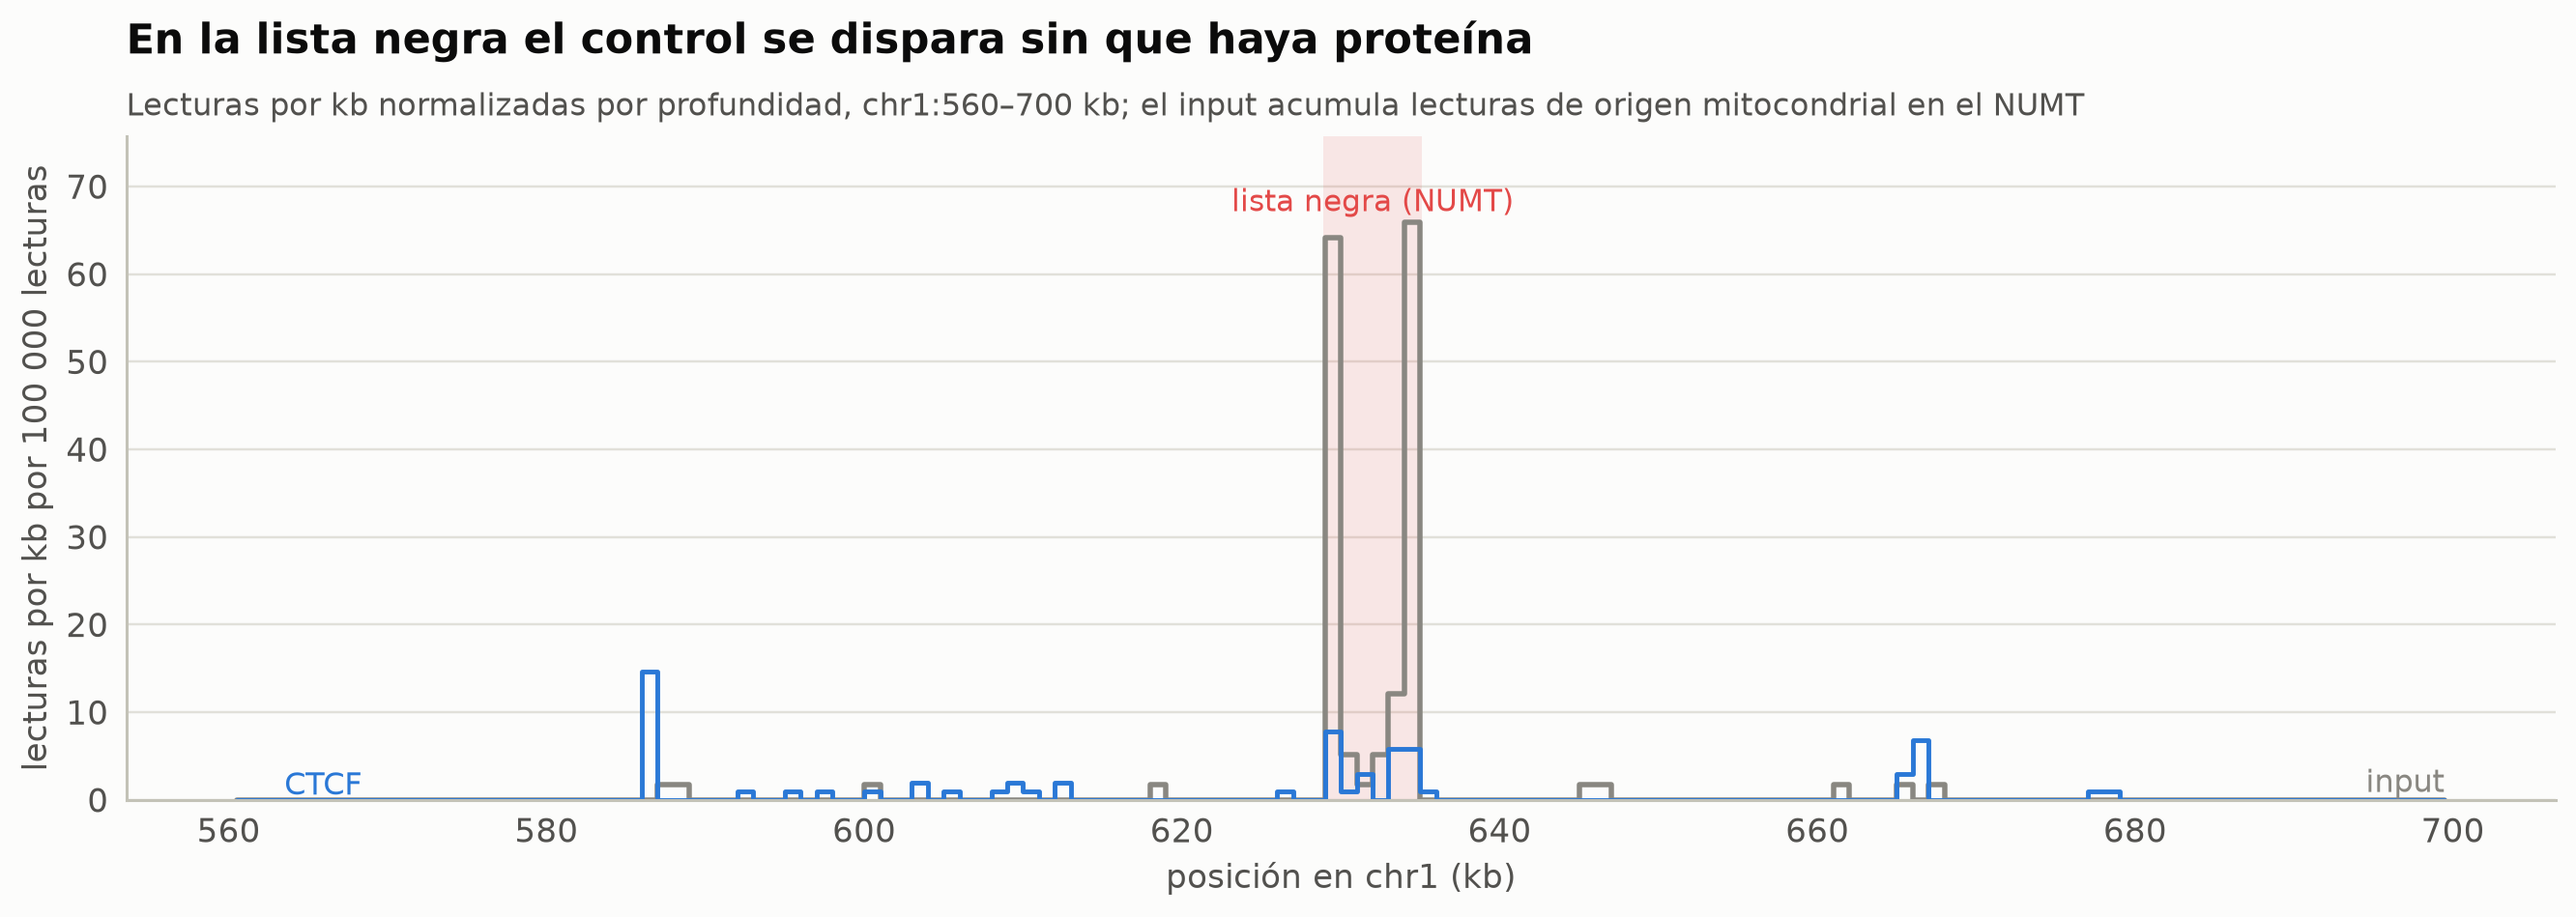

In [26]:
lo_, hi_ = 560_000, 700_000
edges_b = np.arange(lo_, hi_ + 1, 1000)
ht = np.histogram(np.r_[T_plus, T_minus], edges_b)[0] / (N_T / 1e5)
hc = np.histogram(np.r_[C_plus, C_minus], edges_b)[0] / (N_C / 1e5)
fig, ax = plt.subplots(figsize=(12, 4.2))
xm = (edges_b[:-1] + 500) / 1e3
ax.step(xm, hc, where="mid", color=ec.MUTED, lw=1.8)
ax.step(xm, ht, where="mid", color=ec.BLUE, lw=1.6)
for _, r in bl.iterrows():
    if r.end > lo_ and r.start < hi_:
        ax.axvspan(r.start / 1e3, r.end / 1e3, color=ec.RED, alpha=0.12, lw=0)
        ax.text((r.start + r.end) / 2e3, max(hc.max(), ht.max()) * 1.02, "lista negra (NUMT)", color=ec.RED,
                ha="center", fontsize=10)
ax.text(xm[-1], hc[-12:].mean() + 0.9, "input", color=ec.MUTED, ha="right", fontsize=10.5)
ax.text(xm[3], ht[:8].max() + 0.6, "CTCF", color=ec.BLUE, fontsize=10.5)
ax.set_ylim(0, max(hc.max(), ht.max()) * 1.15)
ax.set_xlabel("posición en chr1 (kb)"); ax.set_ylabel("lecturas por kb por 100 000 lecturas")
ec.title(ax, "En la lista negra el control se dispara sin que haya proteína",
         "Lecturas por kb normalizadas por profundidad, chr1:560–700 kb; el input acumula lecturas de origen mitocondrial en el NUMT")
plt.show()

> 🔎 **Qué observamos.** En el NUMT el *input* acumula varias veces más lecturas de las esperadas. Gracias al
> $\lambda_{\text{local}}$, ese exceso del control **eleva el umbral** en la región, y ninguna señal allí se convierte en
> pico; pero un llamador sin control, o con un control distinto, podría llamar picos en ella. Por eso la lista negra
> se filtra **siempre**, con o sin control.

### IDR: la tasa de irreproducibilidad

Dos **réplicas biológicas** de un mismo experimento deberían coincidir en sus picos fuertes y discrepar en los
débiles, que son ruido. Li et al. (2011) formalizaron esta intuición en la **tasa de irreproducibilidad**
(*irreproducible discovery rate*, IDR). Su modelo supone que cada pico pertenece a uno de dos grupos:

* **reproducible**, cuyas puntuaciones en las dos réplicas están correlacionadas y son altas, o
* **irreproducible**, cuyas puntuaciones son independientes.

Las puntuaciones se transforman en **rangos** (para no depender de la escala de cada llamador de picos) y una
**mezcla de dos cópulas gaussianas** se ajusta por EM, el mismo algoritmo que veremos en la Lección 13.3. Para cada
pico $i$ se obtiene la probabilidad posterior de ser irreproducible, $\mathrm{idr}_i$, y para una lista de los picos
más fuertes $S_\gamma$,

$$
\mathrm{IDR}(\gamma) = \frac{1}{|S_\gamma|}\sum_{i\in S_\gamma}\mathrm{idr}_i ,
\tag{13.7}
$$

| Símbolo | Significado |
|---|---|
| $\mathrm{idr}_i$ | probabilidad posterior, según la mezcla, de que el pico $i$ pertenezca al grupo irreproducible |
| $S_\gamma$ | conjunto de picos seleccionados con el umbral $\gamma$ (p. ej., los que tienen $\mathrm{idr}_i\le\gamma$) |

que es el análogo exacto de la tasa de falsos descubrimientos: **la fracción esperada de picos irreproducibles en la
lista**. ENCODE llama picos de forma permisiva en cada réplica y conserva los que superan el umbral elegido
(típicamente 0,05).

**Un ejemplo a mano.** Si los cinco picos más fuertes tienen $\mathrm{idr}=(0{,}001;\ 0{,}002;\ 0{,}01;\ 0{,}03;\ 0{,}20)$,
la lista de los cuatro primeros tiene $\mathrm{IDR}=(0{,}001+0{,}002+0{,}01+0{,}03)/4\approx0{,}011$ y la de los cinco,
$0{,}243/5\approx0{,}049$: con $\gamma=0{,}05$ podríamos quedarnos con los cinco, aunque el quinto, por separado, tenga
un 20 % de probabilidad de ser ruido. La IDR controla la **lista**, no cada pico.

Ojo con los dos umbrales, que se escriben igual. En la tabla, $S_\gamma$ se define (como en el libro) con el umbral sobre
cada $\mathrm{idr}_i$: con ese criterio y $\gamma=0{,}05$ el quinto pico quedaría **fuera**. El umbral 0,05 de ENCODE,
en cambio, se aplica al **IDR global** de la ecuación 13.7: se ordenan los picos de más fuerte a más débil y se conservan
mientras la media acumulada de $\mathrm{idr}_i$ no pase de 0,05. Es lo que hace el ejemplo a mano y lo que calcula
nuestro código (la columna `IDR`, la media acumulada), y es también la columna *global IDR* que publica ENCODE.

Reproducimos la simulación del libro (semilla 104): **1500 picos reales** (puntuación compartida + ruido pequeño en
cada réplica) y **2500 de ruido** (puntuaciones independientes).

In [27]:
# === Simulación del libro (bloque 13.1-d, semilla 104) ===
rng = np.random.default_rng(104)
n_true, n_false = 1500, 2500
s_true = rng.normal(0, 1, n_true)
r1t = s_true + rng.normal(0, 0.35, n_true) + 2.6
r2t = s_true + rng.normal(0, 0.35, n_true) + 2.6
r1f = rng.normal(0, 1, n_false); r2f = rng.normal(0, 1, n_false)
s1 = np.concatenate([r1t, r1f]); s2 = np.concatenate([r2t, r2f])
rk1, rk2 = stats.rankdata(-s1), stats.rankdata(-s2)          # rango 1 = pico más fuerte
etiq = np.r_[np.ones(n_true), np.zeros(n_false)]
rho = stats.spearmanr(rk1, rk2).statistic
top = (rk1 <= 1000) & (rk2 <= 1000)
print(f"Spearman global = {rho:.2f};  entre los 1000 primeros de ambas réplicas: {top.sum()} picos, "
      f"verdaderos = {int(etiq[top].sum())}")
print("Libro: Spearman 0,70; 857 picos, todos verdaderos")

Spearman global = 0.70;  entre los 1000 primeros de ambas réplicas: 857 picos, verdaderos = 857
Libro: Spearman 0,70; 857 picos, todos verdaderos


Ahora implementamos el modelo. Llamemos $u_{i1},u_{i2}\in(0,1)$ a los rangos normalizados del pico $i$ en cada réplica
(1 = el más fuerte). El modelo de Li et al. dice que existen valores latentes $(z_{i1},z_{i2})$, con
$u_{ir}=\Psi(z_{ir})$, que siguen una mezcla

$$
(z_{i1},z_{i2}) \sim \pi_1\,\mathcal N_2\!\left(\begin{pmatrix}\mu\\\mu\end{pmatrix},
\begin{pmatrix}\sigma^2&\rho\sigma^2\\\rho\sigma^2&\sigma^2\end{pmatrix}\right) + (1-\pi_1)\,\mathcal N_2(\mathbf 0, I),
$$

donde $\Psi(z)=\pi_1\Phi\!\left(\frac{z-\mu}{\sigma}\right)+(1-\pi_1)\Phi(z)$ es la marginal de la mezcla. El algoritmo alterna:
(i) calcular los **pseudovalores** $z_{ir}=\Psi^{-1}(u_{ir})$ con los parámetros actuales; (ii) un paso E: la probabilidad
posterior de pertenecer al grupo reproducible; (iii) un paso M: medias, varianzas y correlación ponderadas. Al
final, $\mathrm{idr}_i$ es la posterior del grupo irreproducible. Nuestra versión es **simplificada** (un paso E/M por
cada actualización de pseudovalores y una única $\sigma$ para ambas réplicas); el programa oficial `idr` de ENCODE
optimiza la verosimilitud completa, pero la lógica es idéntica.

| Símbolo | Significado |
|---|---|
| $\pi_1$ | proporción de picos reproducibles |
| $\mu,\ \sigma,\ \rho$ | media, desviación típica y correlación del grupo reproducible (en la escala latente) |
| $\Phi$, $\Psi$ | función de distribución normal estándar y marginal de la mezcla |

In [28]:
def fit_idr(x1, x2, n_iter=100, pi=0.5, mu=2.0, sig=1.0, rho=0.7):
    """IDR simplificado (Li et al., 2011): mezcla de cópulas gaussianas ajustada por EM con pseudovalores.
    x1, x2: puntuaciones (mayor = más fuerte). Devuelve idr_i, IDR (13.7) de cada pico y los parámetros."""
    n = len(x1)
    u1 = stats.rankdata(x1) / (n + 1); u2 = stats.rankdata(x2) / (n + 1)
    hist = []
    for _ in range(n_iter):
        grid = np.linspace(-8, mu + 8 * sig, 4000)
        Psi = pi * stats.norm.cdf((grid - mu) / sig) + (1 - pi) * stats.norm.cdf(grid)
        z1, z2 = np.interp(u1, Psi, grid), np.interp(u2, Psi, grid)          # pseudovalores
        cov = sig ** 2 * np.array([[1, rho], [rho, 1]])
        f1 = stats.multivariate_normal([mu, mu], cov).pdf(np.column_stack([z1, z2]))
        f0 = stats.norm.pdf(z1) * stats.norm.pdf(z2)
        w = pi * f1 / (pi * f1 + (1 - pi) * f0)                                # paso E
        pi = w.mean()                                                           # paso M
        mu = (w * (z1 + z2)).sum() / (2 * w.sum())
        sig = np.sqrt((w * ((z1 - mu) ** 2 + (z2 - mu) ** 2)).sum() / (2 * w.sum()))
        rho = np.clip((w * (z1 - mu) * (z2 - mu)).sum() / (sig ** 2 * w.sum()), -0.99, 0.99)
        hist.append((pi, mu, sig, rho))
    idr = 1 - w
    order = np.argsort(idr)
    IDR = np.empty(n); IDR[order] = np.cumsum(idr[order]) / np.arange(1, n + 1)   # ecuación 13.7
    return idr, IDR, dict(pi=pi, mu=mu, sigma=sig, rho=rho), np.array(hist)

idr_sim, IDR_sim, par_sim, hist_sim = fit_idr(s1, s2)
sel = IDR_sim <= 0.05
print("Parámetros:", {k: round(v, 3) for k, v in par_sim.items()}, "(verdad: π₁ = 1500/4000 = 0,375)")
print(f"Lista con IDR ≤ 0,05: {sel.sum()} picos; verdaderos {int(etiq[sel].sum())} "
      f"(proporción de falsos = {1 - etiq[sel].mean():.3f}; recuperados {etiq[sel].sum() / n_true:.1%} de los 1500 reales)")

Parámetros: {'pi': np.float64(0.377), 'mu': np.float64(2.482), 'sigma': np.float64(0.96), 'rho': np.float64(0.888)} (verdad: π₁ = 1500/4000 = 0,375)
Lista con IDR ≤ 0,05: 1467 picos; verdaderos 1386 (proporción de falsos = 0.055; recuperados 92.4% de los 1500 reales)


Ahora con **datos reales**: el archivo de ENCODE `ENCFF559WJC` contiene los 82 105 picos candidatos de CTCF con la
señal de cada réplica (`rep1_signal`, `rep2_signal`) y el IDR que calculó el programa oficial. Ajustamos nuestro
modelo a esas mismas puntuaciones y comparamos.

In [29]:
t0 = time.time()
x1r, x2r = peaks_all.rep1_signal.values, peaks_all.rep2_signal.values
idr_real, IDR_real, par_real, hist_real = fit_idr(x1r, x2r, n_iter=60)
IDR_enc = 10 ** (-peaks_all.global_idr.values)               # ENCODE guarda −log10(IDR)
print(f"Spearman entre réplicas (82 105 picos): {stats.spearmanr(x1r, x2r).statistic:.3f}")
print("Parámetros ajustados:", {k: round(v, 3) for k, v in par_real.items()})
print(f"Picos con IDR ≤ 0,05 — nuestro modelo: {(IDR_real <= 0.05).sum():,}   ENCODE: {(IDR_enc <= 0.05).sum():,}")
both = (IDR_real <= 0.05) & (IDR_enc <= 0.05)
print(f"Coinciden {both.sum():,} picos; Spearman entre nuestro IDR y el de ENCODE: "
      f"{stats.spearmanr(IDR_real, IDR_enc).statistic:.3f}   ({time.time() - t0:.1f} s)")

Spearman entre réplicas (82 105 picos): 0.874
Parámetros ajustados: {'pi': np.float64(0.486), 'mu': np.float64(2.471), 'sigma': np.float64(0.722), 'rho': np.float64(0.936)}
Picos con IDR ≤ 0,05 — nuestro modelo: 41,337   ENCODE: 41,978
Coinciden 41,337 picos; Spearman entre nuestro IDR y el de ENCODE: 0.959   (1.1 s)


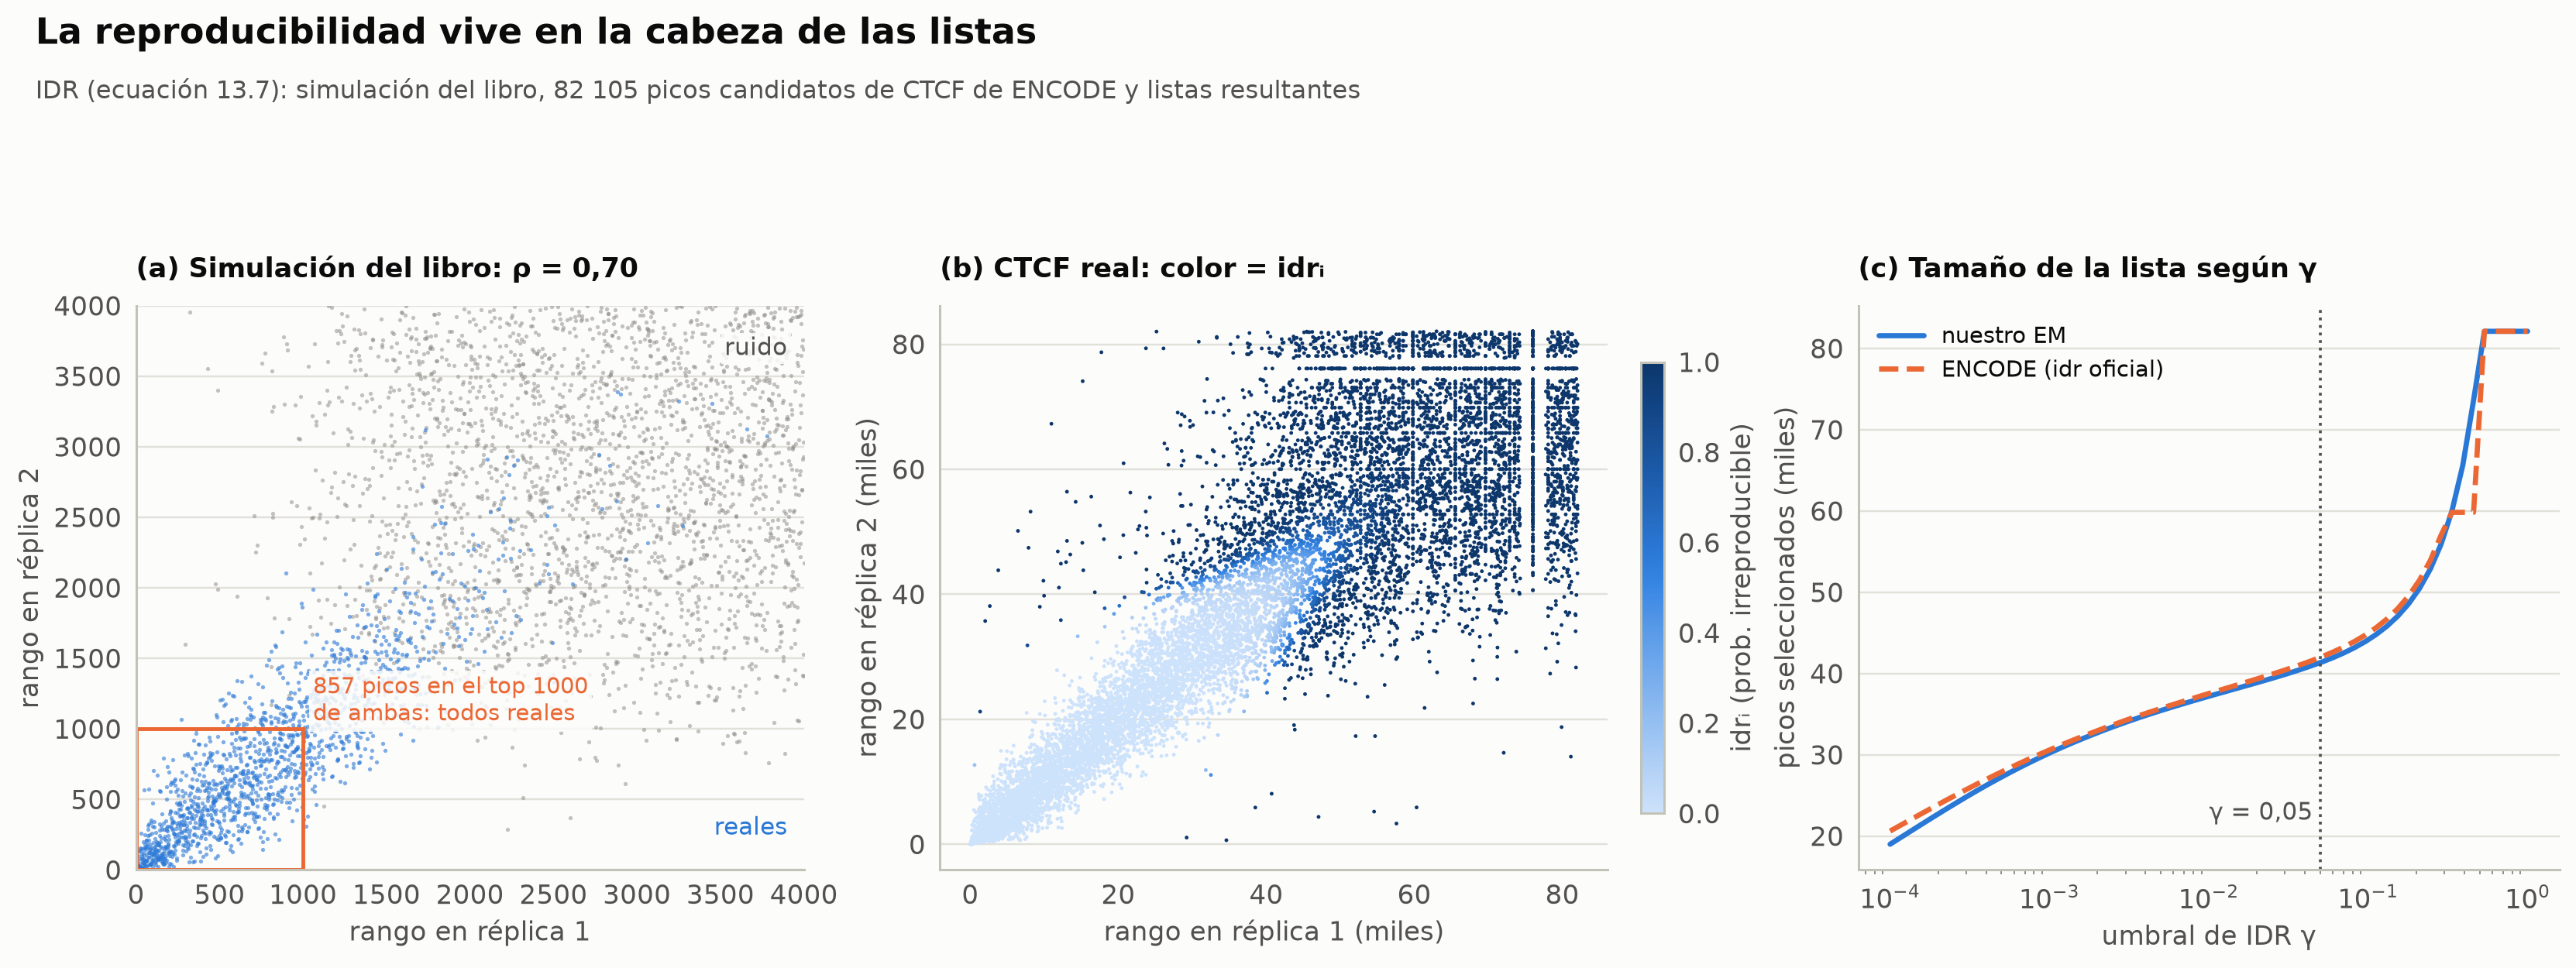

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9), gridspec_kw=dict(width_ratios=[1, 1, 1.05]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.85))
ax = axes[0]
ax.scatter(rk1[etiq == 0], rk2[etiq == 0], s=3, color=ec.MUTED, alpha=0.5, lw=0)
ax.scatter(rk1[etiq == 1], rk2[etiq == 1], s=3, color=ec.BLUE, alpha=0.6, lw=0)
ax.add_patch(Rectangle((0, 0), 1000, 1000, fill=False, ec=ec.ORANGE, lw=1.6))
ax.text(1060, 1060, "857 picos en el top 1000\nde ambas: todos reales", color=ec.ORANGE, fontsize=9.5,
        bbox=dict(facecolor=ec.SURFACE, edgecolor="none", alpha=0.85, pad=1.5), zorder=5)
ax.text(3900, 250, "reales", color=ec.BLUE, ha="right", fontsize=10); ax.text(3900, 3650, "ruido", color=ec.INK_2, ha="right", fontsize=10,
        bbox=dict(facecolor=ec.SURFACE, edgecolor="none", alpha=0.85, pad=1.5), zorder=5)
ax.set_xlabel("rango en réplica 1"); ax.set_ylabel("rango en réplica 2"); ax.set_xlim(0, 4000); ax.set_ylim(0, 4000)
ax.set_title("(a) Simulación del libro: ρ = 0,70", loc="left", fontsize=11.5)
ax = axes[1]
n_r = len(x1r)
sub = np.random.default_rng(1).choice(n_r, 12000, replace=False)
rr1, rr2 = stats.rankdata(-x1r), stats.rankdata(-x2r)
scp = ax.scatter(rr1[sub] / 1000, rr2[sub] / 1000, s=2.5, c=idr_real[sub], cmap="curso_seq", vmin=0, vmax=1, lw=0)
ax.set_xlabel("rango en réplica 1 (miles)"); ax.set_ylabel("rango en réplica 2 (miles)")
ax.set_title("(b) CTCF real: color = idrᵢ", loc="left", fontsize=11.5)
fig.colorbar(scp, ax=ax, shrink=0.8, label="idrᵢ (prob. irreproducible)")
ax = axes[2]
gam = np.logspace(-4, 0, 60)
ax.plot(gam, [(IDR_real <= g).sum() / 1000 for g in gam], color=ec.BLUE, lw=2.2, label="nuestro EM")
ax.plot(gam, [(IDR_enc <= g).sum() / 1000 for g in gam], color=ec.ORANGE, lw=2.2, ls="--", label="ENCODE (idr oficial)")
ax.legend(loc="upper left", fontsize=9.5)
ax.axvline(0.05, color=ec.INK_2, ls=":", lw=1.2); ax.text(0.045, 22, "γ = 0,05", fontsize=10, color=ec.INK_2, ha="right")
ax.set_xscale("log"); ax.set_xlabel("umbral de IDR γ"); ax.set_ylabel("picos seleccionados (miles)")
ax.set_title("(c) Tamaño de la lista según γ", loc="left", fontsize=11.5)
ec.fig_title(fig, "La reproducibilidad vive en la cabeza de las listas",
             "IDR (ecuación 13.7): simulación del libro, 82 105 picos candidatos de CTCF de ENCODE y listas resultantes")
plt.show()

> 🔎 **Qué observamos.** (a) En la simulación, la correlación global entre réplicas es sólo 0,70, pero los 857 picos
> que están en el top 1000 de **ambas** réplicas son todos reales: la estructura que el modelo aprende está en la cabeza
> de las listas. Nuestro EM, sin conocer las etiquetas, recupera una proporción de reproducibles cercana a la verdadera
> (0,377 frente a 0,375) y una lista con IDR ≤ 0,05 de 1467 picos con un 5,5 % de falsos, muy cerca del 5 %
> prometido. (b) En los datos reales, los picos de rango alto en ambas
> réplicas tienen $\mathrm{idr}_i\approx0$, y el abanico de picos débiles, donde las réplicas discrepan, tiene
> $\mathrm{idr}_i\to1$. (c) Nuestra versión simplificada y el programa oficial ordenan los picos de forma muy parecida y
> dan listas de tamaño comparable con $\gamma=0{,}05$; las diferencias vienen de la optimización completa y de detalles
> del programa oficial (por ejemplo, el tope de $-\log_{10}$ IDR en 5 de la columna de ENCODE).

La figura interactiva permite explorar picos individuales: pase el ratón para ver sus señales en cada réplica, su
$\mathrm{idr}_i$ y el IDR que les asignó ENCODE.

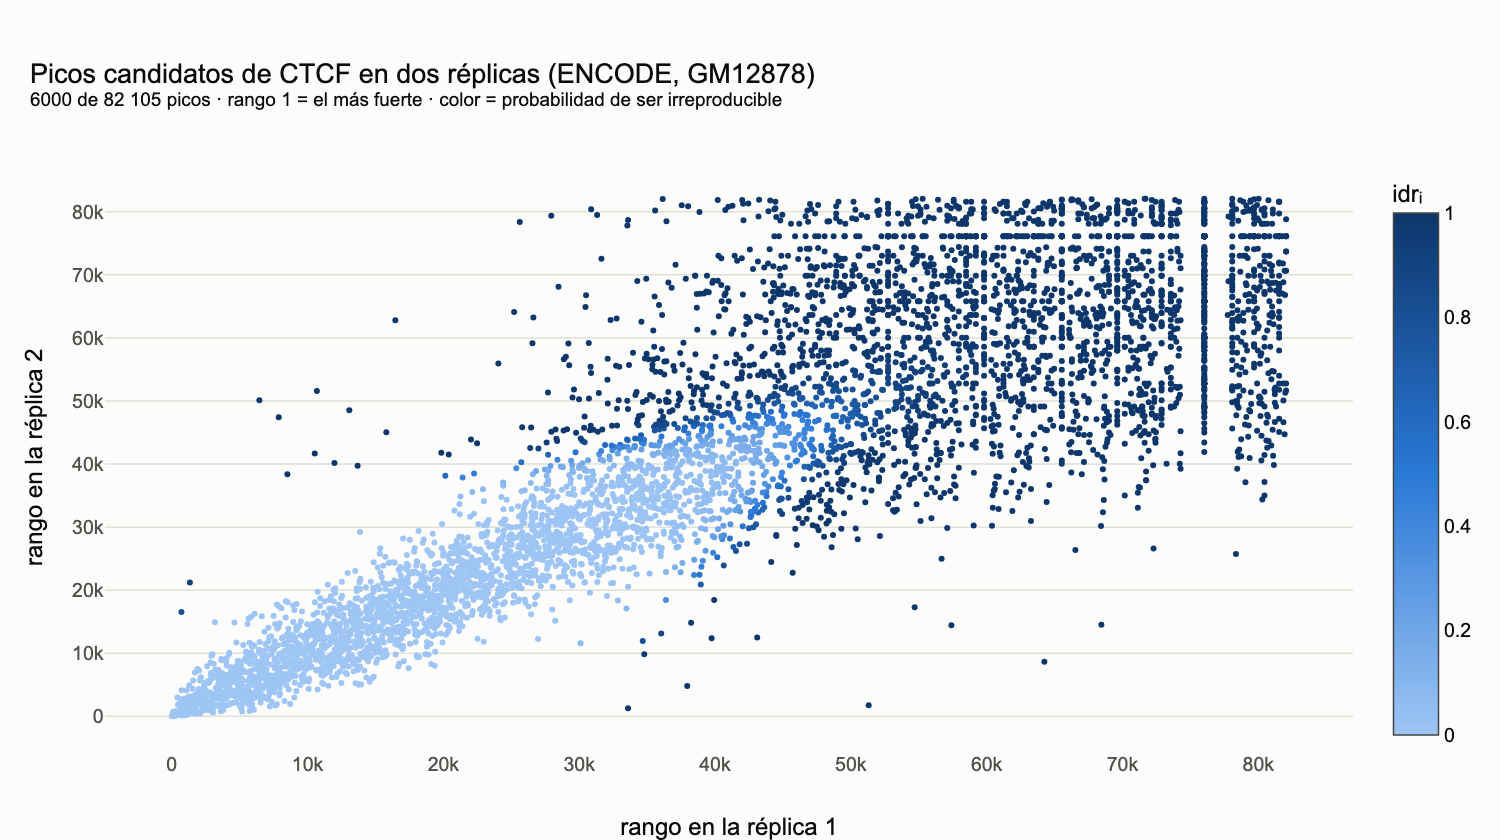

In [31]:
sub2 = np.random.default_rng(2).choice(n_r, 6000, replace=False)
pa = peaks_all.iloc[sub2]
fig = go.Figure(go.Scatter(
    x=rr1[sub2], y=rr2[sub2], mode="markers",
    marker=dict(size=4, color=idr_real[sub2], colorscale=[[0, ec.SEQ_BLUE[2]], [0.5, ec.SEQ_BLUE[7]], [1, ec.SEQ_BLUE[-1]]],
                cmin=0, cmax=1, colorbar=dict(title="idrᵢ")),
    customdata=np.column_stack([pa.chrom + ":" + pa.start.astype(str), pa.rep1_signal, pa.rep2_signal,
                                idr_real[sub2], IDR_real[sub2], IDR_enc[sub2]]),
    hovertemplate="<b>%{customdata[0]}</b><br>rango rep1 = %{x:,.0f} · rango rep2 = %{y:,.0f}"
                  "<br>señal rep1 = %{customdata[1]:.1f} · rep2 = %{customdata[2]:.1f}"
                  "<br>idrᵢ (nuestro EM) = %{customdata[3]:.3f}<br>IDR de la lista hasta aquí = %{customdata[4]:.3f}"
                  "<br>IDR ENCODE = %{customdata[5]:.3g}<extra></extra>"))
fig.update_layout(
    title="Picos candidatos de CTCF en dos réplicas (ENCODE, GM12878)"
          "<br><sup>6000 de 82 105 picos · rango 1 = el más fuerte · color = probabilidad de ser irreproducible</sup>",
    xaxis_title="rango en la réplica 1", yaxis_title="rango en la réplica 2", height=560,
    margin=dict(t=110, l=70, r=30, b=60))
fig.show()

> ✅ **Compruebe su comprensión.** ¿Por qué el modelo de IDR trabaja con **rangos** en lugar de con las señales o los
> valores $p$ de cada réplica? ¿Qué pasaría si una réplica se hubiera secuenciado al doble de profundidad?
> <details><summary>Respuesta</summary>Porque las escalas no son comparables entre réplicas ni entre llamadores de
> picos: con el doble de profundidad todas las señales y los −log10 p de esa réplica serían mayores. Los rangos son
> invariantes a cualquier transformación monótona de la puntuación; lo único que importa es si el orden de los picos
> se conserva entre réplicas.</details>

### Errores frecuentes en ChIP-seq

1. **Sin control o con un control poco profundo.** El control debe tener al menos tanta profundidad como el
   tratamiento; si no, $\lambda_{\text{local}}$ se estima con mucho ruido. (En nuestros datos reales $N_T/N_C\approx1{,}78$:
   cada lectura del *input* "cuenta" 1,78 veces.)
2. **Duplicados de PCR.** Muchas lecturas idénticas apiladas en la misma posición inflan los conteos y **violan la
   independencia** del modelo de Poisson; se marcan y se eliminan (o se limita su número) antes de llamar picos. Los
   BAM "filtrados" de ENCODE que usamos ya vienen sin duplicados.

## 7. ATAC-seq: medir la accesibilidad

ChIP-seq necesita un anticuerpo por proteína y millones de células. Una pregunta más general (¿qué regiones del
genoma están **abiertas**, libres de nucleosomas y disponibles para cualquier factor?) se responde con una idea
ingeniosa. La transposasa **Tn5**, en una versión hiperactiva cargada con adaptadores de secuenciación, corta el ADN e
inserta los adaptadores en el mismo acto (**tagmentación**). En la cromatina nativa, Tn5 sólo alcanza los segmentos no
protegidos: las **regiones libres de nucleosomas** y los **conectores** entre nucleosomas; es como pasar una
podadora por un jardín con piedras: sólo corta la hierba entre ellas. Buenrostro et al. (2013) llamaron a la técnica
**ATAC-seq** (*assay for transposase-accessible chromatin using sequencing*) y mostraron que con 500 a 50 000 células
revela a la vez la cromatina abierta, la unión de factores y la posición de nucleosomas; el protocolo detallado está
en Buenrostro et al. (2015). Como Tn5 corta como **dímero** con un escalonamiento de 9 pb, los análisis de alta
resolución desplazan las lecturas **$+4/-5$ pb** para situar el centro exacto de cada inserción.

Dos inserciones de Tn5 definen un fragmento secuenciable, y **su longitud es un registro directo de lo que había entre
ellas**: nada (fragmentos cortos, < 100 pb, de la región libre de nucleosomas, NFR), un nucleosoma (unos 200 pb), dos
(unos 400 pb)... La distribución de tamaños de un buen experimento es por tanto una **mezcla**:

$$
h(\ell) \;=\; \pi_0\,h_0(\ell) \;+\; \sum_{j=1}^{J}\pi_j\,\mathcal N\!\left(\ell;\ j\,\ell_{\text{nuc}},\ \sigma_j^2\right),
\qquad \sum_{j=0}^{J}\pi_j = 1 ,
\tag{13.8}
$$

| Símbolo | Significado |
|---|---|
| $h(\ell)$ | densidad de la longitud $\ell$ de los fragmentos |
| $h_0$ | componente libre de nucleosomas (fragmentos cortos, moda por debajo de 100 pb) |
| $\ell_{\text{nuc}}$ | repetición nucleosomal efectiva (unos 180–200 pb: 147 del núcleo más el conector) |
| $\pi_j,\ \sigma_j$ | proporción y dispersión de los fragmentos que abarcan $j$ nucleosomas |

A esta forma gruesa se superpone una **oscilación fina de unos 10,5 pb**, el paso de la doble hélice: Tn5 corta
preferentemente el lado expuesto de la hélice, de modo que las distancias entre cortes favorecen múltiplos de una
vuelta.

Reproducimos la simulación del libro (semilla 105): 2 millones de fragmentos de una mezcla con $\pi=(0{,}52;\,0{,}30;\,
0{,}13;\,0{,}05)$, jorobas en 195, 385 y 575 pb, y una aceptación modulada por $1+0{,}18\cos\bigl(2\pi(\ell-5)/10{,}5\bigr)$.

In [32]:
# === Simulación del libro (bloque 13.1-e, semilla 105) ===
rng = np.random.default_rng(105)
n = 2_000_000
comp = rng.choice(4, n, p=[0.52, 0.30, 0.13, 0.05])
lens = np.empty(n)
m0 = comp == 0
lens[m0] = rng.gamma(4.0, 16.0, m0.sum()) + 20
for c, mu_, sd in [(1, 195, 28), (2, 385, 38), (3, 575, 50)]:
    m = comp == c
    lens[m] = rng.normal(mu_, sd, m.sum())
acc = 1 + 0.18 * np.cos(2 * np.pi * (lens - 5) / 10.5)          # periodicidad helicoidal (10,5 pb)
keep = rng.random(n) < acc / 1.18
lens = lens[keep & (lens > 20) & (lens < 1000)].round().astype(int)
h_sim = np.bincount(lens, minlength=1001)[:1000] / lens.size
print(f"fragmentos: {lens.size:,};  < 100 pb: {(lens < 100).mean():.3f};  180–247 pb: {((lens >= 180) & (lens <= 247)).mean():.3f}")
print("Libro: 1 694 646 fragmentos; 0,380; 0,210")
# perfil TSS simulado del libro
xs_t = np.arange(-2000, 2001, 10)
perfil = 1 + 7.5 * np.exp(-0.5 * (xs_t / 90) ** 2)
perfil += 1.2 * np.exp(-0.5 * ((xs_t - 250) / 45) ** 2) * 0
perfil = perfil - 0.8 * np.exp(-0.5 * ((xs_t - 180) / 50) ** 2) + 0.6 * np.exp(-0.5 * ((xs_t - 330) / 55) ** 2)
perfil *= 1 + rng.normal(0, 0.04, xs_t.size)
perfil /= np.r_[perfil[:10], perfil[-10:]].mean()
print(f"Enriquecimiento en TSS simulado (máximo del perfil normalizado): {perfil.max():.2f}   (libro: 8,35)")

fragmentos: 1,694,646;  < 100 pb: 0.380;  180–247 pb: 0.210
Libro: 1 694 646 fragmentos; 0,380; 0,210
Enriquecimiento en TSS simulado (máximo del perfil normalizado): 8.35   (libro: 8,35)


Ahora los **datos reales**: 460 308 fragmentos de ATAC-seq de GM12878 (ENCODE `ENCFF415FEC`, pares de lecturas de
101 pb) en chr1:0–30 Mb. Cada fragmento se guardó como (inicio, longitud).

> 🤔 **Antes de ejecutar, prediga…** ¿Esperaría en los datos reales más o menos fragmentos cortos (< 100 pb) que el
> 38 % de la simulación? Piense que en la línea celular real hay mucha cromatina cerrada y que las lecturas de un
> ATAC-seq de ENCODE ya pasaron filtros de calidad y de duplicados.

In [33]:
atac = np.load(io.BytesIO(course_bytes("131_atac_gm12878_chr1_0-30Mb_fragments.npz")))
f_start = undelta(atac["start_delta"]); f_len = atac["length"].astype(np.int64)
print(str(atac["info"]))
h_real = np.bincount(f_len, minlength=1001)[:1000] / f_len.size
nfr_r, mono_r = (f_len < 100).mean(), ((f_len >= 180) & (f_len <= 247)).mean()
print(f"fragmentos: {f_len.size:,};  mediana {np.median(f_len):.0f} pb;  < 100 pb: {nfr_r:.3f};  180–247 pb: {mono_r:.3f}")
print("Conteos entre 96 y 103 pb:", dict(zip(range(96, 104), np.bincount(f_len, minlength=1001)[96:104])))

# Ajuste de la mezcla 13.8 (J = 4) por mínimos cuadrados ponderados; h0 = gamma desplazada 20 pb
lg_ = np.arange(1000)
fit_m = (lg_ >= 30) & (lg_ <= 900) & ~np.isin(lg_, [99, 100])      # excluimos el hueco artefactual
def mixture(l, p0, k, th, p1, p2, p3, p4, lnuc, s1, s2, s3, s4):
    out = p0 * stats.gamma.pdf(l - 20, k, scale=th)
    for j, (pj, sj) in enumerate([(p1, s1), (p2, s2), (p3, s3), (p4, s4)], start=1):
        out = out + pj * stats.norm.pdf(l, j * lnuc, sj)
    return out
p_init = [0.4, 3, 15, 0.3, 0.2, 0.1, 0.05, 190, 30, 40, 50, 60]
bounds = ([0, 1, 1, 0, 0, 0, 0, 150, 5, 5, 5, 5], [1, 20, 80, 1, 1, 1, 1, 250, 90, 110, 130, 150])
popt, _ = optimize.curve_fit(mixture, lg_[fit_m], h_real[fit_m], p0=p_init, bounds=bounds,
                             sigma=np.sqrt(h_real[fit_m]) + 1e-5, maxfev=20000)
pis = np.array([popt[0], *popt[3:7]]); pis_n = pis / pis.sum()
l_nuc = popt[7]
print(f"ℓ_nuc estimado = {l_nuc:.1f} pb;  π (normalizadas) = " + ", ".join(f"π{j} = {p:.2f}" for j, p in enumerate(pis_n)))

ENCODE ENCSR095QNB (ATAC-seq, GM12878, Snyder/Stanford) rep1 ENCFF415FEC; GRCh38 chr1:0-30,000,000; fragment = leftmost mate start (0-based) + TLEN; proper pairs, MAPQ>=30
fragmentos: 460,308;  mediana 202 pb;  < 100 pb: 0.284;  180–247 pb: 0.147
Conteos entre 96 y 103 pb: {96: np.int64(1367), 97: np.int64(1425), 98: np.int64(1398), 99: np.int64(8), 100: np.int64(9), 101: np.int64(1162), 102: np.int64(1141), 103: np.int64(1235)}
ℓ_nuc estimado = 188.6 pb;  π (normalizadas) = π0 = 0.27, π1 = 0.38, π2 = 0.20, π3 = 0.08, π4 = 0.07


Periodo dominante de la oscilación fina — real: 10.1 pb;  simulación del libro: 10.5 pb


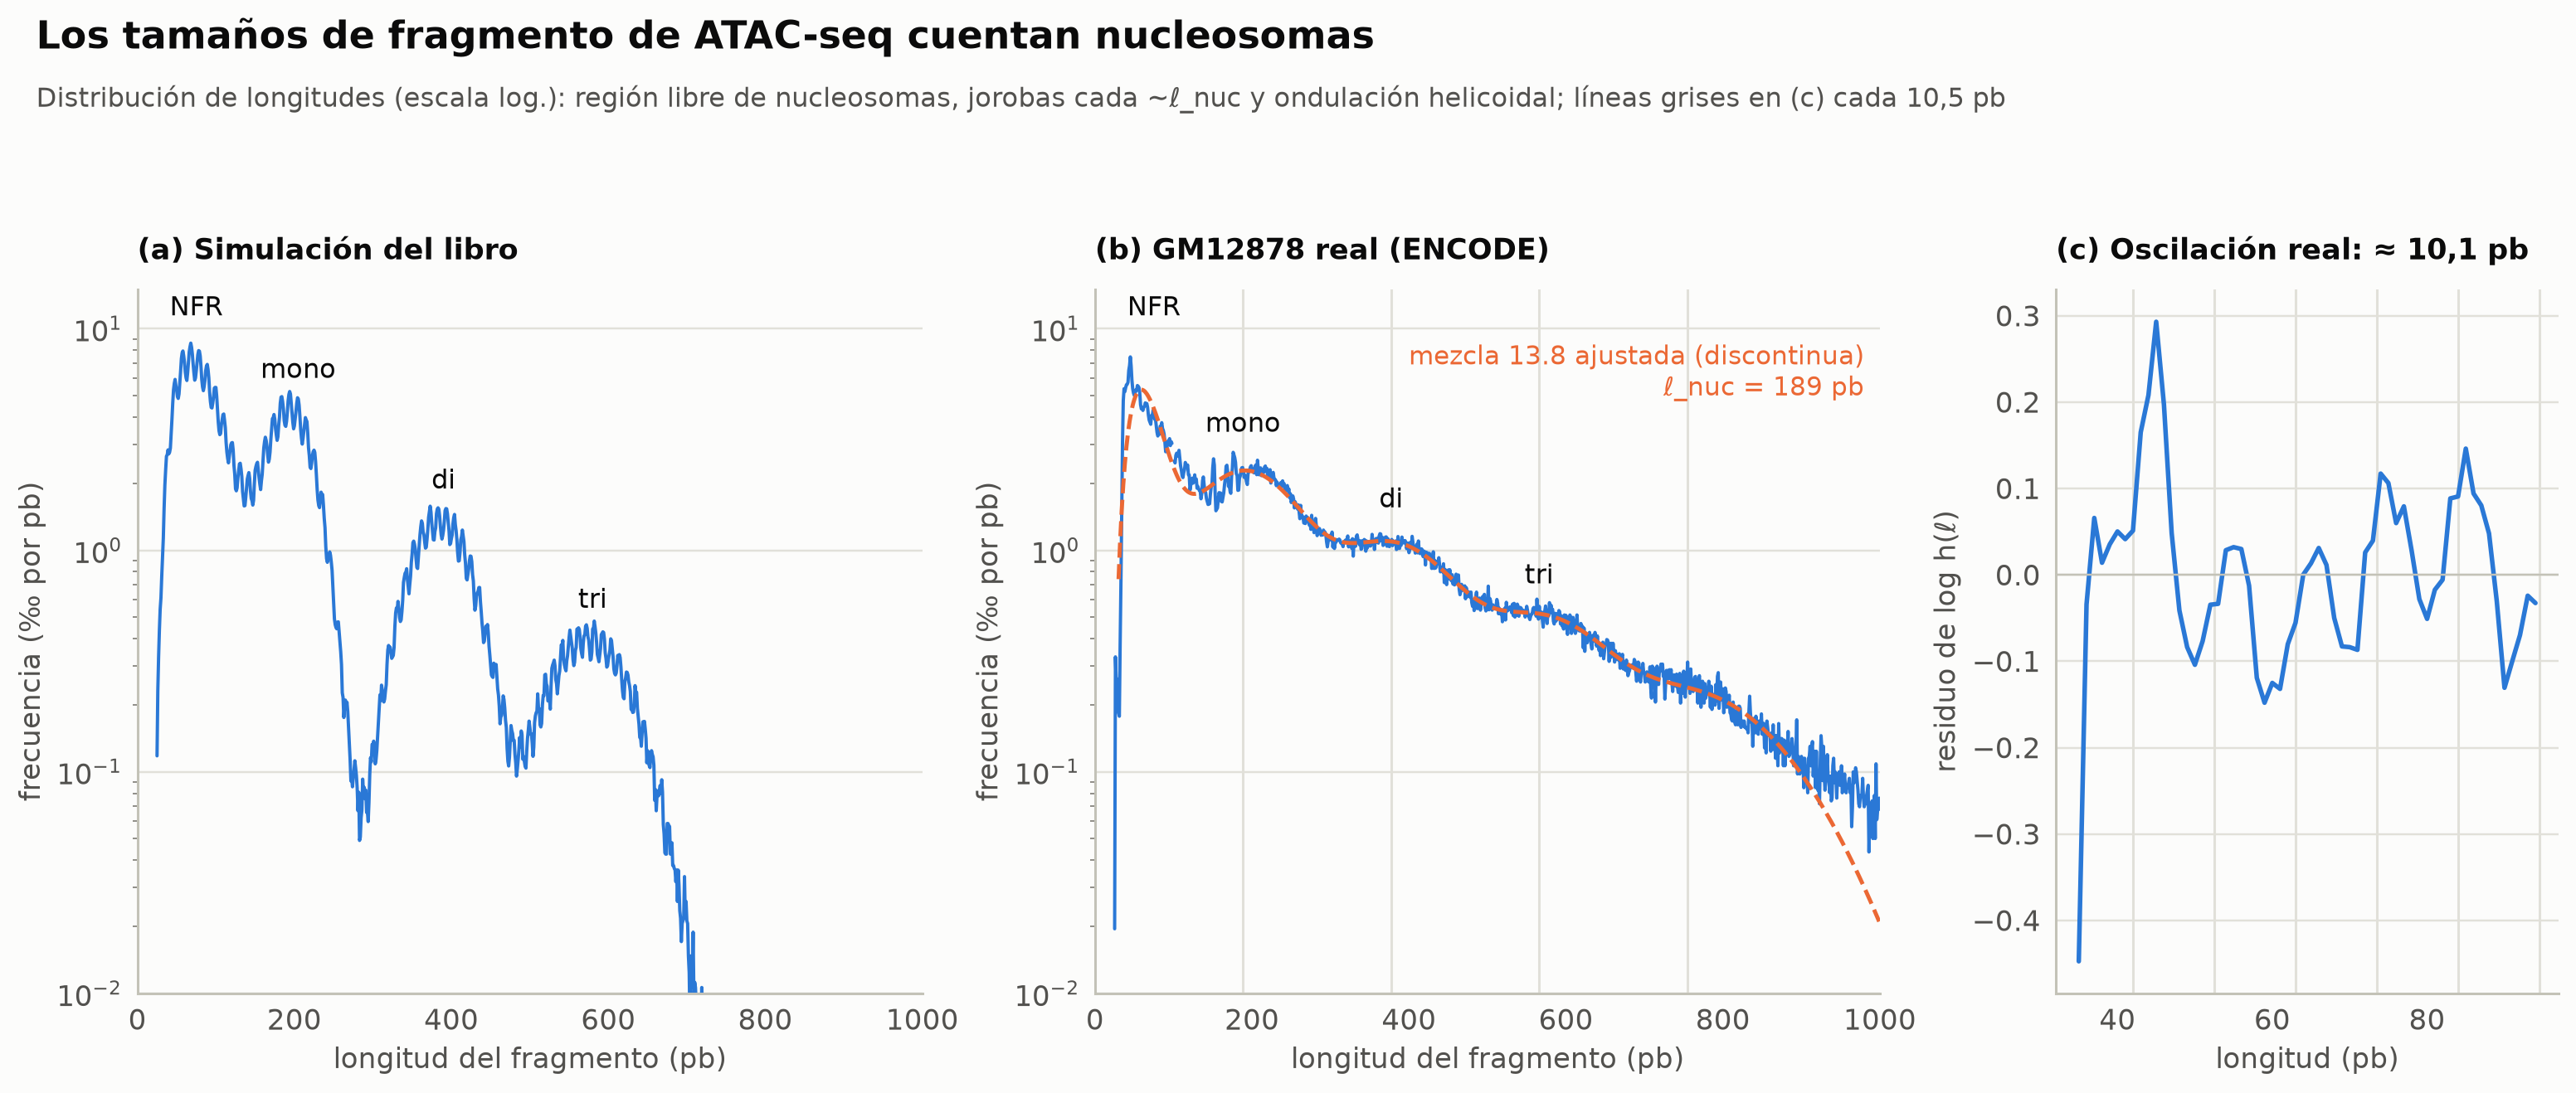

In [34]:
# Oscilación fina: periodograma del residuo del logaritmo del histograma entre 35 y 95 pb
xl = np.arange(35, 95)
lh = np.log(h_real[xl]); resid = lh - np.polyval(np.polyfit(xl, lh, 3), xl)
F = np.abs(np.fft.rfft(resid * np.hanning(xl.size), n=8192)); fr = np.fft.rfftfreq(8192)
ok = (fr > 1 / 30) & (fr < 1 / 5)
period_real = 1 / fr[ok][np.argmax(F[ok])]
lhs = np.log(h_sim[xl]); resid_s = lhs - np.polyval(np.polyfit(xl, lhs, 3), xl)
Fs = np.abs(np.fft.rfft(resid_s * np.hanning(xl.size), n=8192))
period_sim = 1 / fr[ok][np.argmax(Fs[ok])]
print(f"Periodo dominante de la oscilación fina — real: {period_real:.1f} pb;  simulación del libro: {period_sim:.1f} pb")

fig = plt.figure(figsize=(14, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.25, 0.8])
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
ax = fig.add_subplot(gs[0])
ax.plot(np.arange(25, 1000), np.maximum(h_sim[25:], 1e-7) * 1000, color=ec.BLUE, lw=1.3)
for x_, y_, t_ in [(75, 11.5, "NFR"), (205, 6, "mono"), (390, 1.9, "di"), (580, 0.55, "tri")]:
    ax.text(x_, y_, t_, ha="center", fontsize=10.5)
ax.set_yscale("log"); ax.set_ylim(0.01, 15); ax.set_xlim(0, 1000)
ax.set_xlabel("longitud del fragmento (pb)"); ax.set_ylabel("frecuencia (‰ por pb)")
ax.set_title("(a) Simulación del libro", loc="left", fontsize=11.5)
ax = fig.add_subplot(gs[1])
hr = h_real.copy(); hr[[99, 100]] = np.nan
ax.plot(np.arange(25, 1000), hr[25:] * 1000, color=ec.BLUE, lw=1.3)
ax.plot(np.arange(30, 1000), mixture(np.arange(30, 1000), *popt) * 1000, color=ec.ORANGE, lw=1.6, ls="--")
for j in range(1, 5):
    ax.axvline(j * l_nuc, color=ec.GRID, lw=1, zorder=0)
ax.text(75, 11.5, "NFR", ha="center", fontsize=10.5)
for j, t_ in [(1, "mono"), (2, "di"), (3, "tri")]:
    ax.text(j * l_nuc, h_real[int(j * l_nuc)] * 1000 * 1.45, t_, ha="center", fontsize=10.5)
ax.text(980, 5, f"mezcla 13.8 ajustada (discontinua)\nℓ_nuc = {l_nuc:.0f} pb", color=ec.ORANGE, ha="right", fontsize=10)
ax.set_yscale("log"); ax.set_ylim(0.01, 15); ax.set_xlim(0, 1000)
ax.set_xlabel("longitud del fragmento (pb)"); ax.set_ylabel("frecuencia (‰ por pb)")
ax.set_title("(b) GM12878 real (ENCODE)", loc="left", fontsize=11.5)
ax = fig.add_subplot(gs[2])
ax.plot(xl, resid, color=ec.BLUE, lw=1.8)
for k_ in range(4, 10):
    ax.axvline(k_ * 10.5, color=ec.GRID, lw=1, zorder=0)
ax.axhline(0, color=ec.BASELINE, lw=0.8)
ax.set_xlabel("longitud (pb)"); ax.set_ylabel("residuo de log h(ℓ)")
ax.set_title(f"(c) Oscilación real: ≈ {period_real:.1f} pb".replace(".", ","), loc="left", fontsize=11.5)
ec.fig_title(fig, "Los tamaños de fragmento de ATAC-seq cuentan nucleosomas",
             "Distribución de longitudes (escala log.): región libre de nucleosomas, jorobas cada ~ℓ_nuc y ondulación helicoidal; líneas grises en (c) cada 10,5 pb")
plt.show()

> 🔎 **Qué observamos.** (a) La simulación del libro: el 38 % de los fragmentos mide menos de 100 pb y el 21 % cae en
> el intervalo mononucleosomal (180–247 pb). (b) Los datos reales de GM12878 tienen **la misma arquitectura**: una
> población corta dominante, jorobas mono-, di- y trinucleosomales, y el ajuste de la mezcla (13.8) estima una
> repetición nucleosomal $\ell_{\text{nuc}}$ de unos 188 pb, dentro del intervalo 180–200 pb de la sección 1. La
> fracción corta es menor que en la simulación (un 28 %) y las jorobas son más anchas: en una célula real conviven
> nucleosomas con conectores de longitudes distintas. Hay además un **hueco** de dos bins en 99–100 pb (lo marcamos como
> faltante): coincide con la longitud de lectura (101 pb) y es un artefacto técnico del procesamiento de pares que se
> solapan por completo, no biología. (c) Tras quitar la tendencia, la ondulación fina de los fragmentos cortos tiene un
> periodo de unos 10 pb, cercano a los 10,5 pb de una vuelta de hélice. Una biblioteca **sin jorobas** sugiere
> digestión excesiva o ADN desnudo.

### Enriquecimiento en TSS

Los **promotores activos** son las regiones abiertas más universales, así que un experimento que "ve" cromatina abierta
debe mostrar un pico agudo en los sitios de inicio de la transcripción (TSS).

**Definición.** Sea $I(x)$ el número de inserciones de Tn5 acumuladas en la posición $x$ relativa a todos los TSS del
genoma, orientados según la hebra del gen. El perfil normalizado es

$$
E(x) = \frac{I(x)}{\tfrac{1}{2m}\left(\sum_{u=-2000}^{-2000+m-1} I(u) + \sum_{u=2000-m+1}^{2000} I(u)\right)},
\tag{13.9}
$$

es decir, el conteo dividido por el promedio en los **extremos** de la ventana ($m$ posiciones a cada lado,
típicamente 100 pb). La **puntuación de enriquecimiento en TSS** es $\max_x E(x)$ cerca de $x=0$.

| Símbolo | Significado |
|---|---|
| $I(x)$ | inserciones acumuladas a distancia $x$ del TSS (pb, con signo según la orientación del gen) |
| $m$ | ancho de los bordes usados como fondo |
| $E(x)$ | enriquecimiento relativo al fondo lejano; vale $\approx1$ lejos del TSS |

Un enriquecimiento bajo (digamos, **inferior a 5**) indica demasiadas lecturas de fondo, típicamente por células
muertas o lisis excesiva de los núcleos. Para los datos reales usamos los **410 TSS** de RefSeq Select (un transcrito
por gen) en chr1:0–30 Mb, obtenidos de la API del navegador de UCSC, y las inserciones desplazadas $+4/-5$.

In [35]:
genes = json.loads(course_bytes("api_cache/ucsc_hg38_ncbiRefSeqSelect_chr1_0-30000000.json"))["items"]
tss = pd.DataFrame([dict(gene=g["name2"], strand=g["strand"],
                         tss=g["txStart"] if g["strand"] == "+" else g["txEnd"] - 1) for g in genes])
print(f"{len(tss)} TSS; ejemplos:", ", ".join(tss.gene.head(8)))
ins = np.sort(np.r_[f_start + 4, f_start + f_len - 5])          # centro de cada inserción de Tn5 (+4 / −5)

def tss_profile(positions, tss_df, half=2000):
    """I(x): inserciones a distancia x de cada TSS, orientadas según la hebra del gen."""
    prof = np.zeros(2 * half + 1)
    for t, s in zip(tss_df.tss.values, tss_df.strand.values):
        lo, hi = np.searchsorted(positions, [t - half, t + half + 1])
        rel = positions[lo:hi] - t
        prof += np.bincount((rel if s == "+" else -rel) + half, minlength=2 * half + 1)
    return prof

I_x = tss_profile(ins, tss)
m_edge = 100
E_x = I_x / ((I_x[:m_edge].sum() + I_x[-m_edge:].sum()) / (2 * m_edge))       # ecuación 13.9
x_t = np.arange(-2000, 2001)
E_s = np.convolve(E_x, np.ones(51) / 51, "same")                                # suavizado de 51 pb (sólo para ver)
print(f"Puntuación de enriquecimiento en TSS (ecuación 13.9, sin suavizar): {E_x.max():.1f} en x = {x_t[np.argmax(E_x)]}")
print(f"Tras suavizar 51 pb: máximo {E_s[100:-100].max():.1f} en x = {x_t[100:-100][np.argmax(E_s[100:-100])]} pb")

410 TSS; ejemplos: OR4F5, OR4F29, OR4F16, SAMD11, NOC2L, KLHL17, PLEKHN1, PERM1
Puntuación de enriquecimiento en TSS (ecuación 13.9, sin suavizar): 46.0 en x = 5
Tras suavizar 51 pb: máximo 27.0 en x = -117 pb


Un paso más, de nivel de investigación: separar los fragmentos por **tamaño**. Los cortos (< 100 pb) deberían venir
de la región libre de nucleosomas **encima** del TSS; los mononucleosomales (180–247 pb) deberían tener su **centro**
sobre los nucleosomas que flanquean el promotor, en particular el **nucleosoma +1**, justo río abajo del TSS. El
llamado *V-plot* (Henikoff et al., 2011) dibuja cada fragmento por su punto medio (eje horizontal) y su longitud (eje
vertical).

In [36]:
mid = f_start + f_len // 2
o_ = np.argsort(mid); mid_s, len_s = mid[o_], f_len[o_]
rel_list, len_list = [], []
for t, s in zip(tss.tss.values, tss.strand.values):
    lo, hi = np.searchsorted(mid_s, [t - 1000, t + 1001])
    rel = mid_s[lo:hi] - t
    rel_list.append(rel if s == "+" else -rel); len_list.append(len_s[lo:hi])
rel_all, len_all = np.concatenate(rel_list), np.concatenate(len_list)
short = len_all < 100; mono = (len_all >= 180) & (len_all <= 247)
bins_c = np.arange(-1000, 1001, 20)
def dens_norm(v):
    h_ = np.histogram(v, bins_c)[0].astype(float)
    return h_ / np.r_[h_[:5], h_[-5:]].mean()
prof_short, prof_mono = dens_norm(rel_all[short]), dens_norm(rel_all[mono])
bc = (bins_c[:-1] + bins_c[1:]) / 2
print(f"Fragmentos con punto medio a ±1 kb de un TSS: {rel_all.size:,}")
print(f"Máximo de los mononucleosomales río abajo: x = {bc[bc > 0][np.argmax(prof_mono[bc > 0])]:.0f} pb")

Fragmentos con punto medio a ±1 kb de un TSS: 166,446
Máximo de los mononucleosomales río abajo: x = 110 pb


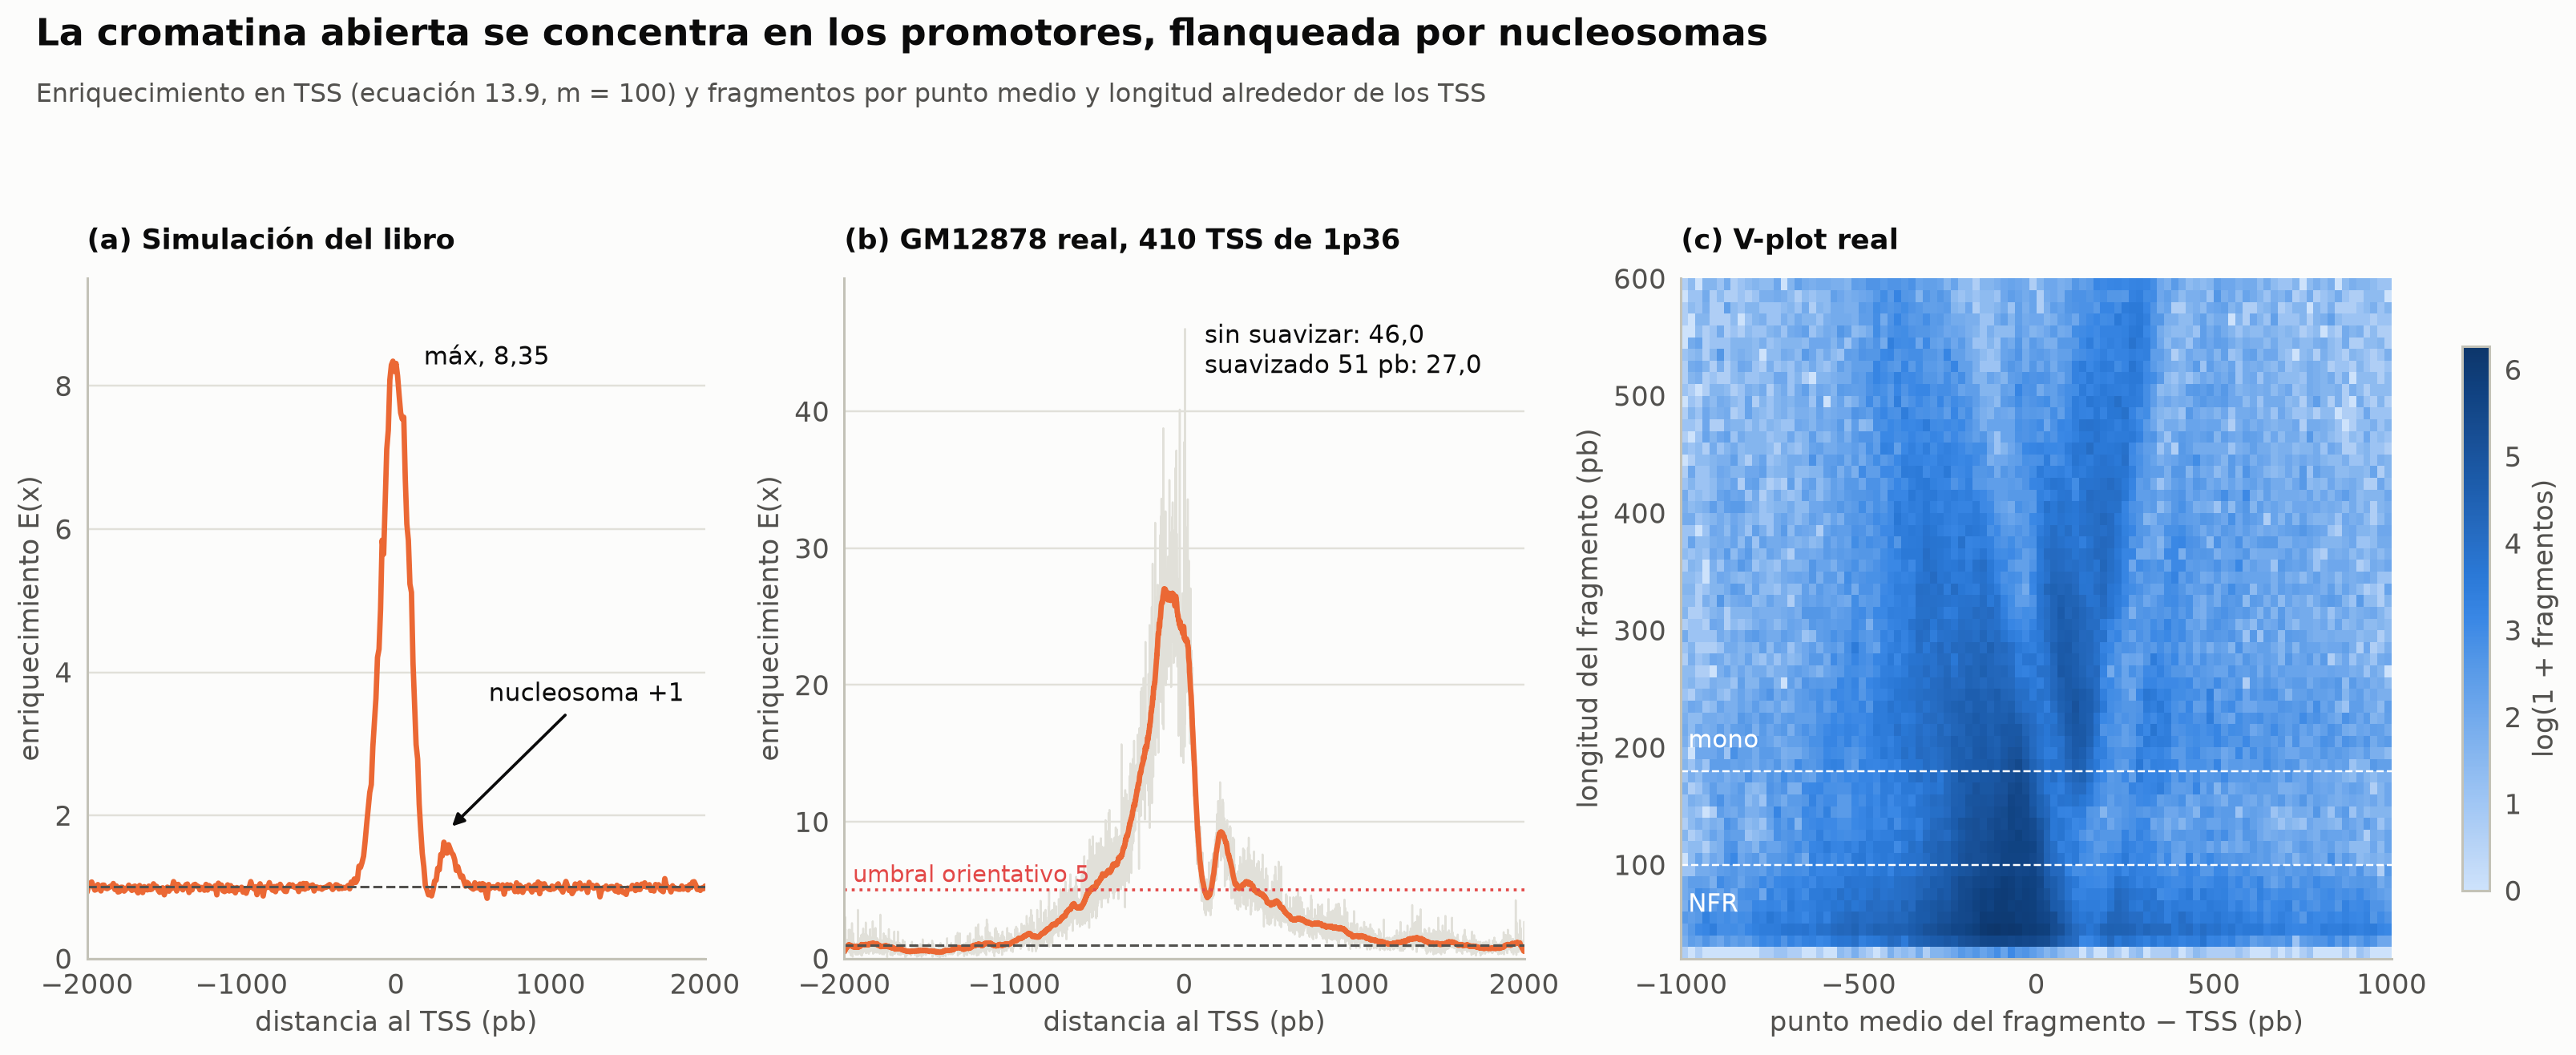

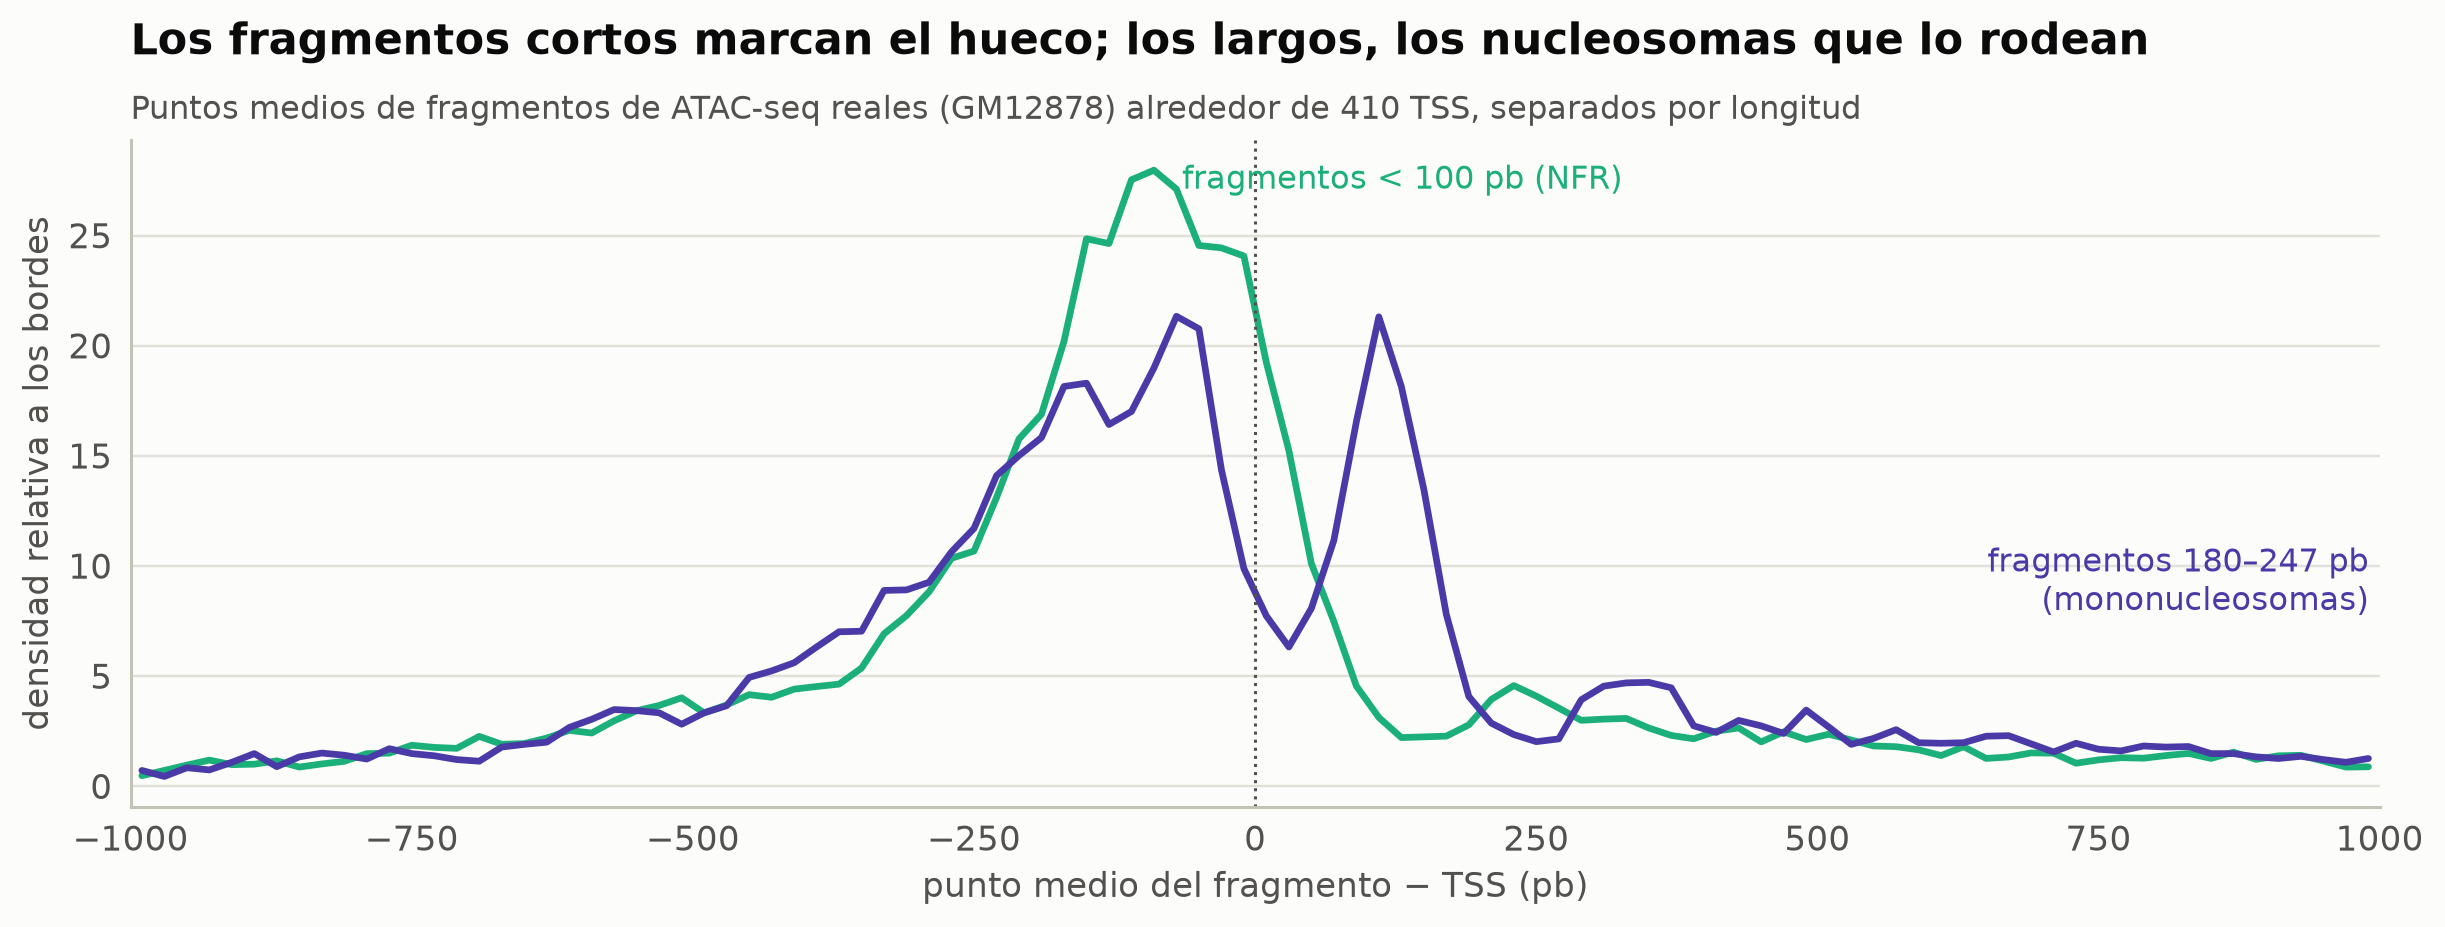

In [37]:
fig = plt.figure(figsize=(14.5, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.1, 1.15])
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
ax = fig.add_subplot(gs[0])
ax.plot(xs_t, perfil, color=ec.ORANGE, lw=2.2)
ax.axhline(1, color=ec.INK_2, ls="--", lw=1)
ax.text(180, 8.3, f"máx. {perfil.max():.2f}".replace(".", ","), fontsize=10)
ax.annotate("nucleosoma +1", xy=(340, 1.8), xytext=(600, 3.6), textcoords="data", fontsize=10,
            arrowprops=dict(arrowstyle="-|>", color=ec.INK, lw=1.2, shrinkA=2, shrinkB=2))
ax.set_xlim(-2000, 2000); ax.set_ylim(0, 9.5)
ax.set_xlabel("distancia al TSS (pb)"); ax.set_ylabel("enriquecimiento E(x)")
ax.set_title("(a) Simulación del libro", loc="left", fontsize=11.5)
ax = fig.add_subplot(gs[1])
ax.plot(x_t, E_x, color=ec.GRID, lw=0.8)
ax.plot(x_t, E_s, color=ec.ORANGE, lw=2.2)
ax.axhline(1, color=ec.INK_2, ls="--", lw=1)
ax.axhline(5, color=ec.RED, ls=":", lw=1.2); ax.text(-1950, 5.6, "umbral orientativo 5", color=ec.RED, fontsize=9.5)
ax.text(120, E_x.max() * 0.93, f"sin suavizar: {E_x.max():.1f}\nsuavizado 51 pb: {E_s[100:-100].max():.1f}".replace(".", ","), fontsize=10)
ax.set_xlim(-2000, 2000); ax.set_ylim(0, E_x.max() * 1.08); ax.set_xticks([-2000, -1000, 0, 1000, 2000])
ax.set_xlabel("distancia al TSS (pb)"); ax.set_ylabel("enriquecimiento E(x)")
ax.set_title("(b) GM12878 real, 410 TSS de 1p36", loc="left", fontsize=11.5)
ax = fig.add_subplot(gs[2])
hv, xe, ye = np.histogram2d(rel_all, len_all, bins=[np.arange(-1000, 1001, 20), np.arange(20, 601, 10)])
im = ax.imshow(np.log1p(hv.T), origin="lower", aspect="auto", extent=[-1000, 1000, 20, 600], cmap="curso_seq")
ax.grid(False); ax.axhline(100, color="white", lw=0.8, ls="--"); ax.axhline(180, color="white", lw=0.8, ls="--")
ax.text(-980, 60, "NFR", color="white", fontsize=10); ax.text(-980, 200, "mono", color="white", fontsize=10)
ax.set_xlabel("punto medio del fragmento − TSS (pb)"); ax.set_ylabel("longitud del fragmento (pb)")
ax.set_xticks([-1000, -500, 0, 500, 1000])
fig.colorbar(im, ax=ax, shrink=0.8, label="log(1 + fragmentos)")
ax.set_title("(c) V-plot real", loc="left", fontsize=11.5)
ec.fig_title(fig, "La cromatina abierta se concentra en los promotores, flanqueada por nucleosomas",
             "Enriquecimiento en TSS (ecuación 13.9, m = 100) y fragmentos por punto medio y longitud alrededor de los TSS")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.1))
ax.plot(bc, prof_short, color=ec.AQUA, lw=2.2); ax.plot(bc, prof_mono, color=ec.VIOLET, lw=2.2)
ax.axvline(0, color=ec.INK_2, ls=":", lw=1)
ax.text(bc[np.argmax(prof_short)] + 25, prof_short.max() * 0.97, "fragmentos < 100 pb (NFR)", color=ec.AQUA, fontsize=10.5)
ax.text(990, 8, "fragmentos 180–247 pb\n(mononucleosomas)", color=ec.VIOLET, fontsize=10.5, ha="right")
ax.set_xlim(-1000, 1000); ax.set_xlabel("punto medio del fragmento − TSS (pb)"); ax.set_ylabel("densidad relativa a los bordes")
ec.title(ax, "Los fragmentos cortos marcan el hueco; los largos, los nucleosomas que lo rodean",
         "Puntos medios de fragmentos de ATAC-seq reales (GM12878) alrededor de 410 TSS, separados por longitud")
plt.show()

> 🔎 **Qué observamos.** (a) El perfil simulado del libro alcanza 8,35 con un hombro río abajo, el nucleosoma $+1$.
> (b) Los datos reales superan con amplitud el umbral de 5: la puntuación sin suavizar, $\max_x E(x)$, es muy alta
> porque con sólo 410 TSS cada posición individual tiene ruido de conteo (el máximo de una curva ruidosa se infla);
> por eso los programas de calidad suavizan el perfil o agregan miles de TSS de todo el genoma antes de tomar el
> máximo. El máximo del perfil suavizado queda unos 120 pb **río arriba** del TSS anotado: la región libre de nucleosomas de un promotor
> activo se extiende unos 100–200 pb aguas arriba, donde se sientan los factores de transcripción. (c y figura
> inferior) El *V-plot* y los perfiles por tamaño separan las dos poblaciones: los fragmentos cortos se concentran
> sobre el promotor y los mononucleosomales dibujan **dos máximos** a ambos lados del hueco, con el nucleosoma $+1$
> centrado unos 110 pb río abajo del TSS:
> la arquitectura de un promotor activo, leída sólo a partir de longitudes de fragmento.

> ✅ **Compruebe su comprensión.** Un laboratorio obtiene un ATAC-seq con enriquecimiento en TSS de 2,5 y una
> distribución de tamaños sin jorobas. ¿Qué dos explicaciones propondría y cómo las distinguiría?
> <details><summary>Respuesta</summary>(1) Demasiado fondo: células muertas o núcleos lisados liberan ADN desnudo que
> Tn5 corta en cualquier sitio (el enriquecimiento cae y las jorobas desaparecen); se comprueba con la viabilidad y
> la fracción de lecturas mitocondriales. (2) Tagmentación excesiva (demasiada Tn5 para el número de núcleos): los
> fragmentos se acortan y se pierde la escalera nucleosomal. Ajustar la proporción enzima/células lo corrige.</details>

## 8. CUT&RUN, e idea clave

Una alternativa moderna a ChIP-seq **invierte la lógica** del experimento. En lugar de fragmentar toda la cromatina y
luego pescar los trozos que interesan, **CUT&RUN** (*cleavage under targets and release using nuclease*) lleva una
nucleasa hasta la proteína de interés: un anticuerpo se une al factor en núcleos intactos y una nucleasa micrococal
acoplada a proteína A corta el ADN a su alrededor, liberando sólo los fragmentos unidos. Como no hay entrecruzamiento
ni fragmentación global, el fondo es mínimo: Skene y Henikoff (2017) obtuvieron perfiles precisos con
aproximadamente **una décima parte** de la profundidad de secuenciación de ChIP-seq. Todo lo que hemos aprendido
(geometría de fragmentos, fondo de Poisson, FRiP, IDR) se aplica igual; lo que cambia es que el fondo es mucho menor.

> 💡 **Idea clave.** Un pico es un exceso de lecturas sobre un fondo **local**. La geometría de hebras delata la señal
> verdadera, el control protege frente a sesgos del genoma y la **reproducibilidad entre réplicas**, no el valor $p$,
> decide qué picos se conservan.

### De dónde salieron los datos (celda opcional, sólo en Colab)

La celda siguiente reconstruye desde ENCODE los archivos compactos del curso. Descarga unos 600 MB (dos BAM de
ChIP-seq) y transmite los primeros 60 MB de un BAM de ATAC-seq de 2,5 GB (el BAM está ordenado por coordenada, así que
el principio del archivo corresponde al principio de chr1). Por omisión **no se ejecuta**; cambie `RECONSTRUIR` a
`True` si quiere repetirla.

In [38]:
RECONSTRUIR = False     # ⚠️ ~600 MB de descarga; sólo en Colab
ENC = "https://www.encodeproject.org/files/{0}/@@download/{0}.{1}"
if RECONSTRUIR and IN_COLAB:
    try:
        import pysam
    except ImportError:
        %pip install -q pysam
        import pysam
    import subprocess
    for acc in ["ENCFF355CYX", "ENCFF850RIE"]:                     # CTCF réplica 1 y su input
        subprocess.run(["wget", "-q", "-O", f"{acc}.bam", ENC.format(acc, "bam")], check=True)
        pysam.index(f"{acc}.bam")
    out = {}
    for tag, acc in [("chip", "ENCFF355CYX"), ("ctrl", "ENCFF850RIE")]:
        b = pysam.AlignmentFile(f"{acc}.bam")
        p_, m_ = [], []
        for r in b.fetch("chr1", 0, 30_000_000):
            if r.mapping_quality < 30 or r.is_secondary or r.is_supplementary:
                continue
            (m_ if r.is_reverse else p_).append(r.reference_end - 1 if r.is_reverse else r.reference_start)
        out[tag] = (np.sort(p_), np.sort(m_))
        print(tag, len(p_), len(m_))
    # ATAC: sólo los primeros 60 MB del BAM (principio de chr1), sin descargar los 2,5 GB
    subprocess.run(f"curl -sL {ENC.format('ENCFF415FEC', 'bam')} | head -c 60000000 > atac_head.bam", shell=True)
    b = pysam.AlignmentFile("atac_head.bam", ignore_truncation=True)
    frags = [(r.reference_start, r.template_length) for r in b.fetch(until_eof=True)
             if r.reference_name == "chr1" and r.reference_start < 30_000_000 and r.is_proper_pair
             and r.mapping_quality >= 30 and r.template_length > 0]
    print("fragmentos de ATAC:", len(frags))
else:
    print("Se usan las copias compactas del curso (RECONSTRUIR = False o fuera de Colab).")

Se usan las copias compactas del curso (RECONSTRUIR = False o fuera de Colab).


## 9. Ejercicios

**Ejercicio 1 (a mano, luego con código).** Un ChIP-seq de un factor de transcripción en un tumor tiene
$N_T=3\times10^7$ lecturas, un *input* de $N_C=1{,}5\times10^7$, $d=150$ y $G=2{,}7\times10^9$. En una ventana candidata
hay $k=12$ lecturas; el control tiene 6, 20 y 50 lecturas en las ventanas de 1, 5 y 10 kb. Calcule $\lambda_{\text{BG}}$,
$\lambda_{1k}$, $\lambda_{5k}$, $\lambda_{10k}$, $\lambda_{\text{local}}$ y el valor $p$. ¿Es un pico con $p<10^{-5}$? ¿Qué
escala fija el fondo y por qué preocupa que $N_C<N_T$?

**Ejercicio 2 (calidad).** Con la simulación del libro (`simula_lecturas`), mantenga 600 000 lecturas totales y varíe
las procedentes de sitios reales: 5 000, 14 000, 30 000 y 60 000. Calcule el RSC de cada muestra (use `xcor_sparse`)
y diga a partir de qué fracción de señal se supera el umbral de 0,8.

**Ejercicio 3 (sensibilidad del llamador).** Vuelva a llamar picos en los datos reales de CTCF con $d=100$, $d=\hat d$ y
$d=250$. ¿Cómo cambian el número de picos y el porcentaje confirmado por ENCODE? Explique el resultado con la
geometría de la sección 3.

**Ejercicio 4 (ATAC).** Recalcule la puntuación de enriquecimiento en TSS real con $m=50$, $100$ y $200$ y, en cada
caso, con y sin suavizado de 51 pb. Repita usando sólo las inserciones de fragmentos < 100 pb. ¿Qué elección es más
estable y por qué?

**Ejercicio 5 (IDR).** Con el modelo ajustado a los 82 105 picos reales, ¿cuántos picos se conservan con
$\gamma=0{,}01$, $0{,}05$ y $0{,}10$? ¿Qué fracción de los picos de chr1:0–30 Mb que conserva ENCODE con 0,05 tiene
nuestro $\mathrm{IDR}\le0{,}05$?

In [39]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
NT1, NC1, d1, G1 = 3e7, 1.5e7, 150, 2.7e9
w1 = 2 * d1
lbg = NT1 * w1 / G1
lam1 = {"λ_BG": lbg}
for c, wp, nm in [(6, 1000, "λ_1k"), (20, 5000, "λ_5k"), (50, 10000, "λ_10k")]:
    lam1[nm] = c * w1 / wp * NT1 / NC1
for k_, v in lam1.items():
    print(f"{k_:6s} = {v:.3f}")
ll = max(lam1.values()); p1 = stats.poisson.sf(12 - 1, ll)
print(f"λ_local = {ll:.3f} (lo fija {max(lam1, key=lam1.get)});  p = Pr(X ≥ 12) = {p1:.2e} → "
      f"{'pico' if p1 < 1e-5 else 'no significativo'} con p < 1e-5")
print("Con N_C < N_T cada lectura del control se multiplica por 2: λ_1k descansa en sólo 6 lecturas, así que su error "
      "relativo (≈ 1/√6 ≈ 41 %) se traslada a λ_local.")

λ_BG   = 3.333
λ_1k   = 3.600
λ_5k   = 2.400
λ_10k  = 3.000
λ_local = 3.600 (lo fija λ_1k);  p = Pr(X ≥ 12) = 3.70e-04 → no significativo con p < 1e-5
Con N_C < N_T cada lectura del control se multiplica por 2: λ_1k descansa en sólo 6 lecturas, así que su error relativo (≈ 1/√6 ≈ 41 %) se traslada a λ_local.


In [40]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
rng = np.random.default_rng(2024)
res2 = []
for ns in [5_000, 14_000, 30_000, 60_000]:
    pl, mi = simula_lecturas(ns, 600_000 - ns)
    s_, cc = xcor_sparse(np.sort(pl), np.sort(mi), G)
    dh, nsc, rsc = strand_quality(s_, cc)
    res2.append(dict(lecturas_de_sitios=ns, fraccion=ns / 600_000, d_hat=dh, NSC=round(nsc, 2), RSC=round(rsc, 2)))
display(pd.DataFrame(res2))
print("El RSC cruza 0,8 entre el 5 % (RSC ≈ 0,5) y el 10 % (RSC ≈ 1,6) de lecturas procedentes de sitios reales: "
      "por debajo, el fantasma domina y d̂ (≈ 100 pb) deja de tener sentido biológico.")

,lecturas_de_sitios,fraccion,d_hat,NSC,RSC
0,5000,0.008333,102,1.34,0.36
1,14000,0.023333,104,1.32,0.36
2,30000,0.050000,180,1.49,0.51
3,60000,0.100000,185,2.74,1.63


El RSC cruza 0,8 entre el 5 % (RSC ≈ 0,5) y el 10 % (RSC ≈ 1,6) de lecturas procedentes de sitios reales: por debajo, el fantasma domina y d̂ (≈ 100 pb) deja de tener sentido biológico.


In [41]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
res3 = []
for dd in [100, d_real, 250]:
    pk, _ = call_peaks(T_plus, T_minus, C_plus, C_minus, dd, G_REG)
    res3.append(dict(d=dd, picos=len(pk), en_ENCODE=f"{overlaps(pk, enc_mask).mean():.1%}",
                     ancho_mediano=int((pk.end - pk.start).median())))
display(pd.DataFrame(res3))
print("Con d pequeño las lecturas + y − de un sitio no llegan a juntarse y la ventana 2d es estrecha y ruidosa: "
      "más picos, algunos partidos o espurios (menor % confirmado). Con d grande la ventana suaviza más: menos picos, "
      "más anchos (peor resolución) y algo más fiables. El d̂ de la correlación cruzada equilibra resolución y sensibilidad.")

,d,picos,en_ENCODE,ancho_mediano
0,100,814,87.3%,528
1,164,793,89.3%,760
2,250,753,91.2%,1116


Con d pequeño las lecturas + y − de un sitio no llegan a juntarse y la ventana 2d es estrecha y ruidosa: más picos, algunos partidos o espurios (menor % confirmado). Con d grande la ventana suaviza más: menos picos, más anchos (peor resolución) y algo más fiables. El d̂ de la correlación cruzada equilibra resolución y sensibilidad.


In [42]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
ins_short = np.sort(np.r_[f_start[f_len < 100] + 4, f_start[f_len < 100] + f_len[f_len < 100] - 5])
I_short = tss_profile(ins_short, tss)
rows4 = []
for nm, I_ in [("todas", I_x), ("fragmentos < 100 pb", I_short)]:
    for mm_ in [50, 100, 200]:
        Ex = I_ / ((I_[:mm_].sum() + I_[-mm_:].sum()) / (2 * mm_))
        Es = np.convolve(Ex, np.ones(51) / 51, "same")
        rows4.append(dict(inserciones=nm, m=mm_, max_sin_suavizar=round(Ex.max(), 1), max_suavizado=round(Es[100:-100].max(), 1)))
display(pd.DataFrame(rows4))
print("m cambia la puntuación en torno a un 10 %; lo que más la cambia es suavizar o no (≈ 46 frente a ≈ 27), porque "
      "el máximo sin suavizar lo fija el ruido de un único bin. Con sólo fragmentos cortos el enriquecimiento sube. "
      "Moraleja: sólo se comparan puntuaciones calculadas con la misma receta.")

,inserciones,m,max_sin_suavizar,max_suavizado
0,todas,50,42.7,25.1
1,todas,100,46.0,27.0
2,todas,200,47.7,28.0
3,fragmentos < 100 pb,50,48.0,31.7
4,fragmentos < 100 pb,100,52.7,34.8
5,fragmentos < 100 pb,200,54.1,35.7


m cambia la puntuación en torno a un 10 %; lo que más la cambia es suavizar o no (≈ 46 frente a ≈ 27), porque el máximo sin suavizar lo fija el ruido de un único bin. Con sólo fragmentos cortos el enriquecimiento sube. Moraleja: sólo se comparan puntuaciones calculadas con la misma receta.


In [43]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
for g in [0.01, 0.05, 0.10]:
    print(f"γ = {g:.2f}:  nuestro modelo {(IDR_real <= g).sum():,} picos · ENCODE {(IDR_enc <= g).sum():,}")
reg = (peaks_all.chrom.values == "chr1") & (peaks_all.end.values <= G_REG) & (IDR_enc <= 0.05)
print(f"Picos de chr1:0–30 Mb conservados por ENCODE: {reg.sum()};  con nuestro IDR ≤ 0,05: "
      f"{(IDR_real[reg] <= 0.05).mean():.1%}")

γ = 0.01:  nuestro modelo 37,196 picos · ENCODE 37,539
γ = 0.05:  nuestro modelo 41,337 picos · ENCODE 41,978
γ = 0.10:  nuestro modelo 44,147 picos · ENCODE 44,956
Picos de chr1:0–30 Mb conservados por ENCODE: 801;  con nuestro IDR ≤ 0,05: 98.4%


## 📌 Resumen

* El genoma se empaqueta en **nucleosomas** (147 pb enrollados, repetición de ~180–200 pb); las **marcas de histonas**
  y la accesibilidad definen estados de cromatina que ENCODE y Roadmap han cartografiado.
* En **ChIP-seq** se secuencia el extremo 5' de cada fragmento: las lecturas $+$ y $-$ forman montañas especulares en
  $\mu\mp\bar\ell/2$ (ecuación 13.1). Desplazarlas $d/2$ las centra en el sitio (simulación del libro: modas −100 y
  +99; CTCF real: la misma geometría).
* La **correlación cruzada** $r(s)$ estima $\hat d$ y separa la señal del **pico fantasma** en $s\approx L$; **NSC** y
  **RSC** resumen la calidad (libro: 176 pb, 2,70 y 1,76 frente a 0,36 en la muestra pobre; CTCF real: RSC muy por
  encima de 1). Contar parejas evita construir vectores del tamaño del genoma.
* Los conteos en ventanas siguen una **Poisson** (límite de la binomial). MACS usa
  $\lambda_{\text{local}}=\max(\lambda_{\text{BG}},\lambda_{1k},\lambda_{5k},\lambda_{10k})$ del control: en «Un pico, dos
  fondos», $\lambda_{\text{local}}=3{,}200$, $p=5{,}38\times10^{-8}$, y en una amplificación el control convierte
  $p=2{,}96\times10^{-6}$ en $p=0{,}405$.
* Nuestro llamador de 60 líneas reproduce casi todos los picos de ENCODE en 30 Mb de chr1, con una FDR empírica
  (control frente a tratamiento) mínima.
* **FRiP**, **lista negra** e **IDR** evalúan el experimento: el FRiP regional de CTCF ronda el 30 %; el NUMT de chr1
  dispara el *input*; la IDR, ajustada por EM sobre rangos, conserva los picos que ambas réplicas ponen arriba.
* En **ATAC-seq**, la longitud de los fragmentos cuenta nucleosomas (mezcla 13.8; $\ell_{\text{nuc}}\approx188$ pb en
  GM12878, ondulación de ~10 pb) y el **enriquecimiento en TSS** (ecuación 13.9) certifica la señal; los fragmentos
  cortos marcan la región libre de nucleosomas y los largos, el nucleosoma $+1$.

## 📚 Lecturas y referencias

* Amemiya, H. M., Kundaje, A. y Boyle, A. P. (2019). The ENCODE blacklist: identification of problematic regions of
  the genome. *Scientific Reports*, 9, 9354. https://doi.org/10.1038/s41598-019-45839-z
* Buenrostro, J. D., Giresi, P. G., Zaba, L. C., Chang, H. Y. y Greenleaf, W. J. (2013). Transposition of native
  chromatin for fast and sensitive epigenomic profiling of open chromatin, DNA-binding proteins and nucleosome
  position. *Nature Methods*, 10, 1213–1218. https://doi.org/10.1038/nmeth.2688
* Buenrostro, J. D., Wu, B., Chang, H. Y. y Greenleaf, W. J. (2015). ATAC-seq: a method for assaying chromatin
  accessibility genome-wide. *Current Protocols in Molecular Biology*, 109, 21.29.1–21.29.9.
  https://doi.org/10.1002/0471142727.mb2129s109
* ENCODE Project Consortium (2012). An integrated encyclopedia of DNA elements in the human genome. *Nature*, 489,
  57–74. https://doi.org/10.1038/nature11247
* ENCODE Project Consortium et al. (2020). Expanded encyclopaedias of DNA elements in the human and mouse genomes.
  *Nature*, 583, 699–710. https://doi.org/10.1038/s41586-020-2493-4
* Henikoff, J. G., Belsky, J. A., Krassovsky, K., MacAlpine, D. M. y Henikoff, S. (2011). Epigenome characterization
  at single base-pair resolution. *PNAS*, 108, 18318–18323. https://doi.org/10.1073/pnas.1110731108
* Jenuwein, T. y Allis, C. D. (2001). Translating the histone code. *Science*, 293, 1074–1080.
  https://doi.org/10.1126/science.1063127
* Johnson, D. S., Mortazavi, A., Myers, R. M. y Wold, B. (2007). Genome-wide mapping of in vivo protein-DNA
  interactions. *Science*, 316, 1497–1502. https://doi.org/10.1126/science.1141319
* Kharchenko, P. V., Tolstorukov, M. Y. y Park, P. J. (2008). Design and analysis of ChIP-seq experiments for
  DNA-binding proteins. *Nature Biotechnology*, 26, 1351–1359. https://doi.org/10.1038/nbt.1508
* Kundaje, A. et al., Roadmap Epigenomics Consortium (2015). Integrative analysis of 111 reference human epigenomes.
  *Nature*, 518, 317–330. https://doi.org/10.1038/nature14248
* Landt, S. G. et al. (2012). ChIP-seq guidelines and practices of the ENCODE and modENCODE consortia. *Genome
  Research*, 22, 1813–1831. https://doi.org/10.1101/gr.136184.111
* Li, Q., Brown, J. B., Huang, H. y Bickel, P. J. (2011). Measuring reproducibility of high-throughput experiments.
  *The Annals of Applied Statistics*, 5, 1752–1779. https://doi.org/10.1214/11-AOAS466
* Luger, K., Mäder, A. W., Richmond, R. K., Sargent, D. F. y Richmond, T. J. (1997). Crystal structure of the
  nucleosome core particle at 2.8 Å resolution. *Nature*, 389, 251–260. https://doi.org/10.1038/38444
* Park, P. J. (2009). ChIP-seq: advantages and challenges of a maturing technology. *Nature Reviews Genetics*, 10,
  669–680. https://doi.org/10.1038/nrg2641
* Skene, P. J. y Henikoff, S. (2017). An efficient targeted nuclease strategy for high-resolution mapping of DNA
  binding sites. *eLife*, 6, e21856. https://doi.org/10.7554/eLife.21856
* Zhang, Y. et al. (2008). Model-based analysis of ChIP-Seq (MACS). *Genome Biology*, 9, R137.
  https://doi.org/10.1186/gb-2008-9-9-r137

**Datos:** portal de ENCODE (https://www.encodeproject.org): experimentos ENCSR000AKB, ENCSR000AKJ y ENCSR095QNB;
archivos ENCFF355CYX, ENCFF850RIE, ENCFF559WJC, ENCFF415FEC y ENCFF356LFX (lista negra). TSS: RefSeq Select, API del
navegador genómico de UCSC (https://api.genome.ucsc.edu).

In [44]:
print(f"⏱️ Tiempo total de ejecución del notebook: {time.time() - T0:.0f} s")

⏱️ Tiempo total de ejecución del notebook: 78 s


---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)